# Phase 1 — GP-Level Indicator Join

Builds **one wide table, 33 rows (one per Devadurga Gram Panchayat)**, merging every cleaned dataset that covers your study area. Output: `Cleaned/gp_level_master_joined.csv`.

**Run this AFTER the cleaning notebook** — it reads from `Cleaned/`.

## Coverage after this join

| Sector | Coverage | Source |
|---|---|---|
| Census / demographics | 33/33 | `raichur_gp_level_census2011.csv` |
| Sanitation & water | 33/33 | `sanitation_and_infrastructure.csv` |
| **Health** | **33/33** | same infrastructure survey — see note below |
| Finance (2022-23 … 2025-26) | 33/33 | XVFC + receipts/payments panels |
| Governance / GPDP | 33/33 | `gp_pdp_scores_summary.csv` |
| Education | **4/33** | `gabbur_cluster_gp_education.csv` — the one real gap |

## Health is covered — don't drop it

`SANITATION AND INFRASTRUCTURE.csv` is **not sanitation-only**. It's a broad Mission-Antyodaya-style village infrastructure survey that already carries GP-level health columns with full 33/33 coverage and **zero nulls**:

- `chc`, `phc`, `subcentre` — facility counts in the GP (**benefit**)
- `no_health` — villages in the GP with **no** health facility (**cost**; higher = greater need)
- `subcentre_l1km` / `_2km` / `_5km` / `_10km` / `_g10km` — distance-band access to nearest sub-centre
- `veterinary` (+ its distance bands)

These arrive automatically via the Sanitation join — no separate health join needed. The two standalone health files stay excluded (`hospital_directory_*` has no GP field and is mostly non-Karnataka; `health_infrastructure_davanagere` is a different district entirely).

## The one real gap: Education

Only 4 of 33 GPs (Gabbur, Hemanal, Maladakal, Shavantagera) have education data. The other 29 will be **NaN — not zero**. Decide deliberately before normalizing: impute, or drop education from the indicator set. Do **not** let NaN silently become 0.

## How to use
1. Run the first cell to mount Drive.
2. Set `BASE_DIR` in the Setup cell to your `Data_Organized` folder.
3. Run the rest top to bottom.


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Setup

In [4]:
# =====================================================================================
# PHASE 1 — GP-LEVEL INDICATOR JOIN
# =====================================================================================
#
# WHAT THIS DOES
#   Builds ONE wide table, one row per Devadurga Gram Panchayat (33 GPs),
#   with indicator columns from every cleaned dataset that actually covers
#   your study area (Raichur / Devadurga block).
#
# ANCHOR TABLE
#   devadurga_gpdp_master.csv is used as the master GP list (33 GPs, has both
#   GP Name and GP Code) — every other dataset is joined ONTO this, so GPs
#   that don't exist in your study area never leak into the final table.
#
# !! EXCLUDED: EDUCATION.csv (the old one) IS OUT OF SCOPE, NOT JOINED !!
#   education.csv (cleaned from the original EDUCATION.csv) is 100% Bangalore
#   district villages (Bangalore North/South/East, Anekal) — zero rows for
#   Raichur or Devadurga. Joining it would silently produce an all-empty
#   education indicator column. It is INTENTIONALLY EXCLUDED.
#   -> REPLACED BY: gabbur_cluster_gp_education.csv (see below), which IS
#      correctly scoped to Devadurga and IS joined here.
#
# !! HEALTH IS INCLUDED — sourced from the infrastructure survey, not the
#    standalone health files !!
#   The two standalone health files are still unusable and remain excluded:
#     - hospital_directory_karnataka_only.csv: only 2,226 of 30,273 rows are
#       Karnataka at all, and the file has NO GP field.
#     - health_infrastructure_davanagere.csv: 100% Davanagere city — a
#       different district (Smart Cities Mission dataset; Raichur is not a
#       Smart Cities city, so no Raichur equivalent exists in that series).
#   HOWEVER: SANITATION AND INFRASTRUCTURE.csv is not sanitation-only — it is
#   a broad Mission-Antyodaya-style village infrastructure survey, and it
#   already carries GP-level health columns with FULL 33/33 coverage and zero
#   nulls. Use these as the health indicators:
#     chc, phc, subcentre          -> facility counts in the GP (benefit)
#     no_health                    -> villages in the GP with NO health
#                                     facility (cost — higher = greater need)
#     subcentre_l1km / _2km / _5km / _10km / _g10km
#                                  -> distance-band access to nearest
#                                     sub-centre (farther bands = greater need)
#     veterinary (+ its distance bands)
#   These arrive automatically via the Sanitation join below — no separate
#   health join is needed.
#
# DATASETS INCLUDED AND HOW THEY'RE KEYED (verified against your real files)
#   - Census (raichur_gp_level_census2011.csv)      -> gp_lgd_code (exact match, 33/33)
#   - Education (gabbur_cluster_gp_education.csv)    -> gp_lgd_code, but covers
#     ONLY 4 of 33 GPs (Gabbur, Hemanal, Maladakal, Shavantagera). The other
#     29 GPs will be NaN for education columns — that is a REAL COVERAGE GAP,
#     not a zero. Do NOT fill these with 0 during normalization; either impute
#     deliberately or drop education from the indicator set. The script prints
#     the gap explicitly after joining.
#   - Sanitation (sanitation_and_infrastructure.csv) -> gp_name, filtered to
#     district_name=='Raichur' & block_name=='Devadurga' first (it's a
#     STATEWIDE file — unfiltered it has 6008 GPs across all of Karnataka)
#   - Finance receipts panel                         -> gp_lgd_code (multi-year;
#     pivoted to one column per year, see below)
#   - Finance XVFC panel                             -> gp_lgd_code (same)
#   - GPDP scores summary                            -> Gram Panchayat and
#     Equivalent name (exact match against master, verified 0 mismatches
#     during cleaning)
#
# FINANCE PANELS ARE MULTI-YEAR (2022-23 .. 2025-26)
#   A Need Score is normally a single snapshot, so this script pivots each
#   finance panel wide (one column per year) rather than picking one year for
#   you. Use the latest year (2025-26) for your Need Score if you want a
#   single point-in-time value, or engineered features (e.g. average, trend)
#   if you want funding stability to factor in — that's a modelling choice,
#   not a cleaning one.
# =====================================================================================

import pandas as pd
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned")


def normalize_name(s):
    """Lowercase, strip, collapse whitespace -- for robust name matching."""
    return re.sub(r"\s+", " ", str(s).strip().lower())


import re


## Load cleaned datasets

In [5]:
census = pd.read_csv(os.path.join(CLEAN_DIR, "raichur_gp_level_census2011.csv"))
sanitation = pd.read_csv(os.path.join(CLEAN_DIR, "sanitation_and_infrastructure.csv"), low_memory=False)
finance_receipts = pd.read_csv(os.path.join(CLEAN_DIR, "devadurga_receipts_payments_panel.csv"))
finance_xvfc = pd.read_csv(os.path.join(CLEAN_DIR, "devadurga_xvfc_finance_panel.csv"))
gpdp = pd.read_csv(os.path.join(CLEAN_DIR, "gp_pdp_scores_summary.csv"))
gpdp_master = pd.read_csv(os.path.join(CLEAN_DIR, "devadurga_gpdp_master.csv"))
# Load education dataset for inspection
gp_education = pd.read_csv(
    os.path.join(CLEAN_DIR, "education.csv"),
    low_memory=False
)

print("Census:", census.shape)

print("Sanitation (statewide, pre-filter):", sanitation.shape)

print("Finance receipts (panel, all years):", finance_receipts.shape)

print("Finance XVFC (panel, all years):", finance_xvfc.shape)

print("GPDP summary:", gpdp.shape)

print("GPDP master (anchor):", gpdp_master.shape)

print("Education:", gp_education.shape)

print("\nEDUCATION COLUMNS:")
print(gp_education.columns.tolist())

print("\nFIRST 5 ROWS:")
display(gp_education.head())



Census: (179, 88)
Sanitation (statewide, pre-filter): (6008, 98)
Finance receipts (panel, all years): (132, 5)
Finance XVFC (panel, all years): (132, 9)
GPDP summary: (33, 6)
GPDP master (anchor): (33, 6)
Education: (588, 384)

EDUCATION COLUMNS:
['State Code', 'State Name', 'District Code', 'District Name', 'Sub District Code', 'Sub District Name', 'Village Code', 'Village Name', 'CD Block Code', 'CD Block Name', 'Gram Panchayat Name', 'Reference Year', 'Sub District Head Quarter (Name)', 'Sub District Head Quarter (Distance in km)', 'District Head Quarter (Name)', 'District Head Quarter (Distance in km)', 'Nearest Statutory Town (Name)', 'Nearest Statutory Town (Distance in km)', 'Within the State/UT (Name)', 'Within the State/UT (Distance in km)', 'Total Geographical Area (in Hectares)', 'Total Households', 'Total Population of Village', 'Total Male Population of Village', 'Total Female Population of Village', 'Total Scheduled Castes Population of Village', 'Total Scheduled Castes M

,State Code,State Name,District Code,District Name,Sub District Code,Sub District Name,Village Code,Village Name,CD Block Code,CD Block Name,...,Net Area Sown (in Hectares),Total Unirrigated Land Area (in Hectares),Area Irrigated by Source (in Hectares),Canals Area (in Hectares),Wells/Tube Wells Area (in Hectares),Tanks/Lakes Area (in Hectares),Waterfall Area (in Hectares),Other Source (specify) Area (in Hectares),Nearest Town Name,Nearest Town Distance from Village (in Km.)
0,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612749,Gopalapura,110,Bangalore North,...,294.21,212.85,81.36,0.0,81.36,0.0,0.0,0.0,NELAMANGALA,9.0
1,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612750,Kukkanahalli,110,Bangalore North,...,285.31,240.11,45.20,0.0,45.20,0.0,0.0,0.0,NELAMANGALA,16.0
2,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612751,Shamabhattara Palya,110,Bangalore North,...,28.08,21.24,6.84,0.0,6.84,0.0,0.0,0.0,NELAMANGALA,10.0
3,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612752,Totagere,110,Bangalore North,...,216.60,147.45,69.15,0.0,69.15,0.0,0.0,0.0,NELAMANGALA,6.0
4,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612753,Bommasettihalli,110,Bangalore North,...,71.24,46.99,24.25,0.0,24.25,0.0,0.0,0.0,NELAMANGALA,6.0


## Build the anchor table (33 Devadurga GPs)

In [6]:
master = gpdp_master.rename(columns={"GP Name": "gp_name", "GP Code": "gp_lgd_code"})[
    ["gp_name", "gp_lgd_code", "District", "Block", "GPDP Score", "Grade"]
].copy()
master["gp_lgd_code"] = pd.to_numeric(master["gp_lgd_code"], errors="coerce").astype("Int64")
master["_name_key"] = master["gp_name"].apply(normalize_name)
print(f"\nAnchor table: {master.shape[0]} GPs (expect 33)")
assert master.shape[0] == 33, "Master GP list is not 33 rows -- check devadurga_gpdp_master.csv"




Anchor table: 33 GPs (expect 33)


## Join Census (key: gp_lgd_code)

In [7]:
census["gp_lgd_code"] = pd.to_numeric(census["gp_lgd_code"], errors="coerce").astype("Int64")
census_cols = [c for c in census.columns if c != "gp_name"]  # keep gp_name only from master
merged = master.merge(census[census_cols], on="gp_lgd_code", how="left", suffixes=("", "_census"))
missing = merged[merged["TOT_P"].isna()]["gp_name"].tolist() if "TOT_P" in merged.columns else []
print(f"\n[Census join] {len(merged) - len(missing)}/{len(merged)} GPs matched"
      + (f" -- MISSING: {missing}" if missing else ""))




[Census join] 33/33 GPs matched


## Join Education (key: gp_lgd_code) -- PARTIAL COVERAGE, 4 of 33 GPs

In [8]:
print("Education columns:")
for i, c in enumerate(gp_education.columns):
    print(i, repr(c))

print("\nEducation shape:", gp_education.shape)

print("\nFirst 5 rows:")
display(gp_education.head())

Education columns:
0 'State Code'
1 'State Name'
2 'District Code'
3 'District Name'
4 'Sub District Code'
5 'Sub District Name'
6 'Village Code'
7 'Village Name'
8 'CD Block Code'
9 'CD Block Name'
10 'Gram Panchayat Name'
11 'Reference Year'
12 'Sub District Head Quarter (Name)'
13 'Sub District Head Quarter (Distance in km)'
14 'District Head Quarter (Name)'
15 'District Head Quarter (Distance in km)'
16 'Nearest Statutory Town (Name)'
17 'Nearest Statutory Town (Distance in km)'
18 'Within the State/UT (Name)'
19 'Within the State/UT (Distance in km)'
20 'Total Geographical Area (in Hectares)'
21 'Total Households'
22 'Total Population of Village'
23 'Total Male Population of Village'
24 'Total Female Population of Village'
25 'Total Scheduled Castes Population of Village'
26 'Total Scheduled Castes Male Population of Village'
27 'Total Scheduled Castes Female Population of Village'
28 'Total Scheduled Tribes Population of Village'
29 'Total Scheduled Tribes Male Population of Vill

,State Code,State Name,District Code,District Name,Sub District Code,Sub District Name,Village Code,Village Name,CD Block Code,CD Block Name,...,Net Area Sown (in Hectares),Total Unirrigated Land Area (in Hectares),Area Irrigated by Source (in Hectares),Canals Area (in Hectares),Wells/Tube Wells Area (in Hectares),Tanks/Lakes Area (in Hectares),Waterfall Area (in Hectares),Other Source (specify) Area (in Hectares),Nearest Town Name,Nearest Town Distance from Village (in Km.)
0,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612749,Gopalapura,110,Bangalore North,...,294.21,212.85,81.36,0.0,81.36,0.0,0.0,0.0,NELAMANGALA,9.0
1,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612750,Kukkanahalli,110,Bangalore North,...,285.31,240.11,45.20,0.0,45.20,0.0,0.0,0.0,NELAMANGALA,16.0
2,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612751,Shamabhattara Palya,110,Bangalore North,...,28.08,21.24,6.84,0.0,6.84,0.0,0.0,0.0,NELAMANGALA,10.0
3,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612752,Totagere,110,Bangalore North,...,216.60,147.45,69.15,0.0,69.15,0.0,0.0,0.0,NELAMANGALA,6.0
4,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612753,Bommasettihalli,110,Bangalore North,...,71.24,46.99,24.25,0.0,24.25,0.0,0.0,0.0,NELAMANGALA,6.0


In [9]:
print("Merged columns containing 'gp' or 'lgd':")

for c in merged.columns:
    if "gp" in c.lower() or "lgd" in c.lower():
        print(repr(c))

Merged columns containing 'gp' or 'lgd':
'gp_name'
'gp_lgd_code'
'GPDP Score'


In [10]:
print("EDUCATION columns:")
for i, c in enumerate(gp_education.columns):
    print(i, repr(c))

print("\nEducation shape:", gp_education.shape)

print("\nFirst 5 rows:")
display(gp_education.head())

EDUCATION columns:
0 'State Code'
1 'State Name'
2 'District Code'
3 'District Name'
4 'Sub District Code'
5 'Sub District Name'
6 'Village Code'
7 'Village Name'
8 'CD Block Code'
9 'CD Block Name'
10 'Gram Panchayat Name'
11 'Reference Year'
12 'Sub District Head Quarter (Name)'
13 'Sub District Head Quarter (Distance in km)'
14 'District Head Quarter (Name)'
15 'District Head Quarter (Distance in km)'
16 'Nearest Statutory Town (Name)'
17 'Nearest Statutory Town (Distance in km)'
18 'Within the State/UT (Name)'
19 'Within the State/UT (Distance in km)'
20 'Total Geographical Area (in Hectares)'
21 'Total Households'
22 'Total Population of Village'
23 'Total Male Population of Village'
24 'Total Female Population of Village'
25 'Total Scheduled Castes Population of Village'
26 'Total Scheduled Castes Male Population of Village'
27 'Total Scheduled Castes Female Population of Village'
28 'Total Scheduled Tribes Population of Village'
29 'Total Scheduled Tribes Male Population of Vill

,State Code,State Name,District Code,District Name,Sub District Code,Sub District Name,Village Code,Village Name,CD Block Code,CD Block Name,...,Net Area Sown (in Hectares),Total Unirrigated Land Area (in Hectares),Area Irrigated by Source (in Hectares),Canals Area (in Hectares),Wells/Tube Wells Area (in Hectares),Tanks/Lakes Area (in Hectares),Waterfall Area (in Hectares),Other Source (specify) Area (in Hectares),Nearest Town Name,Nearest Town Distance from Village (in Km.)
0,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612749,Gopalapura,110,Bangalore North,...,294.21,212.85,81.36,0.0,81.36,0.0,0.0,0.0,NELAMANGALA,9.0
1,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612750,Kukkanahalli,110,Bangalore North,...,285.31,240.11,45.20,0.0,45.20,0.0,0.0,0.0,NELAMANGALA,16.0
2,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612751,Shamabhattara Palya,110,Bangalore North,...,28.08,21.24,6.84,0.0,6.84,0.0,0.0,0.0,NELAMANGALA,10.0
3,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612752,Totagere,110,Bangalore North,...,216.60,147.45,69.15,0.0,69.15,0.0,0.0,0.0,NELAMANGALA,6.0
4,29,KARNATAKA,572,Bangalore,5542,Bangalore North,612753,Bommasettihalli,110,Bangalore North,...,71.24,46.99,24.25,0.0,24.25,0.0,0.0,0.0,NELAMANGALA,6.0


In [11]:
print("Number of unique Gram Panchayats in education:",
      gp_education["Gram Panchayat Name"].nunique())

print("\nSample GP names from education:")
print(
    gp_education["Gram Panchayat Name"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .head(50)
    .to_string(index=False)
)

print("\nNumber of GPs in master:", merged["gp_lgd_code"].nunique())

print("\nMaster GP names:")
print(
    merged["gp_name"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .to_string(index=False)
)

Number of unique Gram Panchayats in education: 122

Sample GP names from education:
               AGARA
                ALUR
             ARAKERE
          AVALAHALLI
            B.B.M.P.
             BAGALUR
              BALLUR
  BANDI KODIGE HALLI
       BANNERAGHATTA
       BANNERUGHATTA
         BATTA ULSUR
        BETTAHALASUR
         BIDARAGUPPE
         BIDARAHALLI
  BIDARAHALLI ESTATE
         BOMMASANDRA
    BYAGADADENAHALLI
         CHALLAHALLI
          CHANDAPURA
      CHIKKABANAVARA
          CHIKKAJALA
      CHIKKANA HALLI
   CHIKKANAGAMANGALA
   CHOLANAIKANAHALLI
   CHOLANAYAKA HALLI
      CHUNCHANAKUPPE
          DASANAPURA
      DODDABANAHALLI
          DODDAGUBBI
           DODDAJALA
        DODDATHOGURU
      GANTIGANAHALLI
          GOPALAPURA
     GRAM PANCHAYATH
     GRAMA PANCHYATH
     GRAMAPANCHAYATH
       H. GOLLAHALLI
   HALANAYAKANAHALLI
        HANDENAHALLI
           HARAGADDE
           HEBBAGODI
           HENNAGARA
        HESARAGHATTA
         HULI

In [12]:
# ---------------------------------------------------------
# CHECK OVERLAP BETWEEN MASTER GPs AND EDUCATION GPs
# ---------------------------------------------------------

master_gps = set(
    merged["gp_name"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
)

education_gps = set(
    gp_education["Gram Panchayat Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
)

common_gps = master_gps.intersection(education_gps)

missing_from_education = master_gps - education_gps

extra_education_gps = education_gps - master_gps

print("==========================================")
print("EDUCATION GP COVERAGE CHECK")
print("==========================================")

print("Master GPs:", len(master_gps))
print("Education GPs:", len(education_gps))
print("Common GPs:", len(common_gps))
print("Missing from education:", len(missing_from_education))

print("\n------------------------------------------")
print("COMMON GPs")
print("------------------------------------------")
for gp in sorted(common_gps):
    print(gp)

print("\n------------------------------------------")
print("MASTER GPs MISSING FROM EDUCATION")
print("------------------------------------------")
for gp in sorted(missing_from_education):
    print(gp)

EDUCATION GP COVERAGE CHECK
Master GPs: 33
Education GPs: 122
Common GPs: 0
Missing from education: 33

------------------------------------------
COMMON GPs
------------------------------------------

------------------------------------------
MASTER GPs MISSING FROM EDUCATION
------------------------------------------
ALKOD
AMARAPUR
ARKERA
B.GANEKAL
BHUMANAGUNDA
CHINCHODI
DONDAMBLI
GABBUR
GALAGA
GANADHAL (DEODURGA)
GUGAL
HEMANAL
HIREBUDUR
HOSUR SIDDAPUR
JAGIRAJADALADINNI
JALAHALLI
JEERABANDI
K.IRABGERA
KARADIGUDDA
KARIGUDDA
KOPPAR
KOTHADODDI
KYADIGERA
MALADAKAL
MALLEDEVARAGUDDA
MASARKAL
MUNDARAGI
MUSTUR
NAGADADINNI
PALAKANAMARDI
RAMADURGA
SHAVANTAGERA
SOMANAMARADI


In [13]:
# =========================================================
# LOAD CORRECT DEVADURGA EDUCATION DATA
# =========================================================

education_file = os.path.join(
    CLEAN_DIR,
    "Raichur_Devadurga_Gabbur_Education_Proper.xlsx"
)

print("Education file exists:", os.path.exists(education_file))
print("Path:", education_file)

gp_education = pd.read_excel(
    education_file,
    sheet_name="GP_Education"
)

print("Shape:", gp_education.shape)
print("Columns:")
print(gp_education.columns.tolist())

display(gp_education.head())

Education file exists: True
Path: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/Raichur_Devadurga_Gabbur_Education_Proper.xlsx
Shape: (4, 19)
Columns:
['District', 'Block/Taluk', 'GP Name', 'LGD GP Code', 'No_of_Schools', 'Total_Enrolment', 'Total_Teachers', 'Pupil_Teacher_Ratio', 'Govt_Schools', 'Private_Schools', 'Total_Classrooms', 'Boys_Toilets', 'Girls_Toilets', 'CWSN_Toilets', 'Schools_With_Internet', 'Schools_With_Library', 'Schools_With_Drinking_Water', 'Schools_With_Handwash', 'Schools_With_Boundary_Wall']


,District,Block/Taluk,GP Name,LGD GP Code,No_of_Schools,Total_Enrolment,Total_Teachers,Pupil_Teacher_Ratio,Govt_Schools,Private_Schools,Total_Classrooms,Boys_Toilets,Girls_Toilets,CWSN_Toilets,Schools_With_Internet,Schools_With_Library,Schools_With_Drinking_Water,Schools_With_Handwash,Schools_With_Boundary_Wall
0,Raichur,Devadurga,Gabbur,219676,10,2759,64,43.11,4,5,83,25,20,5,4,8,10,10,8
1,Raichur,Devadurga,Hemanal,219680,8,808,27,29.93,8,0,35,11,11,0,0,7,8,8,5
2,Raichur,Devadurga,Maladakal,219692,2,430,14,30.71,2,0,15,3,3,0,0,2,2,2,2
3,Raichur,Devadurga,Shavantagera,273068,2,365,15,24.33,2,0,10,4,4,2,0,2,2,2,1


In [14]:
# =========================================================
# CHECK EDUCATION LGD CODES AGAINST MASTER
# =========================================================

# Convert both GP codes to numeric
merged["gp_lgd_code"] = pd.to_numeric(
    merged["gp_lgd_code"],
    errors="coerce"
).astype("Int64")

gp_education["LGD GP Code"] = pd.to_numeric(
    gp_education["LGD GP Code"],
    errors="coerce"
).astype("Int64")

# Compare codes
master_codes = set(merged["gp_lgd_code"].dropna())
education_codes = set(gp_education["LGD GP Code"].dropna())

common_codes = master_codes.intersection(education_codes)

print("==========================================")
print("EDUCATION LGD CODE COVERAGE")
print("==========================================")

print("Master GPs:", len(master_codes))
print("Education GPs:", len(education_codes))
print("Matching GPs:", len(common_codes))
print("Coverage:", round(len(common_codes) / len(master_codes) * 100, 2), "%")

print("\nMatching LGD GP Codes:")
print(sorted(common_codes))

EDUCATION LGD CODE COVERAGE
Master GPs: 33
Education GPs: 4
Matching GPs: 4
Coverage: 12.12 %

Matching LGD GP Codes:
[np.int64(219676), np.int64(219680), np.int64(219692), np.int64(273068)]


In [15]:
# =========================================================
# SHOW EDUCATION MATCHES
# =========================================================

education_matches = merged[
    merged["gp_lgd_code"].isin(common_codes)
][["gp_name", "gp_lgd_code"]].copy()

education_matches = education_matches.merge(
    gp_education[
        ["GP Name", "LGD GP Code", "No_of_Schools",
         "Total_Enrolment", "Total_Teachers"]
    ],
    left_on="gp_lgd_code",
    right_on="LGD GP Code",
    how="left"
)

display(education_matches)

,gp_name,gp_lgd_code,GP Name,LGD GP Code,No_of_Schools,Total_Enrolment,Total_Teachers
0,Gabbur,219676,Gabbur,219676,10,2759,64
1,Hemanal,219680,Hemanal,219680,8,808,27
2,Maladakal,219692,Maladakal,219692,2,430,14
3,Shavantagera,273068,Shavantagera,273068,2,365,15


In [16]:
# =========================================================
# FIND EDUCATION-RELATED FILES IN DATA ORGANIZED
# =========================================================

import os

for root, dirs, files in os.walk(
    "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
):
    for file in files:
        if any(word in file.lower() for word in
               ["education", "school", "udise"]):
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/Data_Organized/Education/EDUCATION.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/Raichur_Devadurga_Gabbur_Education_Proper.xlsx
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/education.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/Devadurga_446_Schools_Cleaned.xlsx
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/devadurga_gp_education_data.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/Devadurga_GPs_No_Education_Data.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/Devadurga_School_GP_Mapping_Review.xlsx


In [17]:
# =========================================================
# INSPECT RAW EDUCATION DATA FOR RAICHUR / DEVADURGA
# =========================================================

RAW_EDU_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized/Education"

raw_edu_file = os.path.join(
    RAW_EDU_DIR,
    "EDUCATION.csv"
)

raw_education = pd.read_csv(
    raw_edu_file,
    low_memory=False
)

print("Shape:", raw_education.shape)

print("\nColumns:")
print(raw_education.columns.tolist())

print("\n------------------------------------------")
print("DISTRICTS")
print("------------------------------------------")

if "District Name" in raw_education.columns:
    print(
        raw_education["District Name"]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
        .head(30)
    )

print("\n------------------------------------------")
print("SUB DISTRICTS / TALUKS")
print("------------------------------------------")

if "Sub District Name" in raw_education.columns:
    print(
        raw_education["Sub District Name"]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
        .head(30)
    )

Shape: (588, 396)

Columns:
['State Code', 'State Name', 'District Code', 'District Name', 'Sub District Code', 'Sub District Name', 'Village Code', 'Village Name', 'CD Block Code', 'CD Block Name', 'Gram Panchayat Code', 'Gram Panchayat Name', 'Reference Year', 'Sub District Head Quarter (Name)', 'Sub District Head Quarter (Distance in km)', 'District Head Quarter (Name)', 'District Head Quarter (Distance in km)', 'Nearest Statutory Town (Name)', 'Nearest Statutory Town (Distance in km)', 'Within the State/UT (Name)', 'Within the State/UT (Distance in km)', 'Outside the State/UT, if nearest one is not within the State/UT (Name)', 'Outside the State/UT distance, if nearest one is not within the State/UT (Distance in km)', 'Total Geographical Area (in Hectares)', 'Total  Households ', 'Total Population of Village', 'Total Male Population of Village', 'Total Female Population of Village', 'Total Scheduled Castes Population of Village', 'Total Scheduled Castes Male Population of Village',

In [18]:
# =========================================================
# CHECK RAICHUR / DEVADURGA RECORDS
# =========================================================

district_mask = pd.Series(False, index=raw_education.index)
block_mask = pd.Series(False, index=raw_education.index)

if "District Name" in raw_education.columns:
    district_mask = (
        raw_education["District Name"]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.contains("RAICHUR", na=False)
    )

if "Sub District Name" in raw_education.columns:
    block_mask = (
        raw_education["Sub District Name"]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.contains("DEVADURGA|DEODURGA", regex=True, na=False)
    )

print("Rows with RAICHUR:", district_mask.sum())
print("Rows with DEVADURGA/DEODURGA:", block_mask.sum())

raichur_devadurga = raw_education[
    district_mask | block_mask
].copy()

print("\nRows matching Raichur OR Devadurga:",
      len(raichur_devadurga))

display(
    raichur_devadurga[
        [
            c for c in [
                "District Name",
                "Sub District Name",
                "Village Name",
                "Gram Panchayat Name",
                "Village Code"
            ]
            if c in raichur_devadurga.columns
        ]
    ].head(30)
)

Rows with RAICHUR: 0
Rows with DEVADURGA/DEODURGA: 0

Rows matching Raichur OR Devadurga: 0


,District Name,Sub District Name,Village Name,Gram Panchayat Name,Village Code


In [19]:
print(gp_education.columns.tolist())
print(merged.columns.tolist())

['District', 'Block/Taluk', 'GP Name', 'LGD GP Code', 'No_of_Schools', 'Total_Enrolment', 'Total_Teachers', 'Pupil_Teacher_Ratio', 'Govt_Schools', 'Private_Schools', 'Total_Classrooms', 'Boys_Toilets', 'Girls_Toilets', 'CWSN_Toilets', 'Schools_With_Internet', 'Schools_With_Library', 'Schools_With_Drinking_Water', 'Schools_With_Handwash', 'Schools_With_Boundary_Wall']
['gp_name', 'gp_lgd_code', 'District', 'Block', 'GPDP Score', 'Grade', '_name_key', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06', 'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT', 'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M', 'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P', 'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F', 'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M', 'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P', 'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F', 'MARG_HH_P', 'MARG_HH_M'

In [20]:
gp_education = gp_education.rename(columns={
    "LGD GP Code": "gp_lgd_code",
    "GP Name": "gp_name"
})

In [21]:
gp_education["gp_lgd_code"] = pd.to_numeric(
    gp_education["gp_lgd_code"],
    errors="coerce"
).astype("Int64")

edu_cols = [
    c for c in gp_education.columns
    if c not in ("gp_name", "District", "Block/Taluk")
]

edu_indicator_cols = [
    c for c in edu_cols
    if c != "gp_lgd_code"
]

merged = merged.merge(
    gp_education[edu_cols],
    on="gp_lgd_code",
    how="left",
    suffixes=("", "_edu")
)

n_with_edu = merged["No_of_Schools"].notna().sum()

gps_with_edu = merged[
    merged["No_of_Schools"].notna()
]["gp_name"].tolist()

gps_without_edu = merged[
    merged["No_of_Schools"].isna()
]["gp_name"].tolist()

print(
    f"\n[Education join] {n_with_edu}/{len(merged)} "
    f"GPs have education data: {sorted(gps_with_edu)}"
)

print(
    f"  !! {len(gps_without_edu)} GPs have NO education data "
    f"(NaN, not zero): {sorted(gps_without_edu)}"
)

print(
    "  -> Missing education values remain NaN. "
    "Do not convert them to 0 during normalization."
)


[Education join] 4/33 GPs have education data: ['Gabbur', 'Hemanal', 'Maladakal', 'Shavantagera']
  !! 29 GPs have NO education data (NaN, not zero): ['Alkod', 'Amarapur', 'Arkera', 'B.Ganekal', 'Bhumanagunda', 'Chinchodi', 'Dondambli', 'Galaga', 'Ganadhal (Deodurga)', 'Gugal', 'Hirebudur', 'Hosur Siddapur', 'Jagirajadaladinni', 'Jalahalli', 'Jeerabandi', 'K.Irabgera', 'Karadigudda', 'Karigudda', 'Koppar', 'Kothadoddi', 'Kyadigera', 'Malledevaragudda', 'Masarkal', 'Mundaragi', 'Mustur', 'Nagadadinni', 'Palakanamardi', 'Ramadurga', 'Somanamaradi']
  -> Missing education values remain NaN. Do not convert them to 0 during normalization.


In [22]:
gp_education["gp_lgd_code"] = pd.to_numeric(gp_education["gp_lgd_code"], errors="coerce").astype("Int64")
edu_cols = [c for c in gp_education.columns if c not in ("gp_name", "District", "Block/Taluk")]
edu_indicator_cols = [c for c in edu_cols if c != "gp_lgd_code"]
merged = merged.merge(gp_education[edu_cols], on="gp_lgd_code", how="left", suffixes=("", "_edu"))

n_with_edu = merged["No_of_Schools"].notna().sum()
gps_with_edu = merged[merged["No_of_Schools"].notna()]["gp_name"].tolist()
gps_without_edu = merged[merged["No_of_Schools"].isna()]["gp_name"].tolist()
print(f"\n[Education join] {n_with_edu}/{len(merged)} GPs have education data: {sorted(gps_with_edu)}")
print(f"  !! {len(gps_without_edu)} GPs have NO education data (NaN, not zero): {sorted(gps_without_edu)}")
print("  -> Decide deliberately: impute, or drop education from the indicator set. "
      "Do NOT let these become 0 during normalization.")




[Education join] 4/33 GPs have education data: ['Gabbur', 'Hemanal', 'Maladakal', 'Shavantagera']
  !! 29 GPs have NO education data (NaN, not zero): ['Alkod', 'Amarapur', 'Arkera', 'B.Ganekal', 'Bhumanagunda', 'Chinchodi', 'Dondambli', 'Galaga', 'Ganadhal (Deodurga)', 'Gugal', 'Hirebudur', 'Hosur Siddapur', 'Jagirajadaladinni', 'Jalahalli', 'Jeerabandi', 'K.Irabgera', 'Karadigudda', 'Karigudda', 'Koppar', 'Kothadoddi', 'Kyadigera', 'Malledevaragudda', 'Masarkal', 'Mundaragi', 'Mustur', 'Nagadadinni', 'Palakanamardi', 'Ramadurga', 'Somanamaradi']
  -> Decide deliberately: impute, or drop education from the indicator set. Do NOT let these become 0 during normalization.


## Join Sanitation (key: gp_name, after filtering to Devadurga)

In [23]:
san_dev = sanitation[
    (sanitation["district_name"].astype(str).str.strip() == "Raichur")
    & (sanitation["block_name"].astype(str).str.strip() == "Devadurga")
].copy()
print(f"\n[Sanitation] filtered from {len(sanitation)} statewide rows to {len(san_dev)} Devadurga rows")
san_dev["_name_key"] = san_dev["gp_name"].apply(normalize_name)
san_cols = [c for c in san_dev.columns if c not in ("gp_name", "_id", "id")]
merged = merged.merge(
    san_dev[san_cols], on="_name_key" if "_name_key" in san_dev.columns else "gp_name",
    how="left", suffixes=("", "_sanitation")
)
missing = merged[merged["tot_pop"].isna()]["gp_name"].tolist() if "tot_pop" in merged.columns else []
print(f"[Sanitation join] {len(merged) - len(missing)}/{len(merged)} GPs matched"
      + (f" -- MISSING: {missing}" if missing else ""))




[Sanitation] filtered from 6008 statewide rows to 33 Devadurga rows
[Sanitation join] 33/33 GPs matched


## Join Finance panels (key: gp_lgd_code, pivoted wide by year)

In [24]:
def pivot_panel_wide(df, value_cols, prefix):
    df = df.copy()
    df["gp_lgd_code"] = pd.to_numeric(df["gp_lgd_code"], errors="coerce").astype("Int64")
    wide = df.pivot_table(index="gp_lgd_code", columns="financial_year", values=value_cols, aggfunc="first")
    wide.columns = [f"{prefix}_{val}_{year}" for val, year in wide.columns]
    return wide.reset_index()

receipts_wide = pivot_panel_wide(finance_receipts, ["receipts", "payments"], "finance")
xvfc_wide = pivot_panel_wide(finance_xvfc, ["Receipts (In Rs.)", "Payments (In Rs.)"], "xvfc")

merged = merged.merge(receipts_wide, on="gp_lgd_code", how="left")
merged = merged.merge(xvfc_wide, on="gp_lgd_code", how="left")
n_missing_fin = merged["finance_receipts_2025-26"].isna().sum() if "finance_receipts_2025-26" in merged.columns else "?"
print(f"\n[Finance join] {len(merged) - (n_missing_fin if isinstance(n_missing_fin,int) else 0)}/{len(merged)} "
      f"GPs have 2025-26 receipts data")




[Finance join] 33/33 GPs have 2025-26 receipts data


## Join GPDP scores (key: normalized GP name)

In [25]:
gpdp["_name_key"] = gpdp["Gram Panchayat and Equivalent"].apply(normalize_name)
gpdp_cols = [c for c in gpdp.columns if c not in
             ("Financial Year", "Grade", "State Name", "Zilla Panchayat and Equivalent",
              "Block Panchayat and Equivalent", "Gram Panchayat and Equivalent", "_name_key")]
merged = merged.merge(gpdp[["_name_key"] + gpdp_cols], on="_name_key", how="left", suffixes=("", "_gpdp"))
missing = merged[merged["reported_total_score"].isna()]["gp_name"].tolist() if "reported_total_score" in merged.columns else []
print(f"\n[GPDP join] {len(merged) - len(missing)}/{len(merged)} GPs matched"
      + (f" -- MISSING: {missing}" if missing else ""))




[GPDP join] 33/33 GPs matched


## Final cleanup + save

In [26]:
merged = merged.drop(columns=[c for c in merged.columns if c == "_name_key"])
print(f"\nFinal joined table: {merged.shape[0]} rows x {merged.shape[1]} columns")
print("Columns:", list(merged.columns))

out_path = os.path.join(CLEAN_DIR, "gp_level_master_joined.csv")
merged.to_csv(out_path, index=False)
print(f"\n-> saved joined table: {out_path}")

HEALTH_COLS = ["chc", "phc", "subcentre", "no_health",
               "subcentre_l1km", "subcentre_2km", "subcentre_5km",
               "subcentre_10km", "subcentre_g10km", "veterinary"]
health_present = [c for c in HEALTH_COLS if c in merged.columns]
n_health_nulls = merged[health_present].isna().sum().sum() if health_present else None
print(f"\n[Health indicators] carried in via the Sanitation/infrastructure survey: "
      f"{health_present}")
print(f"  coverage: {merged[health_present].notna().all(axis=1).sum()}/{len(merged)} GPs complete, "
      f"{n_health_nulls} null cells total")

print(f"""
COVERAGE SUMMARY (read this before choosing indicators)
  Census / demographics  -> 33/33 GPs
  Sanitation & water     -> 33/33 GPs
  HEALTH                 -> 33/33 GPs (from the infrastructure survey:
                              chc, phc, subcentre, no_health, sub-centre
                              distance bands, veterinary)
  Finance (XVFC panels)  -> 33/33 GPs, multi-year (2022-23 .. 2025-26)
  Governance / GPDP      -> 33/33 GPs
  Education              -> {n_with_edu}/33 GPs ONLY (partial -- the one real gap)

NOT INCLUDED IN THIS JOIN:
  - education.csv (the old one)  -> 100% Bangalore-district rows. Superseded by
                                     gabbur_cluster_gp_education.csv, which is joined above.
  - hospital_directory_*.csv     -> no GP field at all; mostly non-Karnataka.
  - health_infrastructure_davanagere.csv -> 100% Davanagere, a different district.
  These two health files stay excluded, but health itself IS covered -- see above.
  The only documented Phase 1 data gap is EDUCATION ({n_with_edu}/33 GPs).
""")



Final joined table: 33 rows x 233 columns
Columns: ['gp_name', 'gp_lgd_code', 'District', 'Block', 'GPDP Score', 'Grade', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06', 'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT', 'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M', 'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P', 'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F', 'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M', 'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P', 'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F', 'MARG_HH_P', 'MARG_HH_M', 'MARG_HH_F', 'MARG_OT_P', 'MARG_OT_M', 'MARG_OT_F', 'MARGWORK_3_6_P', 'MARGWORK_3_6_M', 'MARGWORK_3_6_F', 'MARG_CL_3_6_P', 'MARG_CL_3_6_M', 'MARG_CL_3_6_F', 'MARG_AL_3_6_P', 'MARG_AL_3_6_M', 'MARG_AL_3_6_F', 'MARG_HH_3_6_P', 'MARG_HH_3_6_M', 'MARG_HH_3_6_F', 'MARG_OT_3_6_P', 'MARG_OT_3_6_M', 'MARG_OT_3_6_F', 'MARGWORK_0_3_P', '

In [27]:
education_file = os.path.join(
    CLEAN_DIR,
    "Raichur_Devadurga_Gabbur_Education_Proper.xlsx"
)

# Inspect School → GP mapping
mapping = pd.read_excel(
    education_file,
    sheet_name="School_GP_Mapping"
)

print("School_GP_Mapping shape:", mapping.shape)
print("\nColumns:")
print(mapping.columns.tolist())

display(mapping.head(20))


# Inspect source/coverage notes
notes = pd.read_excel(
    education_file,
    sheet_name="Data_Sources_Notes"
)

print("\nData_Sources_Notes shape:", notes.shape)
print("\nColumns:")
print(notes.columns.tolist())

display(notes)

School_GP_Mapping shape: (23, 7)

Columns:
['School Name', 'UDISE Code', 'Village', 'District', 'Block/Taluk', 'GP Name', 'LGD GP Code']


,School Name,UDISE Code,Village,District,Block/Taluk,GP Name,LGD GP Code
0,GMHIGHER PRIMARY SCHOOL GABBUR,29060104001,Gabbur,Raichur,Devadurga,Gabbur,219676.0
1,GNYANADEEPA LOWER PRIMARY SCHOOL GABBUR,29060104010,Gabbur,Raichur,Devadurga,Gabbur,219676.0
2,GHS MADARAKAL,29060110802,Madarakal(P),Raichur,Devadurga,Shavantagera,273068.0
3,GOVT PU COLLEGE GABBUR,29060104004,Gabbur,Raichur,Devadurga,Gabbur,219676.0
4,GOVT.HIGH SCHOOL N.GANEKAL,29060111003,Malladakal,Raichur,Devadurga,NaN,NaN
5,GOVT.HIGHER PRIMARY SCHOOL GABBUR,29060104002,Gabbur,Raichur,Devadurga,Gabbur,219676.0
6,GOVT.HIGHER PRIMARY SCHOOL HEMANHAL,29060105801,Hemanhal,Raichur,Devadurga,Hemanal,219680.0
7,GOVT.HIGHER PRIMARY SCHOOL HONNATAGI,29060106701,Honnatagi,Raichur,Devadurga,Hemanal,219680.0
8,GOVT.HIGHER PRIMARY SCHOOL KHANAPUR,29060109601,Khanapur,Raichur,Devadurga,Hemanal,219680.0
9,GOVT.HIGHER PRIMARY SCHOOL MADRKAL,29060110801,Madarakal(P),Raichur,Devadurga,Shavantagera,273068.0



Data_Sources_Notes shape: (9, 2)

Columns:
['Field', 'Value / explanation']


,Field,Value / explanation
0,Geographic scope,Raichur District → Devadurga Block → the 23 sc...
1,Primary join key,LGD GP Code
2,Gabbur GP,Gabbur — LGD GP Code 219676
3,Hemanal GP,Hemanal — LGD GP Code 219680
4,Maladakal GP,Maladakal — LGD GP Code 219692
5,Shavantagera GP,Shavantagera — LGD GP Code 273068
6,Correction,Manvi and Somalapur are NOT included.
7,Model use,Join GP_Education to other Raichur GP datasets...
8,Literacy,Literacy should be added from Census/village-l...


In [28]:
# ============================================================
# CELL 1 — LOAD DEVADURGA SCHOOL DATA
# ============================================================

import pandas as pd
import numpy as np
import os
import re

# Your project folders
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned")

# School file
SCHOOL_FILE = os.path.join(
    CLEAN_DIR,
    "Devadurga_446_Schools_Cleaned.xlsx"
)

# Load cleaned school data
schools = pd.read_excel(
    SCHOOL_FILE,
    sheet_name="Cleaned_446_Schools"
)

print("School data shape:", schools.shape)
print("Number of unique UDISE codes:",
      schools["UDISE Code"].nunique())

display(schools.head())

School data shape: (446, 53)
Number of unique UDISE codes: 446


,UDISE Code,School Name,Year Established,Address,Village / Locality,Pincode,Block,District,State,School Category,...,VI,VII,VIII,IX,X,XI,XII,Enrollment Total,Source URL,Fetch Status
0,29060101215,Adarsa Vidyalaya(Rmsa) Arakera,2010,584111) Arkera Devadurga Raichur Karnataka.,Arkera,584111.0,Devadurga,Raichur,Karnataka,7-Upper Pr. and Secondary,...,74,66,63,55,44,0,0,302,https://stackschools.com/schools/29060101215/a...,OK
1,29060121903,Ashrama Schoolsociel Welfer De,1994,584111) Devadurga City Devadurga Raichur Karna...,Devadurga City,584111.0,Devadurga,Raichur,Karnataka,1-Primary,...,0,0,0,0,0,0,0,131,https://stackschools.com/schools/29060121903/a...,OK
2,29060122403,A Venkatesh Nayak (Puc) Deodurga,2005,584111) Devadurga City Devadurga Raichur Karna...,Devadurga City,584111.0,Devadurga,Raichur,Karnataka,11-Higher Secondary only/Jr. College,...,0,0,0,0,0,123,86,209,https://stackschools.com/schools/29060122403/a...,OK
3,29060122402,Basava Hs Deodurga,2001,584111) Devadurga City Devadurga Raichur Karna...,Devadurga City,584111.0,Devadurga,Raichur,Karnataka,8-Secondary Only,...,0,0,39,48,21,0,0,108,https://stackschools.com/schools/29060122402/b...,OK
4,29060121718,Basava Indp Pu College Devadurga,2002,584111) Alkod Devadurga Raichur Karnataka.,Alkod,584111.0,Devadurga,Raichur,Karnataka,11-Higher Secondary only/Jr. College,...,0,0,0,0,0,273,174,447,https://stackschools.com/schools/29060121718/b...,OK


In [29]:
# ============================================================
# CELL 2 — TARGET 33 GRAM PANCHAYATS
# ============================================================

# Make sure the master table exists
assert "merged" in globals(), (
    "The variable 'merged' was not found. "
    "Run the earlier master-table cells in 02_gp_level_join.ipynb first."
)

# Keep only GP identity columns
gp_master = (
    merged[["gp_name", "gp_lgd_code"]]
    .drop_duplicates()
    .copy()
)

print("Number of target GPs:", len(gp_master))

display(gp_master.sort_values("gp_name"))

Number of target GPs: 33


,gp_name,gp_lgd_code
0,Alkod,219671
1,Amarapur,273065
2,Arkera,219672
3,B.Ganekal,219673
4,Bhumanagunda,273066
5,Chinchodi,219674
6,Dondambli,219675
7,Gabbur,219676
8,Galaga,219677
9,Ganadhal (Deodurga),219678


In [30]:
# ============================================================
# CELL 3 — TEXT NORMALIZATION
# ============================================================

def normalize_text(x):
    """
    Normalize names for matching.
    Does NOT change the original data.
    """
    if pd.isna(x):
        return ""

    x = str(x).upper().strip()

    # Replace common separators with spaces
    x = x.replace(".", " ")
    x = x.replace("-", " ")
    x = x.replace("/", " ")

    # Remove remaining special characters
    x = re.sub(r"[^A-Z0-9 ]", "", x)

    # Remove extra spaces
    x = re.sub(r"\s+", " ", x).strip()

    return x


# Normalized target GP names
gp_master["gp_name_norm"] = (
    gp_master["gp_name"]
    .apply(normalize_text)
)

# Normalized school fields
schools["village_norm"] = (
    schools["Village / Locality"]
    .apply(normalize_text)
)

schools["address_norm"] = (
    schools["Address"]
    .apply(normalize_text)
)

schools["school_name_norm"] = (
    schools["School Name"]
    .apply(normalize_text)
)

print("Normalization completed.")

Normalization completed.


In [31]:
# ============================================================
# CELL 4 — EXACT VILLAGE → GP MATCH
# ============================================================

# Dictionary:
# normalized GP name → original GP name
gp_lookup = dict(
    zip(
        gp_master["gp_name_norm"],
        gp_master["gp_name"]
    )
)

# Exact village/locality → GP
schools["GP Name"] = (
    schools["village_norm"]
    .map(gp_lookup)
)

# GP LGD code
gp_code_lookup = dict(
    zip(
        gp_master["gp_name_norm"],
        gp_master["gp_lgd_code"]
    )
)

schools["GP LGD Code"] = (
    schools["village_norm"]
    .map(gp_code_lookup)
)

# Match status
schools["Mapping Method"] = np.where(
    schools["GP Name"].notna(),
    "Exact village = GP",
    "UNRESOLVED"
)

print(
    "Automatically mapped:",
    schools["GP Name"].notna().sum()
)

print(
    "Unresolved:",
    schools["GP Name"].isna().sum()
)

display(
    schools[
        [
            "UDISE Code",
            "School Name",
            "Village / Locality",
            "GP Name",
            "GP LGD Code",
            "Mapping Method"
        ]
    ].head(20)
)

Automatically mapped: 179
Unresolved: 267


,UDISE Code,School Name,Village / Locality,GP Name,GP LGD Code,Mapping Method
0,29060101215,Adarsa Vidyalaya(Rmsa) Arakera,Arkera,Arkera,219672.0,Exact village = GP
1,29060121903,Ashrama Schoolsociel Welfer De,Devadurga City,NaN,NaN,UNRESOLVED
2,29060122403,A Venkatesh Nayak (Puc) Deodurga,Devadurga City,NaN,NaN,UNRESOLVED
3,29060122402,Basava Hs Deodurga,Devadurga City,NaN,NaN,UNRESOLVED
4,29060121718,Basava Indp Pu College Devadurga,Alkod,Alkod,219671.0,Exact village = GP
5,29060121713,Basava Lower Primary School Deodurg,Devadurga City,NaN,NaN,UNRESOLVED
6,29060120802,Basaveshwara High School,Devadurga South,NaN,NaN,UNRESOLVED
7,29060121202,Basaveswar Higher Primary School Devadurga,Devadurga South,NaN,NaN,UNRESOLVED
8,29060104012,Brillant Lps Gabbur,Gabbur,Gabbur,219676.0,Exact village = GP
9,29060121906,Chalukya Vidya Mandira Lps Devadurga,Devadurga City,NaN,NaN,UNRESOLVED


In [32]:
# ============================================================
# CELL 5 — ADDRESS-BASED GP CANDIDATES
# ============================================================

def find_gp_candidates(text):
    """
    Find target GP names appearing inside a text field.
    Returns all matches.
    """
    if not text:
        return []

    candidates = []

    for gp_norm, gp_name in gp_lookup.items():

        if gp_norm == "":
            continue

        if gp_norm in text:
            candidates.append(gp_name)

    return candidates


schools["Address GP Candidates"] = (
    schools["address_norm"]
    .apply(find_gp_candidates)
)

# Convert empty lists to NaN
schools["Address GP Candidate Count"] = (
    schools["Address GP Candidates"].apply(len)
)

print(
    "Schools with exactly one address GP candidate:",
    (schools["Address GP Candidate Count"] == 1).sum()
)

print(
    "Schools with multiple address GP candidates:",
    (schools["Address GP Candidate Count"] > 1).sum()
)

display(
    schools[
        schools["Address GP Candidate Count"] > 0
    ][
        [
            "UDISE Code",
            "School Name",
            "Village / Locality",
            "Address",
            "GP Name",
            "Address GP Candidates"
        ]
    ].head(30)
)

Schools with exactly one address GP candidate: 197
Schools with multiple address GP candidates: 0


,UDISE Code,School Name,Village / Locality,Address,GP Name,Address GP Candidates
0,29060101215,Adarsa Vidyalaya(Rmsa) Arakera,Arkera,584111) Arkera Devadurga Raichur Karnataka.,Arkera,[Arkera]
4,29060121718,Basava Indp Pu College Devadurga,Alkod,584111) Alkod Devadurga Raichur Karnataka.,Alkod,[Alkod]
8,29060104012,Brillant Lps Gabbur,Gabbur,584113) Gabbur Devadurga Raichur Karnataka.,Gabbur,[Gabbur]
11,29060104304,Channabasaveswara Lower Primary School Gmath,Mustur,584126) Mustur Devadurga Raichur Karnataka.,Mustur,[Mustur]
12,29060107825,Darwin Hps Jalahalli,Jalahalli,584116) Jalahalli Devadurga Raichur Karnataka.,Jalahalli,[Jalahalli]
13,29060122105,Don Bosco Pre University College,Alkod,584111) Alkod Devadurga Raichur Karnataka.,Alkod,[Alkod]
19,29060107803,Ghps Horahatti,Jalahalli,584116) Jalahalli Devadurga Raichur Karnataka.,Jalahalli,[Jalahalli]
20,29060112701,Ghps Mundaragi,Mundaragi,584116) Mundaragi Devadurga Raichur Karnataka.,Mundaragi,[Mundaragi]
21,29060112801,Ghps Mustur,Mustur,584126) Mustur Devadurga Raichur Karnataka.,Mustur,[Mustur]
25,29060107812,Ghps Talawar Oni Jalahalli,Jalahalli West,584116) Jalahalli West Devadurga Raichur Karna...,NaN,[Jalahalli]


In [33]:
# ============================================================
# CELL 6 — SAFE ADDRESS MATCH
# ============================================================

address_match = (
    schools["GP Name"].isna()
    &
    (schools["Address GP Candidate Count"] == 1)
)

schools.loc[address_match, "GP Name"] = (
    schools.loc[address_match, "Address GP Candidates"]
    .str[0]
)

# Add LGD code
schools["GP LGD Code"] = (
    schools["GP Name"]
    .map(
        dict(
            zip(
                gp_master["gp_name"],
                gp_master["gp_lgd_code"]
            )
        )
    )
)

schools.loc[address_match, "Mapping Method"] = (
    "Exact GP found in address"
)

print("Mapped after address check:",
      schools["GP Name"].notna().sum())

print("Still unresolved:",
      schools["GP Name"].isna().sum())

Mapped after address check: 197
Still unresolved: 249


In [34]:
# =========================================================
# EDUCATION JOIN — UPDATED FROM NOTEBOOK 03
# Source: devadurga_gp_education_data.csv
# Coverage expected: 20/33 GPs
# Missing education data remains NaN
# =========================================================

education_file = os.path.join(
    CLEAN_DIR,
    "devadurga_gp_education_data.csv"
)

gp_education = pd.read_csv(education_file)

print("Education file loaded:")
print("Shape:", gp_education.shape)
print("Columns:", gp_education.columns.tolist())


# ---------------------------------------------------------
# 1. Standardize the education join key
# ---------------------------------------------------------

gp_education = gp_education.rename(columns={
    "GP LGD Code": "gp_lgd_code",
    "GP Name": "gp_name"
})

if "gp_lgd_code" not in gp_education.columns:
    raise ValueError(
        "ERROR: gp_lgd_code not found in education dataset."
    )

if "total_schools" not in gp_education.columns:
    raise ValueError(
        "ERROR: total_schools not found in education dataset."
    )

gp_education["gp_lgd_code"] = pd.to_numeric(
    gp_education["gp_lgd_code"],
    errors="coerce"
).astype("Int64")


# ---------------------------------------------------------
# 2. Check for duplicate GP keys
# ---------------------------------------------------------

duplicate_edu = gp_education[
    gp_education["gp_lgd_code"].duplicated(keep=False)
]

if len(duplicate_edu) > 0:
    print("\nWARNING: Duplicate GP LGD codes found:")
    display(duplicate_edu)
    raise ValueError(
        "Education dataset must contain one row per GP before merging."
    )

print("\nEducation GP keys are unique.")


# ---------------------------------------------------------
# 3. Check education coverage BEFORE merge
# ---------------------------------------------------------

education_codes = set(
    gp_education["gp_lgd_code"].dropna()
)

master_codes = set(
    merged["gp_lgd_code"].dropna()
)

print("\nEducation GPs in file:", len(education_codes))
print("GPs in current master:", len(master_codes))

missing_from_education = master_codes - education_codes

print(
    "GPs without education data:",
    len(missing_from_education)
)


# ---------------------------------------------------------
# 4. Keep education indicators only
#    gp_lgd_code is the join key
#    gp_name is already present in merged
# ---------------------------------------------------------

edu_cols = [
    c for c in gp_education.columns
    if c not in ["gp_name"]
]


# ---------------------------------------------------------
# 5. LEFT JOIN onto the existing 33-GP master
# ---------------------------------------------------------

merged = merged.merge(
    gp_education[edu_cols],
    on="gp_lgd_code",
    how="left",
    suffixes=("", "_edu")
)


# ---------------------------------------------------------
# 6. Validate final GP count
# ---------------------------------------------------------

print("\n=========================================================")
print("EDUCATION JOIN RESULT")
print("=========================================================")

print("Rows:", len(merged))
print("Unique GP LGD codes:", merged["gp_lgd_code"].nunique())
print("Duplicate GP LGD codes:", merged["gp_lgd_code"].duplicated().sum())


# ---------------------------------------------------------
# 7. Identify education coverage
# ---------------------------------------------------------

with_edu = merged["total_schools"].notna()

n_with_edu = int(with_edu.sum())
n_without_edu = int((~with_edu).sum())

print(
    f"\nEducation coverage: "
    f"{n_with_edu}/{len(merged)} GPs"
)

print(
    f"Education missing: "
    f"{n_without_edu}/{len(merged)} GPs"
)


# ---------------------------------------------------------
# 8. Display covered and missing GPs
# ---------------------------------------------------------

gps_with_edu = sorted(
    merged.loc[with_edu, "gp_name"].tolist()
)

gps_without_edu = sorted(
    merged.loc[~with_edu, "gp_name"].tolist()
)

print("\nGPs WITH education data:")
print(gps_with_edu)

print("\nGPs WITHOUT education data:")
print(gps_without_edu)


# ---------------------------------------------------------
# 9. Confirm missing education is NaN, NOT zero
# ---------------------------------------------------------

print("\nEducation missingness check:")
display(
    merged.loc[
        ~with_edu,
        ["gp_lgd_code", "gp_name", "total_schools"]
    ]
)


# ---------------------------------------------------------
# 10. Final safety check
# ---------------------------------------------------------

assert len(merged) == 33, (
    f"ERROR: Expected 33 GPs, got {len(merged)}"
)

assert merged["gp_lgd_code"].nunique() == 33, (
    "ERROR: GP LGD codes are not unique after education join."
)

assert n_with_edu == 20, (
    f"WARNING: Expected 20 GPs with education data, "
    f"but found {n_with_edu}."
)

assert n_without_edu == 13, (
    f"WARNING: Expected 13 GPs without education data, "
    f"but found {n_without_edu}."
)

print("\n✅ EDUCATION JOIN VALIDATED")
print("✅ 33 GPs retained")
print("✅ 20 GPs have education data")
print("✅ 13 GPs have NaN education data")
print("✅ No education values converted to zero")

Education file loaded:
Shape: (20, 29)
Columns: ['GP Name', 'GP LGD Code', 'total_schools', 'total_students', 'total_teachers', 'department_of_education_schools', 'tribal_welfare_schools', 'government_aided_schools', 'private_unaided_schools', 'primary_schools', 'primary_upper_primary_schools', 'secondary_schools', 'upper_primary_secondary_schools', 'primary_secondary_schools', 'higher_secondary_schools', 'schools_with_library', 'schools_with_drinking_water', 'schools_with_handwash', 'schools_with_boundary_wall', 'boys_toilets', 'girls_toilets', 'cwsn_toilets', 'classrooms', 'students_per_teacher', 'schools_per_1000_students', 'library_coverage_pct', 'boundary_wall_coverage_pct', 'drinking_water_coverage_pct', 'handwash_coverage_pct']

Education GP keys are unique.

Education GPs in file: 20
GPs in current master: 33
GPs without education data: 13

EDUCATION JOIN RESULT
Rows: 33
Unique GP LGD codes: 33
Duplicate GP LGD codes: 0

Education coverage: 20/33 GPs
Education missing: 13/33 GP

,gp_lgd_code,gp_name,total_schools
1,273065,Amarapur,NaN
4,273066,Bhumanagunda,NaN
5,219674,Chinchodi,NaN
6,219675,Dondambli,NaN
9,219678,Ganadhal (Deodurga),NaN
11,219680,Hemanal,NaN
13,219682,Hosur Siddapur,NaN
16,219685,Jeerabandi,NaN
18,219687,Karadigudda,NaN
23,219692,Maladakal,NaN



✅ EDUCATION JOIN VALIDATED
✅ 33 GPs retained
✅ 20 GPs have education data
✅ 13 GPs have NaN education data
✅ No education values converted to zero


In [35]:
print(merged.shape)
print(merged.columns.tolist())

display(
    merged.isna().sum().sort_values(ascending=False)
)

(33, 260)
['gp_name', 'gp_lgd_code', 'District', 'Block', 'GPDP Score', 'Grade', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06', 'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT', 'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M', 'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P', 'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F', 'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M', 'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P', 'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F', 'MARG_HH_P', 'MARG_HH_M', 'MARG_HH_F', 'MARG_OT_P', 'MARG_OT_M', 'MARG_OT_F', 'MARGWORK_3_6_P', 'MARGWORK_3_6_M', 'MARGWORK_3_6_F', 'MARG_CL_3_6_P', 'MARG_CL_3_6_M', 'MARG_CL_3_6_F', 'MARG_AL_3_6_P', 'MARG_AL_3_6_M', 'MARG_AL_3_6_F', 'MARG_HH_3_6_P', 'MARG_HH_3_6_M', 'MARG_HH_3_6_F', 'MARG_OT_3_6_P', 'MARG_OT_3_6_M', 'MARG_OT_3_6_F', 'MARGWORK_0_3_P', 'MARGWORK_0_3_M', 'MARGWORK_0_3_F', 'MARG_C

,0
Schools_With_Library,29
Schools_With_Boundary_Wall_edu,29
Girls_Toilets,29
CWSN_Toilets,29
Schools_With_Handwash_edu,29
...,...
pucca_slab_drain,0
TOT_P,0
No_HH,0
Grade,0


In [36]:
# ============================================================
# INDICATOR AUDIT — GROUP THE 260 MASTER COLUMNS
# ============================================================

all_cols = merged.columns.tolist()

# Columns that are clearly identifiers / metadata
id_cols = [
    "gp_name",
    "gp_lgd_code",
    "District",
    "Block",
    "state_name",
    "state_code",
    "district_name",
    "district_code",
    "block_name",
    "block_code",
    "gp_code",
    "year"
]

# Print columns by major source/group
groups = {
    "Census": [],
    "Education": [],
    "Sanitation/Health/Infrastructure": [],
    "Finance": [],
    "GPDP": [],
    "Other/Unknown": []
}

for c in all_cols:

    if c in id_cols:
        continue

    cl = c.lower()

    if (
        "_edu" in cl
        or "school" in cl
        or "student" in cl
        or "teacher" in cl
        or "toilet" in cl
        or "library" in cl
        or "classroom" in cl
        or "enrolment" in cl
    ):
        groups["Education"].append(c)

    elif (
        "finance" in cl
        or "xvfc" in cl
        or "payment" in cl
        or "receipt" in cl
    ):
        groups["Finance"].append(c)

    elif (
        cl.startswith(("p_", "m_", "f_", "tot_", "main_", "marg_", "non_"))
        or "work" in cl
        or "literacy" in cl
        or "ill" in cl
        or "hh" in cl
    ):
        groups["Census"].append(c)

    elif c in [
        "GPDP Score",
        "Grade"
    ]:
        groups["GPDP"].append(c)

    elif c in [
        "n_census_villages_aggregated"
    ]:
        groups["Other/Unknown"].append(c)

    else:
        groups["Sanitation/Health/Infrastructure"].append(c)


for group, cols in groups.items():
    print("\n" + "="*70)
    print(group)
    print("Count:", len(cols))
    print("="*70)

    for c in cols:
        print(c)


Census
Count: 92
No_HH
TOT_P
TOT_M
TOT_F
P_06
M_06
F_06
P_SC
M_SC
F_SC
P_ST
M_ST
F_ST
P_LIT
M_LIT
F_LIT
P_ILL
M_ILL
F_ILL
TOT_WORK_P
TOT_WORK_M
TOT_WORK_F
MAINWORK_P
MAINWORK_M
MAINWORK_F
MAIN_CL_P
MAIN_CL_M
MAIN_CL_F
MAIN_AL_P
MAIN_AL_M
MAIN_AL_F
MAIN_HH_P
MAIN_HH_M
MAIN_HH_F
MAIN_OT_P
MAIN_OT_M
MAIN_OT_F
MARGWORK_P
MARGWORK_M
MARGWORK_F
MARG_CL_P
MARG_CL_M
MARG_CL_F
MARG_AL_P
MARG_AL_M
MARG_AL_F
MARG_HH_P
MARG_HH_M
MARG_HH_F
MARG_OT_P
MARG_OT_M
MARG_OT_F
MARGWORK_3_6_P
MARGWORK_3_6_M
MARGWORK_3_6_F
MARG_CL_3_6_P
MARG_CL_3_6_M
MARG_CL_3_6_F
MARG_AL_3_6_P
MARG_AL_3_6_M
MARG_AL_3_6_F
MARG_HH_3_6_P
MARG_HH_3_6_M
MARG_HH_3_6_F
MARG_OT_3_6_P
MARG_OT_3_6_M
MARG_OT_3_6_F
MARGWORK_0_3_P
MARGWORK_0_3_M
MARGWORK_0_3_F
MARG_CL_0_3_P
MARG_CL_0_3_M
MARG_CL_0_3_F
MARG_AL_0_3_P
MARG_AL_0_3_M
MARG_AL_0_3_F
MARG_HH_0_3_P
MARG_HH_0_3_M
MARG_HH_0_3_F
MARG_OT_0_3_P
MARG_OT_0_3_M
MARG_OT_0_3_F
NON_WORK_P
NON_WORK_M
NON_WORK_F
n_census_villages_aggregated
villages_surveyed
tot_pop
tot_hh
clean_energy_hhs


In [37]:
# ============================================================
# CANDIDATE INDICATOR INVENTORY
# ============================================================

candidate_keywords = [
    "P_ILL",
    "P_LIT",
    "P_06",
    "TOT_P",
    "MARGWORK",
    "NON_WORK",

    "tap_",
    "drain",
    "water",
    "elec_",

    "road",
    "cc_road",
    "pub_trans",

    "chc",
    "phc",
    "subcentre",
    "no_health",

    "school",
    "student",
    "teacher",
    "library",
    "toilet",
    "handwash",
    "classroom",

    "finance",
    "xvfc",

    "GPDP",
    "Grade"
]

candidate_cols = []

for col in merged.columns:
    col_lower = col.lower()

    if any(
        keyword.lower() in col_lower
        for keyword in candidate_keywords
    ):
        candidate_cols.append(col)

print("Candidate columns:", len(candidate_cols))

for col in candidate_cols:
    print(col)

Candidate columns: 128
GPDP Score
Grade
TOT_P
P_06
P_LIT
P_ILL
MARGWORK_P
MARGWORK_M
MARGWORK_F
MARGWORK_3_6_P
MARGWORK_3_6_M
MARGWORK_3_6_F
MARGWORK_0_3_P
MARGWORK_0_3_M
MARGWORK_0_3_F
NON_WORK_P
NON_WORK_M
NON_WORK_F
No_of_Schools
Total_Teachers
Pupil_Teacher_Ratio
Govt_Schools
Private_Schools
Total_Classrooms
Boys_Toilets
Girls_Toilets
CWSN_Toilets
Schools_With_Internet
Schools_With_Library
Schools_With_Drinking_Water
Schools_With_Handwash
Schools_With_Boundary_Wall
No_of_Schools_edu
Total_Teachers_edu
Pupil_Teacher_Ratio_edu
Govt_Schools_edu
Private_Schools_edu
Total_Classrooms_edu
Boys_Toilets_edu
Girls_Toilets_edu
CWSN_Toilets_edu
Schools_With_Internet_edu
Schools_With_Library_edu
Schools_With_Drinking_Water_edu
Schools_With_Handwash_edu
Schools_With_Boundary_Wall_edu
tot_pop
all_weather_road
cc_road_full
cc_road_partial
cc_road_not
pub_trans_bus
pub_trans_van
pub_trans_auto
pub_trans_no
elec_domes_1hrs
elec_domes_4hrs
elec_domes_8hrs
elec_domes_12hrs
elec_domes_no
elec_msme
tap_

In [38]:
# ============================================================
# FINAL INDICATOR CANDIDATE CHECK
# ============================================================

candidate_indicators = [
    "TOT_P",
    "P_06",
    "P_LIT",
    "P_ILL",
    "MARGWORK_P",
    "NON_WORK_P",

    "all_weather_road",
    "cc_road_full",
    "cc_road_partial",
    "cc_road_not",

    "pub_trans_no",

    "elec_domes_no",

    "tap_100",
    "tap_50",
    "tap_l50",
    "tap_one_hab",
    "tap_na",

    "no_drain",

    "chc",
    "phc",
    "subcentre",
    "no_health",

    "total_schools",
    "total_students",
    "total_teachers",
    "students_per_teacher",
    "schools_per_1000_students",
    "library_coverage_pct",
    "drinking_water_coverage_pct",
    "handwash_coverage_pct",
    "girls_toilets",
    "cwsn_toilets",
    "classrooms",

    "GPDP Score"
]

indicator_check = pd.DataFrame({
    "Indicator": candidate_indicators,
    "Missing": [
        merged[c].isna().sum() if c in merged.columns else None
        for c in candidate_indicators
    ],
    "Min": [
        merged[c].min() if c in merged.columns else None
        for c in candidate_indicators
    ],
    "Max": [
        merged[c].max() if c in merged.columns else None
        for c in candidate_indicators
    ],
    "Mean": [
        merged[c].mean() if c in merged.columns else None
        for c in candidate_indicators
    ]
})

display(indicator_check)

,Indicator,Missing,Min,Max,Mean
0,TOT_P,0,4604.000000,13063.000000,7583.060606
1,P_06,0,671.000000,2394.000000,1251.090909
2,P_LIT,0,1657.000000,6429.000000,2992.030303
3,P_ILL,0,2690.000000,8987.000000,4591.030303
4,MARGWORK_P,0,234.000000,1795.000000,717.757576
5,NON_WORK_P,0,1933.000000,7503.000000,3712.757576
6,all_weather_road,0,0.000000,8.000000,3.909091
7,cc_road_full,0,0.000000,8.000000,0.515152
8,cc_road_partial,0,0.000000,10.000000,2.848485
9,cc_road_not,0,0.000000,8.000000,2.303030


In [39]:
# ============================================================
# RAW INFRASTRUCTURE CATEGORY INSPECTION
# ============================================================

inspect_cols = [
    # Water
    "tap_100",
    "tap_50",
    "tap_l50",
    "tap_na",

    # Roads
    "all_weather_road",
    "cc_road_full",
    "cc_road_partial",
    "cc_road_not",

    # Transport
    "pub_trans_bus",
    "pub_trans_van",
    "pub_trans_auto",
    "pub_trans_no",

    # Electricity
    "elec_domes_1hrs",
    "elec_domes_4hrs",
    "elec_domes_8hrs",
    "elec_domes_12hrs",
    "elec_domes_no",

    # Drainage
    "closed_drain",
    "pucca_slab_drain",
    "pucca_uncovered_drain",
    "kuchha_drain",
    "no_drain",

    # Health
    "chc",
    "phc",
    "subcentre",
    "no_health",

    # Health accessibility
    "subcentre_l1km",
    "subcentre_2km",
    "subcentre_5km",
    "subcentre_10km",
    "subcentre_g10km"
]

display(
    merged[["gp_name"] + inspect_cols]
    .sort_values("gp_name")
    .reset_index(drop=True)
)

,gp_name,tap_100,tap_50,tap_l50,tap_na,all_weather_road,cc_road_full,cc_road_partial,cc_road_not,pub_trans_bus,...,no_drain,chc,phc,subcentre,no_health,subcentre_l1km,subcentre_2km,subcentre_5km,subcentre_10km,subcentre_g10km
0,Alkod,0,0,0,4,0,0,0,4,0,...,2,0,1,0,3,0,0,2,1,0
1,Amarapur,7,1,0,0,7,1,5,2,6,...,0,0,0,0,8,0,0,1,3,4
2,Arkera,0,2,0,0,1,0,2,0,1,...,0,1,0,0,1,0,0,0,1,0
3,B.Ganekal,1,3,1,0,4,0,5,0,2,...,0,0,0,1,4,0,0,2,2,0
4,Bhumanagunda,0,0,2,1,2,0,3,0,0,...,0,0,0,0,3,0,0,2,1,0
5,Chinchodi,1,4,0,0,5,3,1,1,3,...,2,4,1,0,0,0,0,0,0,0
6,Dondambli,0,8,0,1,8,0,1,8,8,...,5,0,5,0,4,0,0,0,4,0
7,Gabbur,0,0,1,0,1,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
8,Galaga,1,1,0,0,1,0,2,0,2,...,0,1,1,0,0,0,0,0,0,0
9,Ganadhal (Deodurga),0,4,0,0,2,0,2,2,4,...,4,0,0,1,3,0,0,0,0,3


In [40]:
# ============================================================
# SHOW INFRASTRUCTURE VARIABLES CLEARLY
# ============================================================

groups = {
    "WATER": [
        "tap_100",
        "tap_50",
        "tap_l50",
        "tap_one_hab",
        "tap_na"
    ],

    "ROADS": [
        "all_weather_road",
        "cc_road_full",
        "cc_road_partial",
        "cc_road_not"
    ],

    "TRANSPORT": [
        "pub_trans_bus",
        "pub_trans_van",
        "pub_trans_auto",
        "pub_trans_no"
    ],

    "ELECTRICITY": [
        "elec_domes_1hrs",
        "elec_domes_4hrs",
        "elec_domes_8hrs",
        "elec_domes_12hrs",
        "elec_domes_no"
    ],

    "DRAINAGE": [
        "closed_drain",
        "pucca_slab_drain",
        "pucca_uncovered_drain",
        "kuchha_drain",
        "no_drain"
    ],

    "HEALTH": [
        "chc",
        "phc",
        "subcentre",
        "no_health"
    ],

    "HEALTH_ACCESS": [
        "subcentre_l1km",
        "subcentre_2km",
        "subcentre_5km",
        "subcentre_10km",
        "subcentre_g10km"
    ]
}

for group, cols in groups.items():

    print("\n" + "="*70)
    print(group)
    print("="*70)

    for col in cols:
        print(f"\n{col}")
        print("  Unique values :", sorted(merged[col].dropna().unique().tolist()))
        print("  Total         :", merged[col].sum())


WATER

tap_100
  Unique values : [0, 1, 3, 4, 7]
  Total         : 26

tap_50
  Unique values : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Total         : 105

tap_l50
  Unique values : [0, 1, 2, 4, 5, 6]
  Total         : 29

tap_one_hab
  Unique values : [0]
  Total         : 0

tap_na
  Unique values : [0, 1, 4, 9]
  Total         : 27

ROADS

all_weather_road
  Unique values : [0, 1, 2, 4, 5, 6, 7, 8]
  Total         : 129

cc_road_full
  Unique values : [0, 1, 3, 8]
  Total         : 17

cc_road_partial
  Unique values : [0, 1, 2, 3, 4, 5, 6, 7, 9, 10]
  Total         : 94

cc_road_not
  Unique values : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  Total         : 76

TRANSPORT

pub_trans_bus
  Unique values : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  Total         : 105

pub_trans_van
  Unique values : [0, 1, 2]
  Total         : 6

pub_trans_auto
  Unique values : [0, 1, 2, 3, 4, 5]
  Total         : 47

pub_trans_no
  Unique values : [0, 1, 2, 3, 4, 6]
  Total         : 29

ELECTRICITY

elec_domes_1hrs
  Unique va

In [41]:
# ============================================================
# STEP 1 — CREATE BASIC DERIVED DEVELOPMENT INDICATORS
# ============================================================

import numpy as np
import pandas as pd

# Work on a copy
indicator_df = merged.copy()

# ------------------------------------------------------------
# 1. DEMOGRAPHIC / SOCIAL INDICATORS
# ------------------------------------------------------------

# Child population share
indicator_df["child_share"] = (
    indicator_df["P_06"] / indicator_df["TOT_P"]
)

# Illiteracy share
indicator_df["illiteracy_rate"] = (
    indicator_df["P_ILL"] / indicator_df["TOT_P"]
)

# Marginal worker share
indicator_df["marginal_worker_share"] = (
    indicator_df["MARGWORK_P"] / indicator_df["TOT_P"]
)

# Non-worker share
indicator_df["non_worker_share"] = (
    indicator_df["NON_WORK_P"] / indicator_df["TOT_P"]
)


# ------------------------------------------------------------
# 2. EDUCATION INDICATORS
# ------------------------------------------------------------

# Education data exists only for 20/33 GPs.
# Missing values are intentionally retained as NaN.

# Student-teacher ratio
indicator_df["education_student_teacher_ratio"] = (
    indicator_df["students_per_teacher"]
)

# Library deficiency
# Higher value = greater need
indicator_df["education_library_deficiency"] = (
    100 - indicator_df["library_coverage_pct"]
)

# Girls' toilet deficiency
# Higher value = greater need
indicator_df["education_girls_toilet_deficiency"] = (
    1 -
    indicator_df["girls_toilets"] /
    indicator_df["total_schools"]
)

# CWSN toilet deficiency
# Higher value = greater need
indicator_df["education_cwsn_toilet_deficiency"] = (
    1 -
    indicator_df["cwsn_toilets"] /
    indicator_df["total_schools"]
)


# ------------------------------------------------------------
# 3. CHECK RESULTS
# ------------------------------------------------------------

basic_indicators = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency",
    "education_girls_toilet_deficiency",
    "education_cwsn_toilet_deficiency"
]

display(
    indicator_df[
        ["gp_name"] + basic_indicators
    ].sort_values("gp_name").reset_index(drop=True)
)

,gp_name,child_share,illiteracy_rate,marginal_worker_share,non_worker_share,education_student_teacher_ratio,education_library_deficiency,education_girls_toilet_deficiency,education_cwsn_toilet_deficiency
0,Alkod,0.203349,0.679293,0.082004,0.515550,42.043478,13.043478,-0.913043,0.739130
1,Amarapur,0.185604,0.636675,0.115853,0.441302,NaN,NaN,NaN,NaN
2,Arkera,0.166772,0.644473,0.102464,0.557296,39.810811,16.666667,-0.777778,0.777778
3,B.Ganekal,0.163293,0.640486,0.106073,0.463023,42.655172,14.285714,-0.785714,0.714286
4,Bhumanagunda,0.184426,0.691904,0.036700,0.486045,NaN,NaN,NaN,NaN
5,Chinchodi,0.173530,0.605570,0.034873,0.505951,NaN,NaN,NaN,NaN
6,Dondambli,0.156235,0.596320,0.057821,0.465297,NaN,NaN,NaN,NaN
7,Gabbur,0.141804,0.469052,0.028288,0.569512,35.962963,15.384615,-0.615385,0.653846
8,Galaga,0.164998,0.642071,0.063280,0.474849,44.134615,10.526316,-0.578947,0.894737
9,Ganadhal (Deodurga),0.163854,0.596100,0.111257,0.457152,NaN,NaN,NaN,NaN


In [42]:
# ============================================================
# STEP 2 — VALIDATE DERIVED INDICATORS
# ============================================================

check_cols = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency",
    "education_girls_toilet_deficiency",
    "education_cwsn_toilet_deficiency"
]

validation = pd.DataFrame({
    "Indicator": check_cols,
    "Missing": [indicator_df[c].isna().sum() for c in check_cols],
    "Min": [indicator_df[c].min() for c in check_cols],
    "Max": [indicator_df[c].max() for c in check_cols],
    "Mean": [indicator_df[c].mean() for c in check_cols]
})

display(validation)

,Indicator,Missing,Min,Max,Mean
0,child_share,0,0.130215,0.203349,0.164921
1,illiteracy_rate,0,0.469052,0.749791,0.603744
2,marginal_worker_share,0,0.028288,0.256126,0.099054
3,non_worker_share,0,0.419852,0.574370,0.483977
4,education_student_teacher_ratio,13,28.048780,45.455882,37.732367
5,education_library_deficiency,13,0.000000,62.500000,18.587314
6,education_girls_toilet_deficiency,13,-0.913043,-0.062500,-0.442230
7,education_cwsn_toilet_deficiency,13,0.166667,1.000000,0.754814


In [43]:
cols = [
    "gp_name",
    "total_schools",
    "girls_toilets",
    "cwsn_toilets"
]

display(
    indicator_df[cols]
    .sort_values("girls_toilets", ascending=False)
    .to_string(index=False)
)

'            gp_name  total_schools  girls_toilets  cwsn_toilets\n          Jalahalli           36.0           52.0          30.0\n              Alkod           23.0           44.0           6.0\n             Gabbur           26.0           42.0           9.0\n          Hirebudur           21.0           33.0          15.0\n      Palakanamardi           18.0           32.0           7.0\n             Arkera           18.0           32.0           4.0\n             Galaga           19.0           30.0           2.0\n           Masarkal           15.0           28.0           4.0\n          B.Ganekal           14.0           25.0           4.0\n         K.Irabgera           21.0           25.0           4.0\n             Koppar           17.0           20.0           4.0\n         Kothadoddi           16.0           20.0           0.0\n          Karigudda           15.0           19.0           4.0\n  Jagirajadaladinni           15.0           18.0           0.0\n              Gugal     

In [44]:
print("Girls toilets > total schools:")
display(
    indicator_df[
        indicator_df["girls_toilets"] > indicator_df["total_schools"]
    ][
        ["gp_name", "total_schools", "girls_toilets"]
    ]
)

print("\nCWSN toilets > total schools:")
display(
    indicator_df[
        indicator_df["cwsn_toilets"] > indicator_df["total_schools"]
    ][
        ["gp_name", "total_schools", "cwsn_toilets"]
    ]
)

Girls toilets > total schools:


,gp_name,total_schools,girls_toilets
0,Alkod,23.0,44.0
2,Arkera,18.0,32.0
3,B.Ganekal,14.0,25.0
7,Gabbur,26.0,42.0
8,Galaga,19.0,30.0
10,Gugal,14.0,18.0
12,Hirebudur,21.0,33.0
14,Jagirajadaladinni,15.0,18.0
15,Jalahalli,36.0,52.0
17,K.Irabgera,21.0,25.0



CWSN toilets > total schools:


,gp_name,total_schools,cwsn_toilets


In [45]:
# Remove indicators whose definitions are not suitable for the current Need Score

remove_cols = [
    "education_girls_toilet_deficiency",
    "education_cwsn_toilet_deficiency"
]

indicator_df = indicator_df.drop(
    columns=remove_cols,
    errors="ignore"
)

print("Removed:", remove_cols)
print("Remaining derived indicators:")

derived_cols = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency"
]

display(indicator_df[["gp_name"] + derived_cols].head())

Removed: ['education_girls_toilet_deficiency', 'education_cwsn_toilet_deficiency']
Remaining derived indicators:


,gp_name,child_share,illiteracy_rate,marginal_worker_share,non_worker_share,education_student_teacher_ratio,education_library_deficiency
0,Alkod,0.203349,0.679293,0.082004,0.515550,42.043478,13.043478
1,Amarapur,0.185604,0.636675,0.115853,0.441302,NaN,NaN
2,Arkera,0.166772,0.644473,0.102464,0.557296,39.810811,16.666667
3,B.Ganekal,0.163293,0.640486,0.106073,0.463023,42.655172,14.285714
4,Bhumanagunda,0.184426,0.691904,0.036700,0.486045,NaN,NaN


In [46]:
final_candidate_indicators = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency"
]

In [47]:
water_cols = [
    "tap_100",
    "tap_50",
    "tap_l50",
    "tap_one_hab",
    "tap_na"
]

In [48]:
water_check = indicator_df[
    [
        "gp_name",
        "tap_100",
        "tap_50",
        "tap_l50",
        "tap_one_hab",
        "tap_na"
    ]
].copy()

display(water_check.to_string(index=False))

'            gp_name  tap_100  tap_50  tap_l50  tap_one_hab  tap_na\n              Alkod        0       0        0            0       4\n           Amarapur        7       1        0            0       0\n             Arkera        0       2        0            0       0\n          B.Ganekal        1       3        1            0       0\n       Bhumanagunda        0       0        2            0       1\n          Chinchodi        1       4        0            0       0\n          Dondambli        0       8        0            0       1\n             Gabbur        0       0        1            0       0\n             Galaga        1       1        0            0       0\nGanadhal (Deodurga)        0       4        0            0       0\n              Gugal        0       7        0            0       0\n            Hemanal        4       3        2            0       0\n          Hirebudur        0       6        0            0       0\n     Hosur Siddapur        0       0        5  

In [49]:
print("Water column totals:")
print()

for col in [
    "tap_100",
    "tap_50",
    "tap_l50",
    "tap_one_hab",
    "tap_na"
]:
    print(
        f"{col:15s} | "
        f"Min = {indicator_df[col].min():.0f} | "
        f"Max = {indicator_df[col].max():.0f} | "
        f"Total = {indicator_df[col].sum():.0f}"
    )

Water column totals:

tap_100         | Min = 0 | Max = 7 | Total = 26
tap_50          | Min = 0 | Max = 9 | Total = 105
tap_l50         | Min = 0 | Max = 6 | Total = 29
tap_one_hab     | Min = 0 | Max = 0 | Total = 0
tap_na          | Min = 0 | Max = 9 | Total = 27


In [50]:
water_sum = (
    indicator_df[
        ["tap_100", "tap_50", "tap_l50", "tap_one_hab", "tap_na"]
    ]
    .sum(axis=1)
)

water_check = indicator_df[
    ["gp_name", "tap_100", "tap_50", "tap_l50", "tap_one_hab", "tap_na"]
].copy()

water_check["category_total"] = water_sum

display(water_check.to_string(index=False))

'            gp_name  tap_100  tap_50  tap_l50  tap_one_hab  tap_na  category_total\n              Alkod        0       0        0            0       4               4\n           Amarapur        7       1        0            0       0               8\n             Arkera        0       2        0            0       0               2\n          B.Ganekal        1       3        1            0       0               5\n       Bhumanagunda        0       0        2            0       1               3\n          Chinchodi        1       4        0            0       0               5\n          Dondambli        0       8        0            0       1               9\n             Gabbur        0       0        1            0       0               1\n             Galaga        1       1        0            0       0               2\nGanadhal (Deodurga)        0       4        0            0       0               4\n              Gugal        0       7        0            0       0         

In [51]:
water_check = indicator_df[
    [
        "gp_name",
        "tap_100",
        "tap_50",
        "tap_l50",
        "tap_one_hab",
        "tap_na"
    ]
].copy()

water_check["classified_total"] = (
    water_check["tap_100"]
    + water_check["tap_50"]
    + water_check["tap_l50"]
    + water_check["tap_one_hab"]
    + water_check["tap_na"]
)

water_check["known_water_access"] = (
    water_check["tap_100"]
    + water_check["tap_50"]
    + water_check["tap_l50"]
)

water_check["water_unknown_share"] = (
    water_check["tap_na"]
    / water_check["classified_total"]
)

display(water_check)

,gp_name,tap_100,tap_50,tap_l50,tap_one_hab,tap_na,classified_total,known_water_access,water_unknown_share
0,Alkod,0,0,0,0,4,4,0,1.000000
1,Amarapur,7,1,0,0,0,8,8,0.000000
2,Arkera,0,2,0,0,0,2,2,0.000000
3,B.Ganekal,1,3,1,0,0,5,5,0.000000
4,Bhumanagunda,0,0,2,0,1,3,2,0.333333
5,Chinchodi,1,4,0,0,0,5,5,0.000000
6,Dondambli,0,8,0,0,1,9,8,0.111111
7,Gabbur,0,0,1,0,0,1,1,0.000000
8,Galaga,1,1,0,0,0,2,2,0.000000
9,Ganadhal (Deodurga),0,4,0,0,0,4,4,0.000000


In [52]:
print("Potential habitation-related columns:")
display([
    c for c in indicator_df.columns
    if any(word in c.lower() for word in [
        "hab", "village", "tola", "settlement", "population"
    ])
])

Potential habitation-related columns:


['n_census_villages_aggregated', 'villages_surveyed', 'tap_one_hab']

In [53]:
water_denominator_check = indicator_df[
    [
        "gp_name",
        "n_census_villages_aggregated",
        "villages_surveyed",
        "tap_100",
        "tap_50",
        "tap_l50",
        "tap_na"
    ]
].copy()

water_denominator_check["water_category_total"] = (
    water_denominator_check["tap_100"]
    + water_denominator_check["tap_50"]
    + water_denominator_check["tap_l50"]
    + water_denominator_check["tap_na"]
)

display(
    water_denominator_check.to_string(index=False)
)

'            gp_name  n_census_villages_aggregated  villages_surveyed  tap_100  tap_50  tap_l50  tap_na  water_category_total\n              Alkod                             4                  4        0       0        0       4                     4\n           Amarapur                             8                  8        7       1        0       0                     8\n             Arkera                             2                  2        0       2        0       0                     2\n          B.Ganekal                             4                  5        1       3        1       0                     5\n       Bhumanagunda                             3                  3        0       0        2       1                     3\n          Chinchodi                             5                  5        1       4        0       0                     5\n          Dondambli                             9                  9        0       8        0       1               

In [54]:
print("Rows where water category total != villages surveyed:")

display(
    water_denominator_check[
        water_denominator_check["water_category_total"]
        != water_denominator_check["villages_surveyed"]
    ]
)

Rows where water category total != villages surveyed:


,gp_name,n_census_villages_aggregated,villages_surveyed,tap_100,tap_50,tap_l50,tap_na,water_category_total


In [55]:
# Look for columns that may contain metadata or descriptions
water_related = [
    c for c in indicator_df.columns
    if any(
        word in c.lower()
        for word in ["tap", "water", "drinking", "coverage"]
    )
]

print("Water-related columns:")
for c in water_related:
    print(c)

Water-related columns:
Schools_With_Drinking_Water
Schools_With_Drinking_Water_edu
tap_100
tap_50
tap_l50
tap_one_hab
tap_na
schools_with_drinking_water
library_coverage_pct
boundary_wall_coverage_pct
drinking_water_coverage_pct
handwash_coverage_pct


In [56]:
# Inspect all water-related columns with their basic statistics

water_cols = [
    c for c in indicator_df.columns
    if any(
        word in c.lower()
        for word in [
            "water",
            "tap",
            "drinking"
        ]
    )
]

water_summary = pd.DataFrame({
    "Column": water_cols,
    "Missing": [indicator_df[c].isna().sum() for c in water_cols],
    "Unique": [indicator_df[c].nunique(dropna=True) for c in water_cols],
    "Min": [
        indicator_df[c].min()
        if pd.api.types.is_numeric_dtype(indicator_df[c])
        else np.nan
        for c in water_cols
    ],
    "Max": [
        indicator_df[c].max()
        if pd.api.types.is_numeric_dtype(indicator_df[c])
        else np.nan
        for c in water_cols
    ]
})

display(water_summary)

,Column,Missing,Unique,Min,Max
0,Schools_With_Drinking_Water,29,3,2.0,10.0
1,Schools_With_Drinking_Water_edu,29,3,2.0,10.0
2,tap_100,0,5,0.0,7.0
3,tap_50,0,10,0.0,9.0
4,tap_l50,0,6,0.0,6.0
5,tap_one_hab,0,1,0.0,0.0
6,tap_na,0,4,0.0,9.0
7,schools_with_drinking_water,13,13,11.0,36.0
8,drinking_water_coverage_pct,13,1,100.0,100.0


In [57]:
display(
    indicator_df[
        [
            "gp_name",
            "tap_100",
            "tap_50",
            "tap_l50",
            "tap_na",
            "n_census_villages_aggregated",
            "villages_surveyed"
        ]
    ].to_string(index=False)
)

'            gp_name  tap_100  tap_50  tap_l50  tap_na  n_census_villages_aggregated  villages_surveyed\n              Alkod        0       0        0       4                             4                  4\n           Amarapur        7       1        0       0                             8                  8\n             Arkera        0       2        0       0                             2                  2\n          B.Ganekal        1       3        1       0                             4                  5\n       Bhumanagunda        0       0        2       1                             3                  3\n          Chinchodi        1       4        0       0                             5                  5\n          Dondambli        0       8        0       1                             9                  9\n             Gabbur        0       0        1       0                             1                  1\n             Galaga        1       1        0       0          

In [58]:
final_candidate_indicators = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency"
]

In [59]:
import os

# Search filenames in your cleaned/source directories
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if any(
            word in file.lower()
            for word in ["mission", "antyodaya", "sanitation", "infrastructure", "water"]
        ):
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/Data_Organized/Infrastructure_Sanitation/SANITATION AND INFRASTRUCTURE.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Health/HealthInfrastructure_Davanager.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/health_infrastructure_davanagere.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/sanitation_and_infrastructure.csv


In [60]:
import pandas as pd

source_file = "/content/drive/MyDrive/Colab Notebooks/Data_Organized/Infrastructure_Sanitation/SANITATION AND INFRASTRUCTURE.csv"

raw_water = pd.read_csv(source_file)

print("Shape:", raw_water.shape)

print("\nWater-related columns:")
for c in raw_water.columns:
    if any(word in c.lower() for word in ["tap", "water", "drinking"]):
        print(c)

Shape: (6008, 98)

Water-related columns:
tap_100
tap_50
tap_l50
tap_one_hab
tap_na


In [61]:
print("\nFirst 10 rows of the original source:")
display(raw_water.head(10))


First 10 rows of the original source:


,_id,id,year,state_name,state_code,district_name,district_code,block_name,block_code,gp_name,...,veterinary_2km,veterinary_5km,veterinary_10km,veterinary_g10km,closed_drain,pucca_slab_drain,pucca_uncovered_drain,kuchha_drain,no_drain,pcomm_pasture
0,70646,70645,2020,Karnataka,29,Bagalkot,524,Badami,5753,Adagal,...,0,2,0,0,0,0,2,1,0,2
1,70647,70646,2020,Karnataka,29,Bagalkot,524,Badami,5753,Alur-Sk,...,0,1,4,0,0,0,1,4,0,0
2,70648,70647,2020,Karnataka,29,Bagalkot,524,Badami,5753,Anawal,...,0,0,1,0,0,0,2,1,0,1
3,70649,70648,2020,Karnataka,29,Bagalkot,524,Badami,5753,Belur,...,0,0,0,1,0,1,0,1,0,0
4,70650,70649,2020,Karnataka,29,Bagalkot,524,Badami,5753,Cholachagud,...,0,2,0,0,0,0,0,3,0,1
5,70651,70650,2020,Karnataka,29,Bagalkot,524,Badami,5753,Fakirbhudihal,...,0,0,5,2,0,0,0,7,0,0
6,70652,70651,2020,Karnataka,29,Bagalkot,524,Badami,5753,Haligeri,...,0,0,0,1,0,1,0,0,0,0
7,70653,70652,2020,Karnataka,29,Bagalkot,524,Badami,5753,Halkurki,...,0,1,0,0,0,1,2,0,0,3
8,70654,70653,2020,Karnataka,29,Bagalkot,524,Badami,5753,Hebbali,...,0,0,2,2,0,0,3,0,1,2
9,70655,70654,2020,Karnataka,29,Bagalkot,524,Badami,5753,Hosur,...,0,0,1,2,0,0,3,1,0,0


In [62]:
print("\nAll columns containing tap:")
display([
    c for c in raw_water.columns
    if "tap" in c.lower()
])


All columns containing tap:


['tap_100', 'tap_50', 'tap_l50', 'tap_one_hab', 'tap_na']

In [63]:
road_cols = [
    "all_weather_road",
    "cc_road_full",
    "cc_road_partial",
    "cc_road_not"
]

In [64]:
road_check = indicator_df[
    [
        "gp_name",
        "all_weather_road",
        "cc_road_full",
        "cc_road_partial",
        "cc_road_not"
    ]
].copy()

display(road_check.to_string(index=False))

'            gp_name  all_weather_road  cc_road_full  cc_road_partial  cc_road_not\n              Alkod                 0             0                0            4\n           Amarapur                 7             1                5            2\n             Arkera                 1             0                2            0\n          B.Ganekal                 4             0                5            0\n       Bhumanagunda                 2             0                3            0\n          Chinchodi                 5             3                1            1\n          Dondambli                 8             0                1            8\n             Gabbur                 1             0                1            0\n             Galaga                 1             0                2            0\nGanadhal (Deodurga)                 2             0                2            2\n              Gugal                 7             0                7            0\n   

In [65]:
road_check["road_category_total"] = (
    road_check["cc_road_full"]
    + road_check["cc_road_partial"]
    + road_check["cc_road_not"]
)

display(road_check)

,gp_name,all_weather_road,cc_road_full,cc_road_partial,cc_road_not,road_category_total
0,Alkod,0,0,0,4,4
1,Amarapur,7,1,5,2,8
2,Arkera,1,0,2,0,2
3,B.Ganekal,4,0,5,0,5
4,Bhumanagunda,2,0,3,0,3
5,Chinchodi,5,3,1,1,5
6,Dondambli,8,0,1,8,9
7,Gabbur,1,0,1,0,1
8,Galaga,1,0,2,0,2
9,Ganadhal (Deodurga),2,0,2,2,4


In [66]:
print("Road-related columns in original source:")

for c in raw_water.columns:
    if any(
        word in c.lower()
        for word in ["road", "weather", "cc_road"]
    ):
        print(c)

Road-related columns in original source:
all_weather_road
cc_road_full
cc_road_partial
cc_road_not


In [67]:
road_columns = [
    c for c in raw_water.columns
    if any(
        word in c.lower()
        for word in ["road", "weather", "cc_road"]
    )
]

print("Road-related columns:")
for c in road_columns:
    print(repr(c))

Road-related columns:
'all_weather_road'
'cc_road_full'
'cc_road_partial'
'cc_road_not'


In [68]:
print("Columns that may contain road-related descriptions:")

for c in raw_water.columns:
    if any(
        word in c.lower()
        for word in [
            "road", "connect", "condition",
            "pucca", "kucha", "transport"
        ]
    ):
        print(c)

Columns that may contain road-related descriptions:
all_weather_road
cc_road_full
cc_road_partial
cc_road_not
pucca_slab_drain
pucca_uncovered_drain


In [69]:
display(
    raw_water[
        [
            "gp_name",
            "all_weather_road",
            "cc_road_full",
            "cc_road_partial",
            "cc_road_not"
        ]
    ].head(20)
)

,gp_name,all_weather_road,cc_road_full,cc_road_partial,cc_road_not
0,Adagal,3,0,1,2
1,Alur-Sk,5,0,3,2
2,Anawal,2,0,2,1
3,Belur,2,0,1,1
4,Cholachagud,3,3,0,0
5,Fakirbhudihal,3,0,1,6
6,Haligeri,1,0,1,0
7,Halkurki,3,0,3,0
8,Hebbali,4,0,4,0
9,Hosur,4,1,3,0


In [70]:
import os

base_dir = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"

for root, dirs, files in os.walk(base_dir):
    for f in files:
        if any(word in f.lower() for word in [
            "codebook",
            "metadata",
            "dictionary",
            "questionnaire",
            "survey",
            "readme",
            "infrastructure",
            "antyodaya"
        ]):
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/Data_Organized/Infrastructure_Sanitation/SANITATION AND INFRASTRUCTURE.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Health/HealthInfrastructure_Davanager.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/health_infrastructure_davanagere.csv
/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/sanitation_and_infrastructure.csv


In [71]:
import pandas as pd

original_path = "/content/drive/MyDrive/Colab Notebooks/Data_Organized/Infrastructure_Sanitation/SANITATION AND INFRASTRUCTURE.csv"
clean_path = "/content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/sanitation_and_infrastructure.csv"

original = pd.read_csv(original_path)
cleaned = pd.read_csv(clean_path)

print("ORIGINAL")
print(original.shape)

print("\nCLEANED")
print(cleaned.shape)

print("\nROAD COLUMNS - ORIGINAL")
print([
    c for c in original.columns
    if any(x in c.lower() for x in ["road", "weather", "cc_road"])
])

print("\nROAD COLUMNS - CLEANED")
print([
    c for c in cleaned.columns
    if any(x in c.lower() for x in ["road", "weather", "cc_road"])
])

ORIGINAL
(6008, 98)

CLEANED
(6008, 98)

ROAD COLUMNS - ORIGINAL
['all_weather_road', 'cc_road_full', 'cc_road_partial', 'cc_road_not']

ROAD COLUMNS - CLEANED
['all_weather_road', 'cc_road_full', 'cc_road_partial', 'cc_road_not']


In [72]:
print("ORIGINAL ROAD DATA TYPES")
print(original[
    ["all_weather_road", "cc_road_full",
     "cc_road_partial", "cc_road_not"]
].dtypes)

print("\nCLEANED ROAD DATA TYPES")
print(cleaned[
    ["all_weather_road", "cc_road_full",
     "cc_road_partial", "cc_road_not"]
].dtypes)

ORIGINAL ROAD DATA TYPES
all_weather_road    int64
cc_road_full        int64
cc_road_partial     int64
cc_road_not         int64
dtype: object

CLEANED ROAD DATA TYPES
all_weather_road    int64
cc_road_full        int64
cc_road_partial     int64
cc_road_not         int64
dtype: object


In [73]:
possible_denominators = [
    c for c in original.columns
    if any(x in c.lower() for x in [
        "village", "survey", "road", "habitation"
    ])
]

print("Possible related columns:")
for c in possible_denominators:
    print(c)

Possible related columns:
villages_surveyed
all_weather_road
cc_road_full
cc_road_partial
cc_road_not


In [74]:
road_validation = original[
    [
        "gp_name",
        "villages_surveyed",
        "all_weather_road",
        "cc_road_full",
        "cc_road_partial",
        "cc_road_not"
    ]
].copy()

road_validation["cc_road_total"] = (
    road_validation["cc_road_full"]
    + road_validation["cc_road_partial"]
    + road_validation["cc_road_not"]
)

road_validation["cc_matches_surveyed"] = (
    road_validation["cc_road_total"]
    == road_validation["villages_surveyed"]
)

road_validation["all_weather_matches_surveyed"] = (
    road_validation["all_weather_road"]
    == road_validation["villages_surveyed"]
)

display(road_validation)

,gp_name,villages_surveyed,all_weather_road,cc_road_full,cc_road_partial,cc_road_not,cc_road_total,cc_matches_surveyed,all_weather_matches_surveyed
0,Adagal,3,3,0,1,2,3,True,True
1,Alur-Sk,5,5,0,3,2,5,True,True
2,Anawal,3,2,0,2,1,3,True,False
3,Belur,2,2,0,1,1,2,True,True
4,Cholachagud,3,3,3,0,0,3,True,True
...,...,...,...,...,...,...,...,...,...
6003,Ramsamudra,2,1,0,2,0,2,True,False
6004,Saidapur,6,4,0,5,1,6,True,False
6005,Thanagundi,5,3,0,5,0,5,True,False
6006,Varkanalli,5,0,0,0,5,5,True,False


In [75]:
print(
    "CC road categories equal villages surveyed:",
    road_validation["cc_matches_surveyed"].sum(),
    "out of",
    len(road_validation)
)

print(
    "All-weather road equals villages surveyed:",
    road_validation["all_weather_matches_surveyed"].sum(),
    "out of",
    len(road_validation)
)

CC road categories equal villages surveyed: 6008 out of 6008
All-weather road equals villages surveyed: 3145 out of 6008


In [76]:
# Look for ALL columns around the road variables
road_idx = [
    original.columns.get_loc(c)
    for c in [
        "all_weather_road",
        "cc_road_full",
        "cc_road_partial",
        "cc_road_not"
    ]
]

print("Road column positions:")
for c, i in zip(
    ["all_weather_road", "cc_road_full", "cc_road_partial", "cc_road_not"],
    road_idx
):
    print(c, "-> column", i)

print("\nColumns surrounding road variables:")

start = max(0, min(road_idx) - 5)
end = min(len(original.columns), max(road_idx) + 6)

for i in range(start, end):
    print(i, ":", original.columns[i])

Road column positions:
all_weather_road -> column 25
cc_road_full -> column 26
cc_road_partial -> column 27
cc_road_not -> column 28

Columns surrounding road variables:
20 : bank_dist_10km
21 : bank_dist_g10_km
22 : bc_w_internet
23 : atm
24 : internet_bb
25 : all_weather_road
26 : cc_road_full
27 : cc_road_partial
28 : cc_road_not
29 : pub_trans_bus
30 : pub_trans_van
31 : pub_trans_auto
32 : pub_trans_no
33 : railway


In [77]:
# Check whether the CSV contains any text/object fields
# that might provide descriptions or survey labels.

text_columns = original.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Text columns:", len(text_columns))

for c in text_columns:
    print(c)

Text columns: 4
state_name
district_name
block_name
gp_name


In [78]:
road_df = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "all_weather_road",
        "cc_road_full",
        "cc_road_partial",
        "cc_road_not"
    ]
].copy()

# All-weather road deficiency
road_df["all_weather_road_deficiency"] = (
    1 -
    road_df["all_weather_road"] /
    road_df["villages_surveyed"]
)

# Internal pucca-road deficiency
road_df["internal_pucca_road_deficiency"] = (
    (
        road_df["cc_road_partial"] +
        road_df["cc_road_not"]
    )
    / road_df["villages_surveyed"]
)

display(road_df)

,gp_name,villages_surveyed,all_weather_road,cc_road_full,cc_road_partial,cc_road_not,all_weather_road_deficiency,internal_pucca_road_deficiency
0,Alkod,4,0,0,0,4,1.000000,1.000000
1,Amarapur,8,7,1,5,2,0.125000,0.875000
2,Arkera,2,1,0,2,0,0.500000,1.000000
3,B.Ganekal,5,4,0,5,0,0.200000,1.000000
4,Bhumanagunda,3,2,0,3,0,0.333333,1.000000
5,Chinchodi,5,5,3,1,1,0.000000,0.400000
6,Dondambli,9,8,0,1,8,0.111111,1.000000
7,Gabbur,1,1,0,1,0,0.000000,1.000000
8,Galaga,2,1,0,2,0,0.500000,1.000000
9,Ganadhal (Deodurga),4,2,0,2,2,0.500000,1.000000


In [79]:
print("Checking road indicators...")

print(
    "All-weather deficiency range:",
    road_df["all_weather_road_deficiency"].min(),
    "to",
    road_df["all_weather_road_deficiency"].max()
)

print(
    "Internal pucca-road deficiency range:",
    road_df["internal_pucca_road_deficiency"].min(),
    "to",
    road_df["internal_pucca_road_deficiency"].max()
)

print(
    "Missing all-weather deficiency:",
    road_df["all_weather_road_deficiency"].isna().sum()
)

print(
    "Missing internal pucca deficiency:",
    road_df["internal_pucca_road_deficiency"].isna().sum()
)

Checking road indicators...
All-weather deficiency range: 0.0 to 1.0
Internal pucca-road deficiency range: 0.1111111111111111 to 1.0
Missing all-weather deficiency: 0
Missing internal pucca deficiency: 0


In [80]:
assert (
    road_df["all_weather_road_deficiency"]
    .between(0, 1)
    .all()
)

assert (
    road_df["internal_pucca_road_deficiency"]
    .between(0, 1)
    .all()
)

print("✅ All road deficiency values are between 0 and 1.")

✅ All road deficiency values are between 0 and 1.


In [81]:
transport_check = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "pub_trans_bus",
        "pub_trans_van",
        "pub_trans_auto",
        "pub_trans_no"
    ]
].copy()

transport_check["transport_total"] = (
    transport_check["pub_trans_bus"]
    + transport_check["pub_trans_van"]
    + transport_check["pub_trans_auto"]
    + transport_check["pub_trans_no"]
)

transport_check["transport_matches_surveyed"] = (
    transport_check["transport_total"]
    == transport_check["villages_surveyed"]
)

display(transport_check)

,gp_name,villages_surveyed,pub_trans_bus,pub_trans_van,pub_trans_auto,pub_trans_no,transport_total,transport_matches_surveyed
0,Alkod,4,0,0,1,3,4,True
1,Amarapur,8,6,0,0,2,8,True
2,Arkera,2,1,0,1,0,2,True
3,B.Ganekal,5,2,2,1,0,5,True
4,Bhumanagunda,3,0,0,3,0,3,True
5,Chinchodi,5,3,2,0,0,5,True
6,Dondambli,9,8,0,0,1,9,True
7,Gabbur,1,1,0,0,0,1,True
8,Galaga,2,2,0,0,0,2,True
9,Ganadhal (Deodurga),4,4,0,0,0,4,True


In [82]:
print(
    "Transport categories equal villages surveyed:",
    transport_check["transport_matches_surveyed"].sum(),
    "out of",
    len(transport_check)
)

print(
    "Missing transport values:",
    transport_check[
        [
            "pub_trans_bus",
            "pub_trans_van",
            "pub_trans_auto",
            "pub_trans_no"
        ]
    ].isna().sum()
)

Transport categories equal villages surveyed: 33 out of 33
Missing transport values: pub_trans_bus     0
pub_trans_van     0
pub_trans_auto    0
pub_trans_no      0
dtype: int64


In [83]:
for col in [
    "pub_trans_bus",
    "pub_trans_van",
    "pub_trans_auto",
    "pub_trans_no"
]:
    print(
        col,
        "min =", transport_check[col].min(),
        "max =", transport_check[col].max()
    )

pub_trans_bus min = 0 max = 8
pub_trans_van min = 0 max = 2
pub_trans_auto min = 0 max = 5
pub_trans_no min = 0 max = 6


In [84]:
transport_df = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "pub_trans_bus",
        "pub_trans_van",
        "pub_trans_auto",
        "pub_trans_no"
    ]
].copy()

transport_df["transport_deficiency"] = (
    transport_df["pub_trans_no"]
    / transport_df["villages_surveyed"]
)

display(
    transport_df[
        [
            "gp_name",
            "villages_surveyed",
            "pub_trans_no",
            "transport_deficiency"
        ]
    ]
)

,gp_name,villages_surveyed,pub_trans_no,transport_deficiency
0,Alkod,4,3,0.750000
1,Amarapur,8,2,0.250000
2,Arkera,2,0,0.000000
3,B.Ganekal,5,0,0.000000
4,Bhumanagunda,3,0,0.000000
5,Chinchodi,5,0,0.000000
6,Dondambli,9,1,0.111111
7,Gabbur,1,0,0.000000
8,Galaga,2,0,0.000000
9,Ganadhal (Deodurga),4,0,0.000000


In [85]:
print(
    "Transport deficiency range:",
    transport_df["transport_deficiency"].min(),
    "to",
    transport_df["transport_deficiency"].max()
)

print(
    "Missing transport deficiency:",
    transport_df["transport_deficiency"].isna().sum()
)

assert transport_df["transport_deficiency"].between(0, 1).all()
assert transport_df["transport_deficiency"].isna().sum() == 0

print("✅ Transport deficiency validated.")

Transport deficiency range: 0.0 to 1.0
Missing transport deficiency: 0
✅ Transport deficiency validated.


In [86]:
electricity_check = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "elec_domes_1hrs",
        "elec_domes_4hrs",
        "elec_domes_8hrs",
        "elec_domes_12hrs",
        "elec_domes_no"
    ]
].copy()

electricity_check["electricity_total"] = (
    electricity_check["elec_domes_1hrs"]
    + electricity_check["elec_domes_4hrs"]
    + electricity_check["elec_domes_8hrs"]
    + electricity_check["elec_domes_12hrs"]
    + electricity_check["elec_domes_no"]
)

electricity_check["electricity_matches_surveyed"] = (
    electricity_check["electricity_total"]
    == electricity_check["villages_surveyed"]
)

display(electricity_check)

,gp_name,villages_surveyed,elec_domes_1hrs,elec_domes_4hrs,elec_domes_8hrs,elec_domes_12hrs,elec_domes_no,electricity_total,electricity_matches_surveyed
0,Alkod,4,0,0,1,3,0,4,True
1,Amarapur,8,0,1,5,2,0,8,True
2,Arkera,2,0,0,1,1,0,2,True
3,B.Ganekal,5,0,0,0,5,0,5,True
4,Bhumanagunda,3,0,0,3,0,0,3,True
5,Chinchodi,5,2,2,0,1,0,5,True
6,Dondambli,9,1,7,1,0,0,9,True
7,Gabbur,1,0,0,0,1,0,1,True
8,Galaga,2,0,0,0,2,0,2,True
9,Ganadhal (Deodurga),4,0,4,0,0,0,4,True


In [87]:
print(
    "Electricity categories equal villages surveyed:",
    electricity_check["electricity_matches_surveyed"].sum(),
    "out of",
    len(electricity_check)
)

print("\nMissing values:")
print(
    electricity_check[
        [
            "elec_domes_1hrs",
            "elec_domes_4hrs",
            "elec_domes_8hrs",
            "elec_domes_12hrs",
            "elec_domes_no"
        ]
    ].isna().sum()
)

print("\nRanges:")

for col in [
    "elec_domes_1hrs",
    "elec_domes_4hrs",
    "elec_domes_8hrs",
    "elec_domes_12hrs",
    "elec_domes_no"
]:
    print(
        col,
        "min =", electricity_check[col].min(),
        "max =", electricity_check[col].max()
    )

Electricity categories equal villages surveyed: 33 out of 33

Missing values:
elec_domes_1hrs     0
elec_domes_4hrs     0
elec_domes_8hrs     0
elec_domes_12hrs    0
elec_domes_no       0
dtype: int64

Ranges:
elec_domes_1hrs min = 0 max = 3
elec_domes_4hrs min = 0 max = 9
elec_domes_8hrs min = 0 max = 9
elec_domes_12hrs min = 0 max = 10
elec_domes_no min = 0 max = 4


In [88]:
print(
    "Electricity categories equal villages surveyed:",
    electricity_check["electricity_matches_surveyed"].sum(),
    "out of",
    len(electricity_check)
)

print("\nMissing values:")
print(
    electricity_check[
        [
            "elec_domes_1hrs",
            "elec_domes_4hrs",
            "elec_domes_8hrs",
            "elec_domes_12hrs",
            "elec_domes_no"
        ]
    ].isna().sum()
)

print("\nRanges:")

for col in [
    "elec_domes_1hrs",
    "elec_domes_4hrs",
    "elec_domes_8hrs",
    "elec_domes_12hrs",
    "elec_domes_no"
]:
    print(
        col,
        "min =", electricity_check[col].min(),
        "max =", electricity_check[col].max()
    )

Electricity categories equal villages surveyed: 33 out of 33

Missing values:
elec_domes_1hrs     0
elec_domes_4hrs     0
elec_domes_8hrs     0
elec_domes_12hrs    0
elec_domes_no       0
dtype: int64

Ranges:
elec_domes_1hrs min = 0 max = 3
elec_domes_4hrs min = 0 max = 9
elec_domes_8hrs min = 0 max = 9
elec_domes_12hrs min = 0 max = 10
elec_domes_no min = 0 max = 4


In [89]:
print("Electricity-related columns:")

for c in original.columns:
    if any(
        word in c.lower()
        for word in ["elec", "electric", "domes"]
    ):
        print(c)

Electricity-related columns:
elec_domes_1hrs
elec_domes_4hrs
elec_domes_8hrs
elec_domes_12hrs
elec_domes_no
elec_msme
solar_wind_elect


In [90]:
# Look for any documentation/codebook/description columns
for c in original.columns:
    if any(word in c.lower() for word in [
        "elec", "electric", "hour", "solar", "wind", "msme"
    ]):
        print(c)

elec_domes_1hrs
elec_domes_4hrs
elec_domes_8hrs
elec_domes_12hrs
elec_domes_no
elec_msme
solar_wind_elect


In [91]:
# ============================================
# ELECTRICITY DOMAIN — VALIDATION TABLE
# ============================================

electricity_df = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "elec_domes_1hrs",
        "elec_domes_4hrs",
        "elec_domes_8hrs",
        "elec_domes_12hrs",
        "elec_domes_no",
        "elec_msme",
        "solar_wind_elect"
    ]
].copy()

# Check that the 5 electricity-duration categories
# account for all surveyed villages
electricity_df["electricity_category_total"] = (
    electricity_df["elec_domes_1hrs"]
    + electricity_df["elec_domes_4hrs"]
    + electricity_df["elec_domes_8hrs"]
    + electricity_df["elec_domes_12hrs"]
    + electricity_df["elec_domes_no"]
)

electricity_df["electricity_total_check"] = (
    electricity_df["electricity_category_total"]
    == electricity_df["villages_surveyed"]
)

print("Electricity category validation:")
print(
    electricity_df["electricity_total_check"]
    .value_counts()
)

print("\nAny mismatch:")
print(
    electricity_df[
        ~electricity_df["electricity_total_check"]
    ][
        [
            "gp_name",
            "villages_surveyed",
            "electricity_category_total"
        ]
    ]
)

print("\nMissing values:")
print(
    electricity_df.isna().sum()
)

print("\nElectricity table:")
display(electricity_df)

Electricity category validation:
electricity_total_check
True    33
Name: count, dtype: int64

Any mismatch:
Empty DataFrame
Columns: [gp_name, villages_surveyed, electricity_category_total]
Index: []

Missing values:
gp_name                       0
villages_surveyed             0
elec_domes_1hrs               0
elec_domes_4hrs               0
elec_domes_8hrs               0
elec_domes_12hrs              0
elec_domes_no                 0
elec_msme                     0
solar_wind_elect              0
electricity_category_total    0
electricity_total_check       0
dtype: int64

Electricity table:


,gp_name,villages_surveyed,elec_domes_1hrs,elec_domes_4hrs,elec_domes_8hrs,elec_domes_12hrs,elec_domes_no,elec_msme,solar_wind_elect,electricity_category_total,electricity_total_check
0,Alkod,4,0,0,1,3,0,0,0,4,True
1,Amarapur,8,0,1,5,2,0,1,0,8,True
2,Arkera,2,0,0,1,1,0,2,1,2,True
3,B.Ganekal,5,0,0,0,5,0,1,1,5,True
4,Bhumanagunda,3,0,0,3,0,0,0,0,3,True
5,Chinchodi,5,2,2,0,1,0,3,3,5,True
6,Dondambli,9,1,7,1,0,0,0,0,9,True
7,Gabbur,1,0,0,0,1,0,1,0,1,True
8,Galaga,2,0,0,0,2,0,0,0,2,True
9,Ganadhal (Deodurga),4,0,4,0,0,0,0,0,4,True


In [92]:
print("\nMSME electricity:")
print(electricity_df["elec_msme"].value_counts(dropna=False).sort_index())

print("\nSolar/Wind electricity:")
print(electricity_df["solar_wind_elect"].value_counts(dropna=False).sort_index())


MSME electricity:
elec_msme
0    15
1     9
2     5
3     1
4     2
5     1
Name: count, dtype: int64

Solar/Wind electricity:
solar_wind_elect
0    25
1     3
2     1
3     3
5     1
Name: count, dtype: int64


In [93]:
# ============================================
# ELECTRICITY DEFICIENCY INDICATOR
# ============================================

electricity_df["electricity_deficiency"] = (
    (
        electricity_df["elec_domes_no"] * 1.00
        + electricity_df["elec_domes_1hrs"] * 0.90
        + electricity_df["elec_domes_4hrs"] * 0.70
        + electricity_df["elec_domes_8hrs"] * 0.40
        + electricity_df["elec_domes_12hrs"] * 0.10
    )
    / electricity_df["villages_surveyed"]
)

print("Electricity deficiency summary:")
print(
    electricity_df["electricity_deficiency"].describe()
)

print("\nRange:")
print(
    electricity_df["electricity_deficiency"].min(),
    "to",
    electricity_df["electricity_deficiency"].max()
)

print("\nMissing values:")
print(
    electricity_df["electricity_deficiency"].isna().sum()
)

print("\nInvalid values (<0 or >1):")
print(
    (
        (electricity_df["electricity_deficiency"] < 0)
        |
        (electricity_df["electricity_deficiency"] > 1)
    ).sum()
)

Electricity deficiency summary:
count    33.000000
mean      0.400006
std       0.234012
min       0.100000
25%       0.175000
50%       0.400000
75%       0.580000
max       1.000000
Name: electricity_deficiency, dtype: float64

Range:
0.1 to 1.0

Missing values:
0

Invalid values (<0 or >1):
0


In [94]:
display(
    electricity_df[
        [
            "gp_name",
            "villages_surveyed",
            "elec_domes_1hrs",
            "elec_domes_4hrs",
            "elec_domes_8hrs",
            "elec_domes_12hrs",
            "elec_domes_no",
            "electricity_deficiency"
        ]
    ].sort_values(
        "electricity_deficiency",
        ascending=False
    )
)

,gp_name,villages_surveyed,elec_domes_1hrs,elec_domes_4hrs,elec_domes_8hrs,elec_domes_12hrs,elec_domes_no,electricity_deficiency
15,Jalahalli,4,0,0,0,0,4,1.000000
24,Malledevaragudda,5,3,0,2,0,0,0.700000
9,Ganadhal (Deodurga),4,0,4,0,0,0,0.700000
29,Palakanamardi,6,0,6,0,0,0,0.700000
6,Dondambli,9,1,7,1,0,0,0.688889
5,Chinchodi,5,2,2,0,1,0,0.660000
21,Kothadoddi,10,0,9,0,1,0,0.640000
23,Maladakal,6,0,2,3,0,1,0.600000
25,Masarkal,5,0,2,1,1,1,0.580000
17,K.Irabgera,6,0,3,3,0,0,0.550000


In [95]:
# ============================================
# ADD ELECTRICITY INDICATOR TO MASTER TABLE
# ============================================

indicator_df = indicator_df.merge(
    electricity_df[
        [
            "gp_name",
            "electricity_deficiency"
        ]
    ],
    on="gp_name",
    how="left"
)

print("Electricity indicator added.")

print(
    indicator_df[
        ["gp_name", "electricity_deficiency"]
    ].head(10)
)

print("\nMissing electricity indicators:")
print(
    indicator_df["electricity_deficiency"].isna().sum()
)

Electricity indicator added.
               gp_name  electricity_deficiency
0                Alkod                0.175000
1             Amarapur                0.362500
2               Arkera                0.250000
3            B.Ganekal                0.100000
4         Bhumanagunda                0.400000
5            Chinchodi                0.660000
6            Dondambli                0.688889
7               Gabbur                0.100000
8               Galaga                0.100000
9  Ganadhal (Deodurga)                0.700000

Missing electricity indicators:
0


In [96]:
# ============================================
# DRAINAGE DOMAIN — VALIDATION
# ============================================

drainage_df = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "closed_drain",
        "pucca_slab_drain",
        "pucca_uncovered_drain",
        "kuchha_drain",
        "no_drain"
    ]
].copy()

# Sum all drainage categories
drainage_df["drainage_category_total"] = (
    drainage_df["closed_drain"]
    + drainage_df["pucca_slab_drain"]
    + drainage_df["pucca_uncovered_drain"]
    + drainage_df["kuchha_drain"]
    + drainage_df["no_drain"]
)

# Check against villages surveyed
drainage_df["drainage_total_check"] = (
    drainage_df["drainage_category_total"]
    == drainage_df["villages_surveyed"]
)

print("Drainage category validation:")
print(
    drainage_df["drainage_total_check"].value_counts()
)

print("\nAny mismatch:")
display(
    drainage_df[
        ~drainage_df["drainage_total_check"]
    ][
        [
            "gp_name",
            "villages_surveyed",
            "closed_drain",
            "pucca_slab_drain",
            "pucca_uncovered_drain",
            "kuchha_drain",
            "no_drain",
            "drainage_category_total"
        ]
    ]
)

print("\nMissing values:")
print(
    drainage_df.isna().sum()
)

print("\nDrainage table:")
display(drainage_df)

Drainage category validation:
drainage_total_check
True    33
Name: count, dtype: int64

Any mismatch:


,gp_name,villages_surveyed,closed_drain,pucca_slab_drain,pucca_uncovered_drain,kuchha_drain,no_drain,drainage_category_total



Missing values:
gp_name                    0
villages_surveyed          0
closed_drain               0
pucca_slab_drain           0
pucca_uncovered_drain      0
kuchha_drain               0
no_drain                   0
drainage_category_total    0
drainage_total_check       0
dtype: int64

Drainage table:


,gp_name,villages_surveyed,closed_drain,pucca_slab_drain,pucca_uncovered_drain,kuchha_drain,no_drain,drainage_category_total,drainage_total_check
0,Alkod,4,0,0,0,2,2,4,True
1,Amarapur,8,0,0,2,6,0,8,True
2,Arkera,2,0,1,1,0,0,2,True
3,B.Ganekal,5,0,0,0,5,0,5,True
4,Bhumanagunda,3,0,0,0,3,0,3,True
5,Chinchodi,5,3,0,0,0,2,5,True
6,Dondambli,9,0,1,3,0,5,9,True
7,Gabbur,1,0,0,1,0,0,1,True
8,Galaga,2,0,0,0,2,0,2,True
9,Ganadhal (Deodurga),4,0,0,0,0,4,4,True


In [97]:
# ============================================
# DRAINAGE DEFICIENCY INDICATOR
# ============================================

drainage_df["drainage_deficiency"] = (
    (
        drainage_df["closed_drain"] * 0.00
        + drainage_df["pucca_slab_drain"] * 0.20
        + drainage_df["pucca_uncovered_drain"] * 0.40
        + drainage_df["kuchha_drain"] * 0.70
        + drainage_df["no_drain"] * 1.00
    )
    / drainage_df["villages_surveyed"]
)

print("Drainage deficiency summary:")
print(
    drainage_df["drainage_deficiency"].describe()
)

print("\nMinimum:")
print(drainage_df["drainage_deficiency"].min())

print("\nMaximum:")
print(drainage_df["drainage_deficiency"].max())

print("\nMissing values:")
print(
    drainage_df["drainage_deficiency"].isna().sum()
)

print("\nValues outside 0–1:")
print(
    (
        (drainage_df["drainage_deficiency"] < 0)
        |
        (drainage_df["drainage_deficiency"] > 1)
    ).sum()
)

Drainage deficiency summary:
count    33.000000
mean      0.639175
std       0.224664
min       0.200000
25%       0.466667
50%       0.700000
75%       0.800000
max       1.000000
Name: drainage_deficiency, dtype: float64

Minimum:
0.2

Maximum:
1.0

Missing values:
0

Values outside 0–1:
0


In [98]:
# ============================================
# DISPLAY GP-LEVEL DRAINAGE DEFICIENCY
# ============================================

display(
    drainage_df[
        [
            "gp_name",
            "villages_surveyed",
            "closed_drain",
            "pucca_slab_drain",
            "pucca_uncovered_drain",
            "kuchha_drain",
            "no_drain",
            "drainage_deficiency"
        ]
    ].sort_values(
        "drainage_deficiency",
        ascending=False
    )
)

,gp_name,villages_surveyed,closed_drain,pucca_slab_drain,pucca_uncovered_drain,kuchha_drain,no_drain,drainage_deficiency
15,Jalahalli,4,0,0,0,0,4,1.000000
30,Ramadurga,10,0,0,0,0,10,1.000000
9,Ganadhal (Deodurga),4,0,0,0,0,4,1.000000
23,Maladakal,6,0,0,0,0,6,1.000000
29,Palakanamardi,6,0,1,0,0,5,0.866667
0,Alkod,4,0,0,0,2,2,0.850000
14,Jagirajadaladinni,7,0,0,0,4,3,0.828571
21,Kothadoddi,10,0,0,0,6,4,0.820000
12,Hirebudur,6,0,0,2,0,4,0.800000
6,Dondambli,9,0,1,3,0,5,0.711111


In [99]:
# ============================================
# ADD DRAINAGE INDICATOR TO MASTER TABLE
# ============================================

indicator_df = indicator_df.merge(
    drainage_df[
        [
            "gp_name",
            "drainage_deficiency"
        ]
    ],
    on="gp_name",
    how="left"
)

print("Drainage indicator added.")

print(
    indicator_df[
        [
            "gp_name",
            "drainage_deficiency"
        ]
    ].head(10)
)

print("\nMissing drainage indicators:")
print(
    indicator_df["drainage_deficiency"].isna().sum()
)

Drainage indicator added.
               gp_name  drainage_deficiency
0                Alkod             0.850000
1             Amarapur             0.625000
2               Arkera             0.300000
3            B.Ganekal             0.700000
4         Bhumanagunda             0.700000
5            Chinchodi             0.400000
6            Dondambli             0.711111
7               Gabbur             0.400000
8               Galaga             0.700000
9  Ganadhal (Deodurga)             1.000000

Missing drainage indicators:
0


In [100]:
# ============================================
# MASTER INDICATOR TABLE CHECK
# ============================================

print("Rows:", len(indicator_df))
print("Unique GPs:", indicator_df["gp_name"].nunique())

print("\nCurrent derived indicators:")

derived_indicators = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency"
]

for col in derived_indicators:
    if col in indicator_df.columns:
        print(
            f"{col}: "
            f"missing={indicator_df[col].isna().sum()}, "
            f"min={indicator_df[col].min()}, "
            f"max={indicator_df[col].max()}"
        )

Rows: 33
Unique GPs: 33

Current derived indicators:
child_share: missing=0, min=0.13021540849990296, max=0.20334928229665072
illiteracy_rate: missing=0, min=0.4690522243713733, max=0.749791423327215
marginal_worker_share: missing=0, min=0.028288201160541586, max=0.25612582781456955
non_worker_share: missing=0, min=0.4198523023457863, max=0.5743703590293194
education_student_teacher_ratio: missing=13, min=28.04878048780488, max=45.45588235294117
education_library_deficiency: missing=13, min=0.0, max=62.5
electricity_deficiency: missing=0, min=0.1, max=1.0
drainage_deficiency: missing=0, min=0.2, max=1.0


In [101]:
# ============================================
# HEALTH DOMAIN — RAW VARIABLE CHECK
# ============================================

health_cols = [
    "chc",
    "phc",
    "subcentre",
    "no_health",
    "subcentre_l1km",
    "subcentre_2km",
    "subcentre_5km",
    "subcentre_10km",
    "subcentre_g10km"
]

health_check = indicator_df[
    ["gp_name", "villages_surveyed"] + health_cols
].copy()

print("Health table shape:", health_check.shape)

print("\nMissing values:")
print(health_check[health_cols].isna().sum())

print("\nUnique values:")
for col in health_cols:
    print(f"\n{col}:")
    print(sorted(health_check[col].dropna().unique()))

print("\nHealth data:")
display(health_check)

Health table shape: (33, 11)

Missing values:
chc                0
phc                0
subcentre          0
no_health          0
subcentre_l1km     0
subcentre_2km      0
subcentre_5km      0
subcentre_10km     0
subcentre_g10km    0
dtype: int64

Unique values:

chc:
[np.int64(0), np.int64(1), np.int64(4), np.int64(5), np.int64(6)]

phc:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]

subcentre:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

no_health:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10)]

subcentre_l1km:
[np.int64(0), np.int64(1), np.int64(4)]

subcentre_2km:
[np.int64(0), np.int64(1)]

subcentre_5km:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]

subcentre_10km:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

subcentre_g10km:
[np.int64(0), np.int64(1), np.int64(2), np.int64

,gp_name,villages_surveyed,chc,phc,subcentre,no_health,subcentre_l1km,subcentre_2km,subcentre_5km,subcentre_10km,subcentre_g10km
0,Alkod,4,0,1,0,3,0,0,2,1,0
1,Amarapur,8,0,0,0,8,0,0,1,3,4
2,Arkera,2,1,0,0,1,0,0,0,1,0
3,B.Ganekal,5,0,0,1,4,0,0,2,2,0
4,Bhumanagunda,3,0,0,0,3,0,0,2,1,0
5,Chinchodi,5,4,1,0,0,0,0,0,0,0
6,Dondambli,9,0,5,0,4,0,0,0,4,0
7,Gabbur,1,0,1,0,0,0,0,0,0,0
8,Galaga,2,1,1,0,0,0,0,0,0,0
9,Ganadhal (Deodurga),4,0,0,1,3,0,0,0,0,3


In [102]:
# ============================================
# HEALTH DOMAIN — STRUCTURE VALIDATION
# ============================================

health_check["facility_category_total"] = (
    health_check["chc"]
    + health_check["phc"]
    + health_check["subcentre"]
    + health_check["no_health"]
)

health_check["facility_total_check"] = (
    health_check["facility_category_total"]
    == health_check["villages_surveyed"]
)

health_check["distance_category_total"] = (
    health_check["subcentre_l1km"]
    + health_check["subcentre_2km"]
    + health_check["subcentre_5km"]
    + health_check["subcentre_10km"]
    + health_check["subcentre_g10km"]
)

health_check["distance_total_check"] = (
    health_check["distance_category_total"]
    == health_check["villages_surveyed"]
)

print("============================================")
print("HEALTH FACILITY CATEGORY CHECK")
print("============================================")

print(
    "Facility categories sum to villages surveyed:",
    health_check["facility_total_check"].sum(),
    "/",
    len(health_check)
)

print(
    "Facility mismatches:",
    (~health_check["facility_total_check"]).sum()
)

print("\n============================================")
print("SUB-CENTRE DISTANCE CATEGORY CHECK")
print("============================================")

print(
    "Distance categories sum to villages surveyed:",
    health_check["distance_total_check"].sum(),
    "/",
    len(health_check)
)

print(
    "Distance mismatches:",
    (~health_check["distance_total_check"]).sum()
)

print("\n============================================")
print("MISMATCH DETAILS")
print("============================================")

display(
    health_check[
        ~health_check["facility_total_check"]
        | ~health_check["distance_total_check"]
    ][
        [
            "gp_name",
            "villages_surveyed",
            "facility_category_total",
            "distance_category_total"
        ]
    ]
)

HEALTH FACILITY CATEGORY CHECK
Facility categories sum to villages surveyed: 33 / 33
Facility mismatches: 0

SUB-CENTRE DISTANCE CATEGORY CHECK
Distance categories sum to villages surveyed: 7 / 33
Distance mismatches: 26

MISMATCH DETAILS


,gp_name,villages_surveyed,facility_category_total,distance_category_total
0,Alkod,4,4,3
2,Arkera,2,2,1
3,B.Ganekal,5,5,4
5,Chinchodi,5,5,0
6,Dondambli,9,9,4
7,Gabbur,1,1,0
8,Galaga,2,2,0
9,Ganadhal (Deodurga),4,4,3
10,Gugal,7,7,5
11,Hemanal,9,9,8


In [103]:
# ============================================
# HEALTH FACILITY DEFICIENCY
# ============================================

health_df = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "chc",
        "phc",
        "subcentre",
        "no_health"
    ]
].copy()

# Validate facility categories again
health_df["facility_category_total"] = (
    health_df["chc"]
    + health_df["phc"]
    + health_df["subcentre"]
    + health_df["no_health"]
)

health_df["facility_total_check"] = (
    health_df["facility_category_total"]
    == health_df["villages_surveyed"]
)

# Construct health deficiency
health_df["health_facility_deficiency"] = (
    health_df["no_health"]
    / health_df["villages_surveyed"]
)

print("============================================")
print("HEALTH FACILITY DEFICIENCY")
print("============================================")

print("\nCategory validation:")
print(
    health_df["facility_total_check"].sum(),
    "/",
    len(health_df),
    "GPs passed"
)

print("\nIndicator summary:")
print(
    health_df["health_facility_deficiency"].describe()
)

print(
    "\nMissing values:",
    health_df["health_facility_deficiency"].isna().sum()
)

print(
    "Values outside 0-1:",
    (
        (health_df["health_facility_deficiency"] < 0)
        |
        (health_df["health_facility_deficiency"] > 1)
    ).sum()
)

print("\nGP-level results:")

display(
    health_df[
        [
            "gp_name",
            "villages_surveyed",
            "chc",
            "phc",
            "subcentre",
            "no_health",
            "health_facility_deficiency"
        ]
    ].sort_values(
        "health_facility_deficiency",
        ascending=False
    )
)

HEALTH FACILITY DEFICIENCY

Category validation:
33 / 33 GPs passed

Indicator summary:
count    33.000000
mean      0.628283
std       0.349223
min       0.000000
25%       0.444444
50%       0.750000
75%       0.888889
max       1.000000
Name: health_facility_deficiency, dtype: float64

Missing values: 0
Values outside 0-1: 0

GP-level results:


,gp_name,villages_surveyed,chc,phc,subcentre,no_health,health_facility_deficiency
1,Amarapur,8,0,0,0,8,1.000000
32,Somanamaradi,4,0,0,0,4,1.000000
4,Bhumanagunda,3,0,0,0,3,1.000000
16,Jeerabandi,9,0,0,0,9,1.000000
15,Jalahalli,4,0,0,0,4,1.000000
24,Malledevaragudda,5,0,0,0,5,1.000000
30,Ramadurga,10,0,0,0,10,1.000000
27,Mustur,10,0,0,1,9,0.900000
11,Hemanal,9,0,0,1,8,0.888889
14,Jagirajadaladinni,7,0,1,0,6,0.857143


In [104]:
# ============================================
# ADD HEALTH INDICATOR TO MASTER TABLE
# ============================================

indicator_df = indicator_df.merge(
    health_df[
        [
            "gp_name",
            "health_facility_deficiency"
        ]
    ],
    on="gp_name",
    how="left"
)

print("Health indicator added.")

print(
    "Missing health indicators:",
    indicator_df["health_facility_deficiency"].isna().sum()
)

print(
    "Rows:",
    len(indicator_df)
)

print(
    "Unique GPs:",
    indicator_df["gp_name"].nunique()
)

Health indicator added.
Missing health indicators: 0
Rows: 33
Unique GPs: 33


In [105]:
# ============================================
# WATER DOMAIN — STRUCTURE VALIDATION
# ============================================

water_cols = [
    "tap_100",
    "tap_50",
    "tap_l50",
    "tap_one_hab",
    "tap_na"
]

water_df = indicator_df[
    ["gp_name", "villages_surveyed"] + water_cols
].copy()

print("============================================")
print("WATER DOMAIN")
print("============================================")

print("\nMissing values:")
print(water_df[water_cols].isna().sum())

print("\nUnique values:")

for col in water_cols:
    print(f"\n{col}:")
    print(sorted(water_df[col].dropna().unique()))

# Category total excluding constant tap_one_hab
water_df["water_category_total"] = (
    water_df["tap_100"]
    + water_df["tap_50"]
    + water_df["tap_l50"]
    + water_df["tap_na"]
)

water_df["water_total_check"] = (
    water_df["water_category_total"]
    == water_df["villages_surveyed"]
)

print("\n============================================")
print("CATEGORY TOTAL CHECK")
print("============================================")

print(
    "Water categories sum to villages surveyed:",
    water_df["water_total_check"].sum(),
    "/",
    len(water_df)
)

print(
    "Mismatches:",
    (~water_df["water_total_check"]).sum()
)

print("\n============================================")
print("TAP_ONE_HAB CHECK")
print("============================================")

print(
    "Unique tap_one_hab values:",
    water_df["tap_one_hab"].unique()
)

print(
    "tap_one_hab missing:",
    water_df["tap_one_hab"].isna().sum()
)

print("\n============================================")
print("WATER DATA")
print("============================================")

display(
    water_df[
        [
            "gp_name",
            "villages_surveyed",
            "tap_100",
            "tap_50",
            "tap_l50",
            "tap_one_hab",
            "tap_na",
            "water_category_total",
            "water_total_check"
        ]
    ]
)

WATER DOMAIN

Missing values:
tap_100        0
tap_50         0
tap_l50        0
tap_one_hab    0
tap_na         0
dtype: int64

Unique values:

tap_100:
[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(7)]

tap_50:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

tap_l50:
[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6)]

tap_one_hab:
[np.int64(0)]

tap_na:
[np.int64(0), np.int64(1), np.int64(4), np.int64(9)]

CATEGORY TOTAL CHECK
Water categories sum to villages surveyed: 33 / 33
Mismatches: 0

TAP_ONE_HAB CHECK
Unique tap_one_hab values: [0]
tap_one_hab missing: 0

WATER DATA


,gp_name,villages_surveyed,tap_100,tap_50,tap_l50,tap_one_hab,tap_na,water_category_total,water_total_check
0,Alkod,4,0,0,0,0,4,4,True
1,Amarapur,8,7,1,0,0,0,8,True
2,Arkera,2,0,2,0,0,0,2,True
3,B.Ganekal,5,1,3,1,0,0,5,True
4,Bhumanagunda,3,0,0,2,0,1,3,True
5,Chinchodi,5,1,4,0,0,0,5,True
6,Dondambli,9,0,8,0,0,1,9,True
7,Gabbur,1,0,0,1,0,0,1,True
8,Galaga,2,1,1,0,0,0,2,True
9,Ganadhal (Deodurga),4,0,4,0,0,0,4,True


In [106]:
# ============================================
# WATER CONSTANT-VARIABLE CHECK
# ============================================

for col in [
    "tap_100",
    "tap_50",
    "tap_l50",
    "tap_one_hab",
    "tap_na"
]:
    print(
        f"{col}: "
        f"unique={indicator_df[col].nunique()}, "
        f"missing={indicator_df[col].isna().sum()}"
    )

tap_100: unique=5, missing=0
tap_50: unique=10, missing=0
tap_l50: unique=6, missing=0
tap_one_hab: unique=1, missing=0
tap_na: unique=4, missing=0


In [107]:
# ============================================
# WATER — NA SHARE
# ============================================

water_df["water_na_share"] = (
    water_df["tap_na"]
    / water_df["villages_surveyed"]
)

print("============================================")
print("WATER NA SHARE")
print("============================================")

print(
    water_df["water_na_share"].describe()
)

print(
    "\nMissing values:",
    water_df["water_na_share"].isna().sum()
)

print(
    "Values outside 0-1:",
    (
        (water_df["water_na_share"] < 0)
        |
        (water_df["water_na_share"] > 1)
    ).sum()
)

display(
    water_df[
        [
            "gp_name",
            "villages_surveyed",
            "tap_100",
            "tap_50",
            "tap_l50",
            "tap_na",
            "water_na_share"
        ]
    ].sort_values(
        "water_na_share",
        ascending=False
    )
)

WATER NA SHARE
count    33.000000
mean      0.137326
std       0.279477
min       0.000000
25%       0.000000
50%       0.000000
75%       0.142857
max       1.000000
Name: water_na_share, dtype: float64

Missing values: 0
Values outside 0-1: 0


,gp_name,villages_surveyed,tap_100,tap_50,tap_l50,tap_na,water_na_share
0,Alkod,4,0,0,0,4,1.000000
15,Jalahalli,4,0,0,0,4,1.000000
30,Ramadurga,10,0,1,0,9,0.900000
4,Bhumanagunda,3,0,0,2,1,0.333333
24,Malledevaragudda,5,0,4,0,1,0.200000
25,Masarkal,5,0,4,0,1,0.200000
29,Palakanamardi,6,1,0,4,1,0.166667
28,Nagadadinni,6,0,3,2,1,0.166667
14,Jagirajadaladinni,7,0,0,6,1,0.142857
16,Jeerabandi,9,0,8,0,1,0.111111


In [108]:
# ============================================
# REMAINING INFRASTRUCTURE VARIABLES
# ============================================

remaining_cols = [
    "public_library",
    "school_college_na",
    "elec_msme",
    "solar_wind_elect"
]

remaining_df = indicator_df[
    ["gp_name", "villages_surveyed"] + remaining_cols
].copy()

print("============================================")
print("REMAINING INFRASTRUCTURE VARIABLES")
print("============================================")

for col in remaining_cols:
    print(f"\n{col}")
    print("Missing:", remaining_df[col].isna().sum())
    print("Unique values:", sorted(remaining_df[col].dropna().unique()))
    print("Number of unique values:", remaining_df[col].nunique())

print("\n============================================")
print("FULL TABLE")
print("============================================")

display(remaining_df)

REMAINING INFRASTRUCTURE VARIABLES

public_library
Missing: 0
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Number of unique values: 5

school_college_na
Missing: 0
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
Number of unique values: 5

elec_msme
Missing: 0
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Number of unique values: 6

solar_wind_elect
Missing: 0
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
Number of unique values: 5

FULL TABLE


,gp_name,villages_surveyed,public_library,school_college_na,elec_msme,solar_wind_elect
0,Alkod,4,2,2,0,0
1,Amarapur,8,1,0,1,0
2,Arkera,2,1,0,2,1
3,B.Ganekal,5,1,0,1,1
4,Bhumanagunda,3,0,0,0,0
5,Chinchodi,5,3,0,3,3
6,Dondambli,9,1,1,0,0
7,Gabbur,1,1,0,1,0
8,Galaga,2,1,0,0,0
9,Ganadhal (Deodurga),4,1,0,0,0


In [109]:
# ============================================
# REMAINING INFRASTRUCTURE — STRUCTURE CHECK
# ============================================

check_cols = [
    "public_library",
    "school_college_na",
    "elec_msme",
    "solar_wind_elect"
]

structure_check = indicator_df[
    ["gp_name", "villages_surveyed"] + check_cols
].copy()

print("============================================")
print("BOUND CHECK")
print("============================================")

for col in check_cols:

    above_villages = (
        structure_check[col]
        > structure_check["villages_surveyed"]
    ).sum()

    print(
        f"{col}: "
        f"min={structure_check[col].min()}, "
        f"max={structure_check[col].max()}, "
        f"above villages surveyed={above_villages}"
    )

print("\n============================================")
print("RATIOS TO VILLAGES SURVEYED")
print("============================================")

for col in check_cols:
    ratio = (
        structure_check[col]
        / structure_check["villages_surveyed"]
    )

    print(
        f"{col}: "
        f"ratio min={ratio.min():.3f}, "
        f"ratio max={ratio.max():.3f}"
    )

BOUND CHECK
public_library: min=0, max=4, above villages surveyed=0
school_college_na: min=0, max=5, above villages surveyed=0
elec_msme: min=0, max=5, above villages surveyed=0
solar_wind_elect: min=0, max=5, above villages surveyed=0

RATIOS TO VILLAGES SURVEYED
public_library: ratio min=0.000, ratio max=1.000
school_college_na: ratio min=0.000, ratio max=0.750
elec_msme: ratio min=0.000, ratio max=1.000
solar_wind_elect: ratio min=0.000, ratio max=1.000


In [110]:
# ============================================
# SOURCE DEFINITION / RAW VARIABLE INSPECTION
# ============================================

source_cols = [
    "public_library",
    "school_college_na",
    "elec_msme",
    "solar_wind_elect"
]

for col in source_cols:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("Column position in original dataframe:",
          indicator_df.columns.get_loc(col))

    print("Data type:",
          indicator_df[col].dtype)

    print("Non-null:",
          indicator_df[col].notna().sum())

    print("Unique values:",
          sorted(indicator_df[col].unique()))

    print("\nFrequency:")
    print(indicator_df[col].value_counts().sort_index())


public_library
Column position in original dataframe: 190
Data type: int64
Non-null: 33
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Frequency:
public_library
0     5
1    19
2     6
3     2
4     1
Name: count, dtype: int64

school_college_na
Column position in original dataframe: 189
Data type: int64
Non-null: 33
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]

Frequency:
school_college_na
0    21
1     9
2     1
3     1
5     1
Name: count, dtype: int64

elec_msme
Column position in original dataframe: 161
Data type: int64
Non-null: 33
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Frequency:
elec_msme
0    15
1     9
2     5
3     1
4     2
5     1
Name: count, dtype: int64

solar_wind_elect
Column position in original dataframe: 177
Data type: int64
Non-null: 33
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]

Frequency:
solar_wind

In [111]:
# ============================================
# SCHOOL / COLLEGE DEFICIENCY
# ============================================

school_df = indicator_df[
    [
        "gp_name",
        "villages_surveyed",
        "school_college_na"
    ]
].copy()

school_df["school_college_deficiency"] = (
    school_df["school_college_na"]
    / school_df["villages_surveyed"]
)

print("============================================")
print("SCHOOL / COLLEGE DEFICIENCY")
print("============================================")

print(
    school_df[
        [
            "gp_name",
            "villages_surveyed",
            "school_college_na",
            "school_college_deficiency"
        ]
    ].to_string(index=False)
)

print("\n============================================")
print("VALIDATION")
print("============================================")

print(
    "Missing:",
    school_df["school_college_deficiency"].isna().sum()
)

print(
    "Minimum:",
    school_df["school_college_deficiency"].min()
)

print(
    "Maximum:",
    school_df["school_college_deficiency"].max()
)

print(
    "Outside 0-1:",
    (
        (school_df["school_college_deficiency"] < 0)
        |
        (school_df["school_college_deficiency"] > 1)
    ).sum()
)

SCHOOL / COLLEGE DEFICIENCY
            gp_name  villages_surveyed  school_college_na  school_college_deficiency
              Alkod                  4                  2                   0.500000
           Amarapur                  8                  0                   0.000000
             Arkera                  2                  0                   0.000000
          B.Ganekal                  5                  0                   0.000000
       Bhumanagunda                  3                  0                   0.000000
          Chinchodi                  5                  0                   0.000000
          Dondambli                  9                  1                   0.111111
             Gabbur                  1                  0                   0.000000
             Galaga                  2                  0                   0.000000
Ganadhal (Deodurga)                  4                  0                   0.000000
              Gugal                  

In [112]:
# ============================================
# CHECK DERIVED INDICATORS IN MASTER TABLE
# ============================================

derived_candidates = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency",
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency",
    "health_facility_deficiency"
]

print("============================================")
print("DERIVED INDICATOR AVAILABILITY")
print("============================================")

for col in derived_candidates:
    print(
        f"{col:40s}",
        "FOUND" if col in indicator_df.columns else "MISSING"
    )

DERIVED INDICATOR AVAILABILITY
child_share                              FOUND
illiteracy_rate                          FOUND
marginal_worker_share                    FOUND
non_worker_share                         FOUND
education_student_teacher_ratio          FOUND
education_library_deficiency             FOUND
school_college_deficiency                MISSING
all_weather_road_deficiency              MISSING
internal_pucca_road_deficiency           MISSING
transport_deficiency                     MISSING
electricity_deficiency                   FOUND
drainage_deficiency                      FOUND
health_facility_deficiency               FOUND


In [113]:
# ============================================
# ADD MISSING DERIVED INDICATORS TO MASTER
# ============================================

# --------------------------------------------
# 1. School / College deficiency
# --------------------------------------------

indicator_df = indicator_df.merge(
    school_df[
        [
            "gp_name",
            "school_college_deficiency"
        ]
    ],
    on="gp_name",
    how="left"
)


# --------------------------------------------
# 2. Road deficiencies
# --------------------------------------------

indicator_df = indicator_df.merge(
    road_df[
        [
            "gp_name",
            "all_weather_road_deficiency",
            "internal_pucca_road_deficiency"
        ]
    ],
    on="gp_name",
    how="left"
)


# --------------------------------------------
# 3. Transport deficiency
# --------------------------------------------

indicator_df = indicator_df.merge(
    transport_df[
        [
            "gp_name",
            "transport_deficiency"
        ]
    ],
    on="gp_name",
    how="left"
)


print("============================================")
print("DERIVED INDICATORS ADDED")
print("============================================")

new_cols = [
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency"
]

for col in new_cols:
    print(
        f"{col}:",
        "FOUND" if col in indicator_df.columns else "MISSING"
    )

DERIVED INDICATORS ADDED
school_college_deficiency: FOUND
all_weather_road_deficiency: FOUND
internal_pucca_road_deficiency: FOUND
transport_deficiency: FOUND


In [114]:
# ============================================
# POST-MERGE MASTER TABLE VALIDATION
# ============================================

print("============================================")
print("MASTER TABLE CHECK")
print("============================================")

print("Rows:", len(indicator_df))
print("Unique GPs:", indicator_df["gp_name"].nunique())

print("\nDuplicate GP names:")
print(indicator_df["gp_name"].duplicated().sum())

print("\nDuplicate GP records:")
print(
    indicator_df[
        indicator_df["gp_name"].duplicated(keep=False)
    ][["gp_name"]]
)

MASTER TABLE CHECK
Rows: 33
Unique GPs: 33

Duplicate GP names:
0

Duplicate GP records:
Empty DataFrame
Columns: [gp_name]
Index: []


In [115]:
# ============================================
# FINAL CANDIDATE INDICATOR CORRELATION CHECK
# ============================================

candidate_indicators = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "education_student_teacher_ratio",
    "education_library_deficiency",
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency",
    "health_facility_deficiency"
]

corr_df = indicator_df[candidate_indicators].copy()

print("============================================")
print("CANDIDATE INDICATORS")
print("============================================")

print("Number of indicators:", len(candidate_indicators))

print("\nMissing values:")
print(corr_df.isna().sum())

print("\n============================================")
print("SPEARMAN CORRELATION MATRIX")
print("============================================")

corr_matrix = corr_df.corr(method="spearman")

display(corr_matrix.round(3))

CANDIDATE INDICATORS
Number of indicators: 13

Missing values:
child_share                         0
illiteracy_rate                     0
marginal_worker_share               0
non_worker_share                    0
education_student_teacher_ratio    13
education_library_deficiency       13
school_college_deficiency           0
all_weather_road_deficiency         0
internal_pucca_road_deficiency      0
transport_deficiency                0
electricity_deficiency              0
drainage_deficiency                 0
health_facility_deficiency          0
dtype: int64

SPEARMAN CORRELATION MATRIX


,child_share,illiteracy_rate,marginal_worker_share,non_worker_share,education_student_teacher_ratio,education_library_deficiency,school_college_deficiency,all_weather_road_deficiency,internal_pucca_road_deficiency,transport_deficiency,electricity_deficiency,drainage_deficiency,health_facility_deficiency
child_share,1.000,0.809,0.067,-0.110,-0.140,0.085,-0.325,-0.244,-0.024,-0.242,-0.030,-0.294,-0.149
illiteracy_rate,0.809,1.000,-0.109,-0.118,-0.074,-0.060,-0.261,-0.069,0.035,-0.249,0.011,-0.177,-0.103
marginal_worker_share,0.067,-0.109,1.000,-0.258,-0.063,-0.132,-0.202,-0.069,0.272,-0.095,-0.152,-0.191,0.063
non_worker_share,-0.110,-0.118,-0.258,1.000,0.338,-0.203,0.114,0.338,0.117,0.093,0.128,-0.116,-0.426
education_student_teacher_ratio,-0.140,-0.074,-0.063,0.338,1.000,0.133,0.282,0.442,-0.127,0.315,0.096,0.289,0.055
education_library_deficiency,0.085,-0.060,-0.132,-0.203,0.133,1.000,0.321,-0.145,-0.526,0.216,0.186,0.283,0.183
school_college_deficiency,-0.325,-0.261,-0.202,0.114,0.282,0.321,1.000,0.179,-0.103,0.785,0.148,0.499,0.360
all_weather_road_deficiency,-0.244,-0.069,-0.069,0.338,0.442,-0.145,0.179,1.000,0.202,0.185,0.186,0.527,0.245
internal_pucca_road_deficiency,-0.024,0.035,0.272,0.117,-0.127,-0.526,-0.103,0.202,1.000,-0.299,-0.301,0.154,-0.106
transport_deficiency,-0.242,-0.249,-0.095,0.093,0.315,0.216,0.785,0.185,-0.299,1.000,0.312,0.422,0.425


In [116]:
# ============================================
# INVESTIGATE STRONGLY CORRELATED PAIRS
# ============================================

pairs = [
    (
        "child_share",
        "illiteracy_rate"
    ),
    (
        "school_college_deficiency",
        "transport_deficiency"
    )
]

for col1, col2 in pairs:

    print("\n" + "=" * 70)
    print(f"{col1}  <->  {col2}")
    print("=" * 70)

    pair_df = indicator_df[
        [
            "gp_name",
            col1,
            col2
        ]
    ].copy()

    display(
        pair_df.sort_values(
            by=[col1, col2],
            ascending=False
        )
    )

    print(
        "Spearman correlation:",
        pair_df[[col1, col2]]
        .corr(method="spearman")
        .iloc[0, 1]
    )


child_share  <->  illiteracy_rate


,gp_name,child_share,illiteracy_rate
0,Alkod,0.203349,0.679293
17,K.Irabgera,0.199733,0.749791
13,Hosur Siddapur,0.188724,0.675607
1,Amarapur,0.185604,0.636675
4,Bhumanagunda,0.184426,0.691904
19,Karigudda,0.179776,0.673153
18,Karadigudda,0.178250,0.538754
22,Kyadigera,0.175339,0.681188
5,Chinchodi,0.173530,0.605570
21,Kothadoddi,0.170963,0.684306


Spearman correlation: 0.8091577540106952

school_college_deficiency  <->  transport_deficiency


,gp_name,school_college_deficiency,transport_deficiency
15,Jalahalli,0.750000,1.000000
0,Alkod,0.500000,0.750000
30,Ramadurga,0.500000,0.600000
32,Somanamaradi,0.250000,0.000000
25,Masarkal,0.200000,0.200000
23,Maladakal,0.166667,0.666667
28,Nagadadinni,0.166667,0.166667
14,Jagirajadaladinni,0.142857,0.142857
11,Hemanal,0.111111,0.333333
6,Dondambli,0.111111,0.111111


Spearman correlation: 0.7854762281535138


In [117]:
# ============================================
# EDUCATION MISSINGNESS PROFILE
# ============================================

education_indicators = [
    "education_student_teacher_ratio",
    "education_library_deficiency",
    "school_college_deficiency"
]

print("============================================")
print("EDUCATION MISSINGNESS")
print("============================================")

education_missing = indicator_df[
    ["gp_name"] + education_indicators
].copy()

display(education_missing)

print("\n============================================")
print("MISSING COUNT")
print("============================================")

print(
    education_missing[
        education_indicators
    ].isna().sum()
)

print("\n============================================")
print("GPs WITH ANY EDUCATION MISSINGNESS")
print("============================================")

missing_mask = education_missing[
    education_indicators
].isna().any(axis=1)

print(
    education_missing.loc[
        missing_mask,
        "gp_name"
    ].tolist()
)

print(
    "\nNumber of GPs with any missing education indicator:",
    missing_mask.sum()
)

EDUCATION MISSINGNESS


,gp_name,education_student_teacher_ratio,education_library_deficiency,school_college_deficiency
0,Alkod,42.043478,13.043478,0.500000
1,Amarapur,NaN,NaN,0.000000
2,Arkera,39.810811,16.666667,0.000000
3,B.Ganekal,42.655172,14.285714,0.000000
4,Bhumanagunda,NaN,NaN,0.000000
5,Chinchodi,NaN,NaN,0.000000
6,Dondambli,NaN,NaN,0.111111
7,Gabbur,35.962963,15.384615,0.000000
8,Galaga,44.134615,10.526316,0.000000
9,Ganadhal (Deodurga),NaN,NaN,0.000000



MISSING COUNT
education_student_teacher_ratio    13
education_library_deficiency       13
school_college_deficiency           0
dtype: int64

GPs WITH ANY EDUCATION MISSINGNESS
['Amarapur', 'Bhumanagunda', 'Chinchodi', 'Dondambli', 'Ganadhal (Deodurga)', 'Hemanal', 'Hosur Siddapur', 'Jeerabandi', 'Karadigudda', 'Maladakal', 'Malledevaragudda', 'Ramadurga', 'Shavantagera']

Number of GPs with any missing education indicator: 13


In [118]:
# ============================================
# HIGH-CORRELATION PAIR SCREENING
# ============================================

final_candidates = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency",
    "health_facility_deficiency"
]

complete_df = indicator_df[final_candidates].copy()

corr = complete_df.corr(method="spearman")

print("============================================")
print("HIGH CORRELATION PAIRS")
print("============================================")
print("Threshold: |Spearman rho| >= 0.70")
print()

high_pairs = []

for i in range(len(final_candidates)):
    for j in range(i + 1, len(final_candidates)):

        col1 = final_candidates[i]
        col2 = final_candidates[j]
        value = corr.loc[col1, col2]

        if abs(value) >= 0.70:
            high_pairs.append(
                {
                    "Indicator 1": col1,
                    "Indicator 2": col2,
                    "Spearman rho": value
                }
            )

high_corr_df = pd.DataFrame(high_pairs)

if len(high_corr_df) > 0:
    display(
        high_corr_df.sort_values(
            "Spearman rho",
            key=lambda x: x.abs(),
            ascending=False
        )
    )
else:
    print("No pairs found above the threshold.")

print("\n============================================")
print("COMPLETE-DATA CHECK")
print("============================================")

print("Rows:", len(complete_df))
print("Missing values:")
print(complete_df.isna().sum())

HIGH CORRELATION PAIRS
Threshold: |Spearman rho| >= 0.70



,Indicator 1,Indicator 2,Spearman rho
0,child_share,illiteracy_rate,0.809158
1,school_college_deficiency,transport_deficiency,0.785476



COMPLETE-DATA CHECK
Rows: 33
Missing values:
child_share                       0
illiteracy_rate                   0
marginal_worker_share             0
non_worker_share                  0
school_college_deficiency         0
all_weather_road_deficiency       0
internal_pucca_road_deficiency    0
transport_deficiency              0
electricity_deficiency            0
drainage_deficiency               0
health_facility_deficiency        0
dtype: int64


In [119]:
# ============================================
# NEED DIRECTION VALIDATION
# ============================================

final_candidates = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency",
    "health_facility_deficiency"
]

direction_table = pd.DataFrame({
    "Indicator": final_candidates,
    "Direction": ["Higher = Higher Need"] * len(final_candidates)
})

print("============================================")
print("NEED DIRECTION CHECK")
print("============================================")
display(direction_table)

NEED DIRECTION CHECK


,Indicator,Direction
0,child_share,Higher = Higher Need
1,illiteracy_rate,Higher = Higher Need
2,marginal_worker_share,Higher = Higher Need
3,non_worker_share,Higher = Higher Need
4,school_college_deficiency,Higher = Higher Need
5,all_weather_road_deficiency,Higher = Higher Need
6,internal_pucca_road_deficiency,Higher = Higher Need
7,transport_deficiency,Higher = Higher Need
8,electricity_deficiency,Higher = Higher Need
9,drainage_deficiency,Higher = Higher Need


In [120]:
# ============================================
# STEP: MIN-MAX NORMALIZATION
# ============================================

final_candidates = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency",
    "health_facility_deficiency"
]

# Copy the 11 indicators
normalization_df = indicator_df[
    ["gp_name"] + final_candidates
].copy()

# Apply min-max normalization
normalized_df = normalization_df.copy()

for col in final_candidates:
    col_min = normalization_df[col].min()
    col_max = normalization_df[col].max()

    normalized_df[col] = (
        normalization_df[col] - col_min
    ) / (
        col_max - col_min
    )

print("============================================")
print("MIN-MAX NORMALIZATION")
print("============================================")

print("Rows:", len(normalized_df))
print("Indicators:", len(final_candidates))

print("\nMissing values:")
print(normalized_df[final_candidates].isna().sum())

print("\nNormalized value range:")
print(
    normalized_df[final_candidates]
    .agg(["min", "max"])
    .T
)

print("\nFirst 5 GPs:")
display(normalized_df.head())

MIN-MAX NORMALIZATION
Rows: 33
Indicators: 11

Missing values:
child_share                       0
illiteracy_rate                   0
marginal_worker_share             0
non_worker_share                  0
school_college_deficiency         0
all_weather_road_deficiency       0
internal_pucca_road_deficiency    0
transport_deficiency              0
electricity_deficiency            0
drainage_deficiency               0
health_facility_deficiency        0
dtype: int64

Normalized value range:
                                min  max
child_share                     0.0  1.0
illiteracy_rate                 0.0  1.0
marginal_worker_share           0.0  1.0
non_worker_share                0.0  1.0
school_college_deficiency       0.0  1.0
all_weather_road_deficiency     0.0  1.0
internal_pucca_road_deficiency  0.0  1.0
transport_deficiency            0.0  1.0
electricity_deficiency          0.0  1.0
drainage_deficiency             0.0  1.0
health_facility_deficiency      0.0  1.0

First 5 GP

,gp_name,child_share,illiteracy_rate,marginal_worker_share,non_worker_share,school_college_deficiency,all_weather_road_deficiency,internal_pucca_road_deficiency,transport_deficiency,electricity_deficiency,drainage_deficiency,health_facility_deficiency
0,Alkod,1.000000,0.748883,0.235765,0.619332,0.666667,1.000000,1.000000,0.75,0.083333,0.81250,0.75
1,Amarapur,0.757360,0.597077,0.384328,0.138820,0.000000,0.125000,0.859375,0.25,0.291667,0.53125,1.00
2,Arkera,0.499858,0.624851,0.325563,0.889501,0.000000,0.500000,1.000000,0.00,0.166667,0.12500,0.50
3,B.Ganekal,0.452286,0.610651,0.341404,0.279389,0.000000,0.200000,1.000000,0.00,0.000000,0.62500,0.80
4,Bhumanagunda,0.741246,0.793805,0.036920,0.428380,0.000000,0.333333,1.000000,0.00,0.333333,0.62500,1.00


In [121]:
# ============================================
# STEP: ENTROPY WEIGHTING
# ============================================

import numpy as np
import pandas as pd

# Use the already validated normalized data
X = normalized_df[final_candidates].copy()

n = len(X)

# ------------------------------------------------
# 1. Add a tiny epsilon to avoid log(0)
# ------------------------------------------------

epsilon = 1e-12

X_entropy = X + epsilon

# ------------------------------------------------
# 2. Calculate proportions for each indicator
# ------------------------------------------------

P = X_entropy.div(
    X_entropy.sum(axis=0),
    axis=1
)

# ------------------------------------------------
# 3. Calculate entropy
# ------------------------------------------------

k = 1 / np.log(n)

entropy = -k * (
    P * np.log(P)
).sum(axis=0)

# ------------------------------------------------
# 4. Calculate degree of diversification
# ------------------------------------------------

diversification = 1 - entropy

# ------------------------------------------------
# 5. Calculate entropy weights
# ------------------------------------------------

weights = diversification / diversification.sum()

# ------------------------------------------------
# 6. Create results table
# ------------------------------------------------

entropy_results = pd.DataFrame({
    "Indicator": final_candidates,
    "Entropy": entropy.values,
    "Diversification": diversification.values,
    "Entropy_Weight": weights.values
})

entropy_results = entropy_results.sort_values(
    "Entropy_Weight",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------
# 7. Validation
# ------------------------------------------------

print("============================================")
print("ENTROPY WEIGHTING RESULTS")
print("============================================")

print("\nNumber of indicators:", len(final_candidates))
print("Number of GPs:", n)

print("\nWeight sum:")
print(weights.sum())

print("\nEntropy range:")
print("Minimum:", entropy.min())
print("Maximum:", entropy.max())

print("\nDiversification range:")
print("Minimum:", diversification.min())
print("Maximum:", diversification.max())

print("\nEntropy weights:")
display(entropy_results)

print("\nWeight sum check:")
print(entropy_results["Entropy_Weight"].sum())

ENTROPY WEIGHTING RESULTS

Number of indicators: 11
Number of GPs: 33

Weight sum:
1.0

Entropy range:
Minimum: 0.6385793582566581
Maximum: 0.9877163493211881

Diversification range:
Minimum: 0.012283650678811875
Maximum: 0.3614206417433419

Entropy weights:


,Indicator,Entropy,Diversification,Entropy_Weight
0,school_college_deficiency,0.638579,0.361421,0.271483
1,transport_deficiency,0.651094,0.348906,0.262083
2,all_weather_road_deficiency,0.820896,0.179104,0.134535
3,electricity_deficiency,0.893799,0.106201,0.079774
4,marginal_worker_share,0.917691,0.082309,0.061827
5,health_facility_deficiency,0.933010,0.066990,0.050320
6,non_worker_share,0.940923,0.059077,0.044376
7,drainage_deficiency,0.955774,0.044226,0.033221
8,illiteracy_rate,0.963709,0.036291,0.027260
9,child_share,0.965528,0.034472,0.025894



Weight sum check:
0.9999999999999999


In [122]:
# ============================================
# STEP: CALCULATE ENTROPY-WEIGHTED NEED SCORE
# ============================================

# Create a lookup dictionary for the weights
weight_dict = dict(
    zip(
        entropy_results["Indicator"],
        entropy_results["Entropy_Weight"]
    )
)

# Start with GP names
need_score_df = normalized_df[["gp_name"]].copy()

# Calculate weighted contribution of every indicator
for indicator in final_candidates:
    need_score_df[f"{indicator}_weighted"] = (
        normalized_df[indicator] * weight_dict[indicator]
    )

# Calculate raw Need Score
weighted_columns = [
    f"{indicator}_weighted"
    for indicator in final_candidates
]

need_score_df["need_score_raw"] = (
    need_score_df[weighted_columns].sum(axis=1)
)

# Convert to 0–100 scale
min_score = need_score_df["need_score_raw"].min()
max_score = need_score_df["need_score_raw"].max()

need_score_df["need_score_100"] = (
    (need_score_df["need_score_raw"] - min_score)
    / (max_score - min_score)
) * 100

# Rank GPs by Need Score
need_score_df["need_rank"] = (
    need_score_df["need_score_100"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sort from highest to lowest Need Score
need_score_df = need_score_df.sort_values(
    "need_score_100",
    ascending=False
).reset_index(drop=True)

print("============================================")
print("ENTROPY-WEIGHTED NEED SCORE")
print("============================================")

print("\nNumber of GPs:", len(need_score_df))

print("\nRaw Need Score:")
print(
    need_score_df["need_score_raw"]
    .describe()
)

print("\nNeed Score 0–100:")
print(
    need_score_df["need_score_100"]
    .describe()
)

print("\nNeed Score range:")
print(
    "Minimum:", need_score_df["need_score_100"].min()
)
print(
    "Maximum:", need_score_df["need_score_100"].max()
)

print("\nNeed Score table:")
display(
    need_score_df[
        ["need_rank", "gp_name", "need_score_raw", "need_score_100"]
    ]
)

print("\nRank uniqueness check:")
print(
    "Duplicate ranks:",
    need_score_df["need_rank"].duplicated().sum()
)

ENTROPY-WEIGHTED NEED SCORE

Number of GPs: 33

Raw Need Score:
count    33.000000
mean      0.260211
std       0.173068
min       0.064616
25%       0.159017
50%       0.221137
75%       0.286495
max       0.926881
Name: need_score_raw, dtype: float64

Need Score 0–100:
count     33.000000
mean      22.683898
std       20.071313
min        0.000000
25%       10.948043
50%       18.152269
75%       25.732108
max      100.000000
Name: need_score_100, dtype: float64

Need Score range:
Minimum: 0.0
Maximum: 100.0

Need Score table:


,need_rank,gp_name,need_score_raw,need_score_100
0,1,Jalahalli,0.926881,100.000000
1,2,Alkod,0.681062,71.491399
2,3,Ramadurga,0.568017,58.381260
3,4,Maladakal,0.426578,41.978066
4,5,Kothadoddi,0.329719,30.744991
5,6,Palakanamardi,0.312520,28.750339
6,7,Hemanal,0.303669,27.723866
7,8,Masarkal,0.302905,27.635291
8,9,Nagadadinni,0.286495,25.732108
9,10,Shavantagera,0.273712,24.249636



Rank uniqueness check:
Duplicate ranks: 0


In [123]:
# ============================================
# STEP: NEED SCORE CONTRIBUTION ANALYSIS
# ============================================

# Weighted contribution columns already created
contribution_cols = [
    f"{indicator}_weighted"
    for indicator in final_candidates
]

# Create contribution percentage for each indicator
contribution_df = need_score_df[
    ["gp_name", "need_rank", "need_score_raw"]
    + contribution_cols
].copy()

for indicator in final_candidates:
    weighted_col = f"{indicator}_weighted"

    contribution_df[f"{indicator}_contribution_pct"] = (
        contribution_df[weighted_col]
        / contribution_df["need_score_raw"]
    ) * 100

# ------------------------------------------------
# Check that contributions sum to 100%
# ------------------------------------------------

pct_cols = [
    f"{indicator}_contribution_pct"
    for indicator in final_candidates
]

contribution_df["contribution_sum_pct"] = (
    contribution_df[pct_cols].sum(axis=1)
)

print("============================================")
print("NEED SCORE CONTRIBUTION VALIDATION")
print("============================================")

print("\nContribution sum:")
print(
    contribution_df["contribution_sum_pct"]
    .describe()
)

print("\nMaximum deviation from 100%:")
print(
    (
        contribution_df["contribution_sum_pct"] - 100
    ).abs().max()
)

# ------------------------------------------------
# Show Jalahalli first
# ------------------------------------------------

print("\nJalahalli contribution:")
display(
    contribution_df[
        contribution_df["gp_name"] == "Jalahalli"
    ][
        ["gp_name", "need_rank", "need_score_raw"]
        + pct_cols
    ].T
)

NEED SCORE CONTRIBUTION VALIDATION

Contribution sum:
count    3.300000e+01
mean     1.000000e+02
std      1.123467e-14
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: contribution_sum_pct, dtype: float64

Maximum deviation from 100%:
2.842170943040401e-14

Jalahalli contribution:


,0
gp_name,Jalahalli
need_rank,1
need_score_raw,0.926881
child_share_contribution_pct,0.915271
illiteracy_rate_contribution_pct,0.406415
marginal_worker_share_contribution_pct,3.194812
non_worker_share_contribution_pct,4.787681
school_college_deficiency_contribution_pct,29.289967
all_weather_road_deficiency_contribution_pct,14.514833
internal_pucca_road_deficiency_contribution_pct,0.995482


In [124]:
# ============================================
# STEP: ENTROPY WEIGHT CONCENTRATION CHECK
# ============================================

weight_check = entropy_results[
    ["Indicator", "Entropy_Weight"]
].copy()

weight_check["Weight_Percent"] = (
    weight_check["Entropy_Weight"] * 100
)

# Sort descending
weight_check = weight_check.sort_values(
    "Entropy_Weight",
    ascending=False
).reset_index(drop=True)

# Top 3 cumulative weight
top_3_weight = weight_check.head(3)["Entropy_Weight"].sum()

# Top 5 cumulative weight
top_5_weight = weight_check.head(5)["Entropy_Weight"].sum()

print("============================================")
print("ENTROPY WEIGHT CONCENTRATION CHECK")
print("============================================")

display(weight_check)

print("\nTop 3 cumulative weight:")
print(top_3_weight)

print("\nTop 3 cumulative weight (%):")
print(top_3_weight * 100)

print("\nTop 5 cumulative weight:")
print(top_5_weight)

print("\nTop 5 cumulative weight (%):")
print(top_5_weight * 100)

print("\nTotal weight:")
print(weight_check["Entropy_Weight"].sum())

ENTROPY WEIGHT CONCENTRATION CHECK


,Indicator,Entropy_Weight,Weight_Percent
0,school_college_deficiency,0.271483,27.148326
1,transport_deficiency,0.262083,26.208283
2,all_weather_road_deficiency,0.134535,13.453530
3,electricity_deficiency,0.079774,7.977363
4,marginal_worker_share,0.061827,6.182717
5,health_facility_deficiency,0.050320,5.031988
6,non_worker_share,0.044376,4.437612
7,drainage_deficiency,0.033221,3.322090
8,illiteracy_rate,0.027260,2.726014
9,child_share,0.025894,2.589383



Top 3 cumulative weight:
0.6681013827156266

Top 3 cumulative weight (%):
66.81013827156266

Top 5 cumulative weight:
0.8097021786794031

Top 5 cumulative weight (%):
80.9702178679403

Total weight:
0.9999999999999999


In [125]:
# ============================================
# STEP: SENSITIVITY ANALYSIS
# ENTROPY WEIGHTS vs EQUAL WEIGHTS
# ============================================

# --------------------------------------------
# 1. Equal weights
# --------------------------------------------

equal_weight = 1 / len(final_candidates)

equal_weights = {
    indicator: equal_weight
    for indicator in final_candidates
}

print("Equal weight per indicator:")
print(equal_weight)

# --------------------------------------------
# 2. Calculate equal-weight raw score
# --------------------------------------------

sensitivity_df = normalized_df[["gp_name"]].copy()

sensitivity_df["entropy_score_raw"] = (
    normalized_df[final_candidates]
    .mul(
        [weight_dict[col] for col in final_candidates],
        axis=1
    )
    .sum(axis=1)
)

sensitivity_df["equal_score_raw"] = (
    normalized_df[final_candidates]
    .mean(axis=1)
)

# --------------------------------------------
# 3. Convert both to 0–100
# --------------------------------------------

sensitivity_df["entropy_score_100"] = (
    (
        sensitivity_df["entropy_score_raw"]
        - sensitivity_df["entropy_score_raw"].min()
    )
    /
    (
        sensitivity_df["entropy_score_raw"].max()
        - sensitivity_df["entropy_score_raw"].min()
    )
) * 100

sensitivity_df["equal_score_100"] = (
    (
        sensitivity_df["equal_score_raw"]
        - sensitivity_df["equal_score_raw"].min()
    )
    /
    (
        sensitivity_df["equal_score_raw"].max()
        - sensitivity_df["equal_score_raw"].min()
    )
) * 100

# --------------------------------------------
# 4. Rank under both methods
# --------------------------------------------

sensitivity_df["entropy_rank"] = (
    sensitivity_df["entropy_score_raw"]
    .rank(method="min", ascending=False)
    .astype(int)
)

sensitivity_df["equal_rank"] = (
    sensitivity_df["equal_score_raw"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# --------------------------------------------
# 5. Rank difference
# --------------------------------------------

sensitivity_df["rank_difference"] = (
    sensitivity_df["entropy_rank"]
    - sensitivity_df["equal_rank"]
).abs()

# --------------------------------------------
# 6. Sort by entropy ranking
# --------------------------------------------

sensitivity_df = sensitivity_df.sort_values(
    "entropy_rank"
).reset_index(drop=True)

# --------------------------------------------
# 7. Display
# --------------------------------------------

print("\n============================================")
print("SENSITIVITY ANALYSIS")
print("ENTROPY vs EQUAL WEIGHTS")
print("============================================")

print("\nEqual weight:")
print(f"{equal_weight:.6f} ({equal_weight*100:.2f}%)")

print("\nGP ranking comparison:")

display(
    sensitivity_df[
        [
            "entropy_rank",
            "equal_rank",
            "gp_name",
            "entropy_score_100",
            "equal_score_100",
            "rank_difference"
        ]
    ]
)

# --------------------------------------------
# 8. Summary statistics
# --------------------------------------------

print("\n============================================")
print("RANK DIFFERENCE SUMMARY")
print("============================================")

print(
    sensitivity_df["rank_difference"].describe()
)

print(
    "\nGPs with rank difference <= 2:",
    (
        sensitivity_df["rank_difference"] <= 2
    ).sum(),
    "of",
    len(sensitivity_df)
)

print(
    "GPs with rank difference > 5:",
    (
        sensitivity_df["rank_difference"] > 5
    ).sum(),
    "of",
    len(sensitivity_df)
)

Equal weight per indicator:
0.09090909090909091

SENSITIVITY ANALYSIS
ENTROPY vs EQUAL WEIGHTS

Equal weight:
0.090909 (9.09%)

GP ranking comparison:


,entropy_rank,equal_rank,gp_name,entropy_score_100,equal_score_100,rank_difference
0,1,1,Jalahalli,100.000000,100.000000,0
1,2,2,Alkod,71.491399,80.536987,0
2,3,3,Ramadurga,58.381260,53.025327,0
3,4,6,Maladakal,41.978066,50.327387,2
4,5,4,Kothadoddi,30.744991,51.599482,1
5,6,5,Palakanamardi,28.750339,51.420804,1
6,7,15,Hemanal,27.723866,34.292195,8
7,8,16,Masarkal,27.635291,32.957717,8
8,9,12,Nagadadinni,25.732108,37.364492,3
9,10,9,Shavantagera,24.249636,43.760057,1



RANK DIFFERENCE SUMMARY
count    33.000000
mean      3.212121
std       3.342506
min       0.000000
25%       1.000000
50%       1.000000
75%       5.000000
max      12.000000
Name: rank_difference, dtype: float64

GPs with rank difference <= 2: 18 of 33
GPs with rank difference > 5: 7 of 33


In [126]:
# ============================================
# STEP: RANK CORRELATION
# ENTROPY vs EQUAL WEIGHTS
# ============================================

from scipy.stats import spearmanr

rho, p_value = spearmanr(
    sensitivity_df["entropy_rank"],
    sensitivity_df["equal_rank"]
)

print("============================================")
print("RANK CORRELATION")
print("ENTROPY vs EQUAL WEIGHTS")
print("============================================")

print("Spearman rank correlation:", rho)
print("p-value:", p_value)

print("\nInterpretation:")
print("Higher rho = more similar GP ordering")
print("Lower rho  = greater sensitivity to weighting")

RANK CORRELATION
ENTROPY vs EQUAL WEIGHTS
Spearman rank correlation: 0.883355614973262
p-value: 1.0019093646062176e-11

Interpretation:
Higher rho = more similar GP ordering
Lower rho  = greater sensitivity to weighting


In [127]:
# ============================================
# STEP: DOMINANT INDICATOR CHECK
# ============================================

# Weighted contribution columns
weighted_cols = [
    f"{indicator}_weighted"
    for indicator in final_candidates
]

dominant_df = need_score_df[
    ["gp_name", "need_rank", "need_score_raw"]
    + weighted_cols
].copy()

# Find the indicator with the largest weighted contribution
dominant_df["dominant_indicator"] = (
    dominant_df[weighted_cols]
    .idxmax(axis=1)
    .str.replace("_weighted", "", regex=False)
)

# Find its contribution
dominant_df["dominant_contribution"] = (
    dominant_df[weighted_cols].max(axis=1)
)

# Convert to percentage of total score
dominant_df["dominant_contribution_pct"] = (
    dominant_df["dominant_contribution"]
    / dominant_df["need_score_raw"]
) * 100

# Sort by Need Score
dominant_df = dominant_df.sort_values(
    "need_rank"
).reset_index(drop=True)

print("============================================")
print("DOMINANT INDICATOR CHECK")
print("============================================")

display(
    dominant_df[
        [
            "need_rank",
            "gp_name",
            "need_score_raw",
            "dominant_indicator",
            "dominant_contribution_pct"
        ]
    ]
)

# --------------------------------------------
# How often each indicator is dominant
# --------------------------------------------

dominant_frequency = (
    dominant_df["dominant_indicator"]
    .value_counts()
    .rename_axis("Indicator")
    .reset_index(name="Number_of_GPs")
)

dominant_frequency["Percentage_of_GPs"] = (
    dominant_frequency["Number_of_GPs"]
    / len(dominant_df)
) * 100

print("\n============================================")
print("DOMINANT INDICATOR FREQUENCY")
print("============================================")

display(dominant_frequency)

DOMINANT INDICATOR CHECK


,need_rank,gp_name,need_score_raw,dominant_indicator,dominant_contribution_pct
0,1,Jalahalli,0.926881,school_college_deficiency,29.289967
1,2,Alkod,0.681062,transport_deficiency,28.861138
2,3,Ramadurga,0.568017,school_college_deficiency,31.863259
3,4,Maladakal,0.426578,transport_deficiency,40.958928
4,5,Kothadoddi,0.329719,all_weather_road_deficiency,24.481785
5,6,Palakanamardi,0.312520,all_weather_road_deficiency,43.048522
6,7,Hemanal,0.303669,transport_deficiency,28.768457
7,8,Masarkal,0.302905,school_college_deficiency,23.900374
8,9,Nagadadinni,0.286495,school_college_deficiency,21.057828
9,10,Shavantagera,0.273712,all_weather_road_deficiency,39.321693



DOMINANT INDICATOR FREQUENCY


,Indicator,Number_of_GPs,Percentage_of_GPs
0,all_weather_road_deficiency,8,24.242424
1,school_college_deficiency,6,18.181818
2,electricity_deficiency,6,18.181818
3,transport_deficiency,4,12.121212
4,health_facility_deficiency,4,12.121212
5,marginal_worker_share,4,12.121212
6,non_worker_share,1,3.030303


In [128]:
# ============================================
# STEP: NEED SCORE DISTRIBUTION
# ============================================

score_distribution = need_score_df[
    ["need_rank", "gp_name", "need_score_100"]
].copy()

print("============================================")
print("NEED SCORE DISTRIBUTION")
print("============================================")

print("\nSummary statistics:")
print(
    need_score_df["need_score_100"].describe()
)

print("\nSorted Need Scores:")
display(
    score_distribution
)

# --------------------------------------------
# Quantiles
# --------------------------------------------

print("\n============================================")
print("NEED SCORE QUANTILES")
print("============================================")

quantiles = need_score_df["need_score_100"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

display(quantiles)

NEED SCORE DISTRIBUTION

Summary statistics:
count     33.000000
mean      22.683898
std       20.071313
min        0.000000
25%       10.948043
50%       18.152269
75%       25.732108
max      100.000000
Name: need_score_100, dtype: float64

Sorted Need Scores:


,need_rank,gp_name,need_score_100
0,1,Jalahalli,100.000000
1,2,Alkod,71.491399
2,3,Ramadurga,58.381260
3,4,Maladakal,41.978066
4,5,Kothadoddi,30.744991
5,6,Palakanamardi,28.750339
6,7,Hemanal,27.723866
7,8,Masarkal,27.635291
8,9,Nagadadinni,25.732108
9,10,Shavantagera,24.249636



NEED SCORE QUANTILES


,need_score_100
0.10,6.590946
0.25,10.948043
0.50,18.152269
0.75,25.732108
0.90,39.731451


In [129]:
# ============================================
# STEP: TEST DATA-DRIVEN PRIORITY CATEGORIES
# ============================================

category_df = need_score_df[
    ["gp_name", "need_score_raw", "need_score_100", "need_rank"]
].copy()

# Tertile-based categorization
category_df["priority_category"] = pd.qcut(
    category_df["need_score_raw"],
    q=3,
    labels=["Lower Need", "Moderate Need", "Higher Need"],
    duplicates="drop"
)

# Sort by Need Score
category_df = category_df.sort_values(
    "need_score_raw",
    ascending=False
).reset_index(drop=True)

print("============================================")
print("DATA-DRIVEN PRIORITY CATEGORIES")
print("============================================")

display(category_df)

# --------------------------------------------
# Category counts
# --------------------------------------------

print("\n============================================")
print("CATEGORY COUNTS")
print("============================================")

category_counts = (
    category_df["priority_category"]
    .value_counts()
    .sort_index()
)

display(category_counts)

# --------------------------------------------
# Category score ranges
# --------------------------------------------

print("\n============================================")
print("CATEGORY SCORE RANGES")
print("============================================")

category_ranges = (
    category_df
    .groupby("priority_category", observed=True)["need_score_100"]
    .agg(["count", "min", "max", "mean"])
    .reset_index()
)

display(category_ranges)

DATA-DRIVEN PRIORITY CATEGORIES


,gp_name,need_score_raw,need_score_100,need_rank,priority_category
0,Jalahalli,0.926881,100.000000,1,Higher Need
1,Alkod,0.681062,71.491399,2,Higher Need
2,Ramadurga,0.568017,58.381260,3,Higher Need
3,Maladakal,0.426578,41.978066,4,Higher Need
4,Kothadoddi,0.329719,30.744991,5,Higher Need
5,Palakanamardi,0.312520,28.750339,6,Higher Need
6,Hemanal,0.303669,27.723866,7,Higher Need
7,Masarkal,0.302905,27.635291,8,Higher Need
8,Nagadadinni,0.286495,25.732108,9,Higher Need
9,Shavantagera,0.273712,24.249636,10,Higher Need



CATEGORY COUNTS


,count
priority_category,
Lower Need,11
Moderate Need,11
Higher Need,11



CATEGORY SCORE RANGES


,priority_category,count,min,max,mean
0,Lower Need,11,0.000000,12.234305,8.055823
1,Moderate Need,11,15.682476,21.187968,18.257024
2,Higher Need,11,22.440360,100.000000,41.738847


In [136]:
# ============================================
# FINAL NEED ASSESSMENT TABLE — CORRECTED
# ============================================

# Start with GP + Need Score information
final_need_assessment = need_score_df[
    [
        "gp_name",
        "need_rank",
        "need_score_raw",
        "need_score_100"
    ]
].copy()

# Add the 11 normalized indicators
normalized_for_join = normalized_df[
    ["gp_name"] + final_candidates
].copy()

final_need_assessment = final_need_assessment.merge(
    normalized_for_join,
    on="gp_name",
    how="left"
)

# Add priority category
final_need_assessment = final_need_assessment.merge(
    category_df[
        ["gp_name", "priority_category"]
    ],
    on="gp_name",
    how="left"
)

# Arrange columns
final_need_columns = [
    "gp_name",
    "need_rank",
    "need_score_raw",
    "need_score_100",
    "priority_category"
] + final_candidates

final_need_assessment = final_need_assessment[
    final_need_columns
].sort_values(
    "need_rank"
).reset_index(drop=True)

print("============================================")
print("FINAL NEED ASSESSMENT TABLE")
print("============================================")

print("Rows:", len(final_need_assessment))
print(
    "Unique GPs:",
    final_need_assessment["gp_name"].nunique()
)

print("\nMissing values:")
display(
    final_need_assessment.isna().sum()
)

display(final_need_assessment)

FINAL NEED ASSESSMENT TABLE
Rows: 33
Unique GPs: 33

Missing values:


,0
gp_name,0
need_rank,0
need_score_raw,0
need_score_100,0
priority_category,0
child_share,0
illiteracy_rate,0
marginal_worker_share,0
non_worker_share,0
school_college_deficiency,0


,gp_name,need_rank,need_score_raw,need_score_100,priority_category,child_share,illiteracy_rate,marginal_worker_share,non_worker_share,school_college_deficiency,all_weather_road_deficiency,internal_pucca_road_deficiency,transport_deficiency,electricity_deficiency,drainage_deficiency,health_facility_deficiency
0,Jalahalli,1,0.926881,100.000000,Higher Need,0.327625,0.138186,0.478950,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000
1,Alkod,2,0.681062,71.491399,Higher Need,1.000000,0.748883,0.235765,0.619332,0.666667,1.000000,1.000000,0.750000,8.333333e-02,0.812500,0.750000
2,Ramadurga,3,0.568017,58.381260,Higher Need,0.154129,0.258385,0.079429,0.213472,0.666667,0.600000,0.887500,0.600000,4.000000e-01,1.000000,1.000000
3,Maladakal,4,0.426578,41.978066,Higher Need,0.329807,0.425258,0.047270,0.768941,0.222222,0.166667,1.000000,0.666667,5.555556e-01,1.000000,0.500000
4,Kothadoddi,5,0.329719,30.744991,Higher Need,0.557161,0.766741,0.284807,0.261393,0.133333,0.600000,0.887500,0.100000,6.000000e-01,0.775000,0.800000
5,Palakanamardi,6,0.312520,28.750339,Higher Need,0.417519,0.557180,0.009111,0.437057,0.000000,1.000000,1.000000,0.000000,6.666667e-01,0.833333,0.833333
6,Hemanal,7,0.303669,27.723866,Higher Need,0.267244,0.308000,0.308429,0.361302,0.148148,0.222222,1.000000,0.333333,3.333333e-01,0.458333,0.888889
7,Masarkal,8,0.302905,27.635291,Higher Need,0.272195,0.217827,0.054312,0.997255,0.266667,0.200000,0.775000,0.200000,5.333333e-01,0.625000,0.400000
8,Nagadadinni,9,0.286495,25.732108,Higher Need,0.348838,0.264146,0.600497,0.624480,0.222222,0.166667,1.000000,0.166667,1.666667e-01,0.437500,0.833333
9,Shavantagera,10,0.273712,24.249636,Higher Need,0.412468,0.353487,0.447178,0.479594,0.000000,0.800000,1.000000,0.000000,3.333333e-01,0.625000,0.800000


In [137]:
# ============================================
# FINAL NEED ASSESSMENT VALIDATION
# ============================================

print("============================================")
print("FINAL VALIDATION")
print("============================================")

print("Rows:", len(final_need_assessment))
print(
    "Unique GPs:",
    final_need_assessment["gp_name"].nunique()
)

print("\nCategory counts:")
display(
    final_need_assessment["priority_category"]
    .value_counts()
)

print("\nDuplicate GP names:")
print(
    final_need_assessment["gp_name"].duplicated().sum()
)

print("\nDuplicate ranks:")
print(
    final_need_assessment["need_rank"].duplicated().sum()
)

print("\nNeed Score range:")
print(
    final_need_assessment["need_score_100"].min(),
    "to",
    final_need_assessment["need_score_100"].max()
)

print("\nMissing values:")
display(
    final_need_assessment.isna().sum()
)

FINAL VALIDATION
Rows: 33
Unique GPs: 33

Category counts:


,count
priority_category,
Lower Need,11
Moderate Need,11
Higher Need,11



Duplicate GP names:
0

Duplicate ranks:
0

Need Score range:
0.0 to 100.0

Missing values:


,0
gp_name,0
need_rank,0
need_score_raw,0
need_score_100,0
priority_category,0
child_share,0
illiteracy_rate,0
marginal_worker_share,0
non_worker_share,0
school_college_deficiency,0


In [138]:
# ============================================
# XAI: GP-LEVEL CONTRIBUTION EXPLANATION
# ============================================

# Recreate weighted contributions
xai_df = normalized_df[
    ["gp_name"] + final_candidates
].copy()

for indicator in final_candidates:
    xai_df[f"{indicator}_weighted"] = (
        xai_df[indicator] * weight_dict[indicator]
    )

# Add Need Score
xai_df = xai_df.merge(
    need_score_df[
        ["gp_name", "need_score_raw", "need_score_100", "need_rank"]
    ],
    on="gp_name",
    how="left"
)

# Calculate percentage contribution
for indicator in final_candidates:
    xai_df[f"{indicator}_contribution_pct"] = (
        xai_df[f"{indicator}_weighted"]
        / xai_df["need_score_raw"]
    ) * 100

# Check contribution totals
contribution_pct_cols = [
    f"{indicator}_contribution_pct"
    for indicator in final_candidates
]

xai_df["contribution_total_pct"] = (
    xai_df[contribution_pct_cols].sum(axis=1)
)

print("============================================")
print("XAI CONTRIBUTION VALIDATION")
print("============================================")

print(
    "Minimum contribution total:",
    xai_df["contribution_total_pct"].min()
)

print(
    "Maximum contribution total:",
    xai_df["contribution_total_pct"].max()
)

print(
    "Maximum deviation from 100:",
    (
        xai_df["contribution_total_pct"] - 100
    ).abs().max()
)

XAI CONTRIBUTION VALIDATION
Minimum contribution total: 99.99999999999997
Maximum contribution total: 100.00000000000001
Maximum deviation from 100: 2.842170943040401e-14


In [139]:
# ============================================
# XAI: TOP-3 CONTRIBUTING INDICATORS
# ============================================

top3_records = []

for _, row in xai_df.iterrows():

    contributions = []

    for indicator in final_candidates:
        contributions.append(
            (
                indicator,
                row[f"{indicator}_contribution_pct"]
            )
        )

    # Sort from largest to smallest contribution
    contributions = sorted(
        contributions,
        key=lambda x: x[1],
        reverse=True
    )

    top3_records.append({
        "gp_name": row["gp_name"],
        "need_rank": row["need_rank"],
        "need_score_100": row["need_score_100"],

        "top_1_indicator": contributions[0][0],
        "top_1_contribution_pct": contributions[0][1],

        "top_2_indicator": contributions[1][0],
        "top_2_contribution_pct": contributions[1][1],

        "top_3_indicator": contributions[2][0],
        "top_3_contribution_pct": contributions[2][1],
    })

top3_xai_df = pd.DataFrame(top3_records)

top3_xai_df = top3_xai_df.sort_values(
    "need_rank"
).reset_index(drop=True)

print("============================================")
print("TOP-3 XAI CONTRIBUTIONS")
print("============================================")

display(top3_xai_df)

TOP-3 XAI CONTRIBUTIONS


,gp_name,need_rank,need_score_100,top_1_indicator,top_1_contribution_pct,top_2_indicator,top_2_contribution_pct,top_3_indicator,top_3_contribution_pct
0,Jalahalli,1,100.000000,school_college_deficiency,29.289967,transport_deficiency,28.275766,all_weather_road_deficiency,14.514833
1,Alkod,2,71.491399,transport_deficiency,28.861138,school_college_deficiency,26.574520,all_weather_road_deficiency,19.753764
2,Ramadurga,3,58.381260,school_college_deficiency,31.863259,transport_deficiency,27.683960,all_weather_road_deficiency,14.211041
3,Maladakal,4,41.978066,transport_deficiency,40.958928,school_college_deficiency,14.142684,electricity_deficiency,10.389344
4,Kothadoddi,5,30.744991,all_weather_road_deficiency,24.481785,electricity_deficiency,14.516643,health_facility_deficiency,12.209144
5,Palakanamardi,6,28.750339,all_weather_road_deficiency,43.048522,electricity_deficiency,17.017278,health_facility_deficiency,13.417772
6,Hemanal,7,27.723866,transport_deficiency,28.768457,health_facility_deficiency,14.729445,school_college_deficiency,13.244591
7,Masarkal,8,27.635291,school_college_deficiency,23.900374,transport_deficiency,17.304596,non_worker_share,14.609949
8,Nagadadinni,9,25.732108,school_college_deficiency,21.057828,transport_deficiency,15.246506,health_facility_deficiency,14.636641
9,Shavantagera,10,24.249636,all_weather_road_deficiency,39.321693,health_facility_deficiency,14.707390,marginal_worker_share,10.101025


In [140]:
# ============================================
# HUMAN-READABLE XAI EXPLANATION
# ============================================

indicator_labels = {
    "child_share": "Child population share",
    "illiteracy_rate": "Illiteracy rate",
    "marginal_worker_share": "Marginal worker share",
    "non_worker_share": "Non-worker share",
    "school_college_deficiency": "School/college deficiency",
    "all_weather_road_deficiency": "All-weather road deficiency",
    "internal_pucca_road_deficiency": "Internal pucca-road deficiency",
    "transport_deficiency": "Public transport deficiency",
    "electricity_deficiency": "Electricity deficiency",
    "drainage_deficiency": "Drainage deficiency",
    "health_facility_deficiency": "Health facility deficiency"
}

xai_explanation_df = top3_xai_df.copy()

for col in [
    "top_1_indicator",
    "top_2_indicator",
    "top_3_indicator"
]:
    xai_explanation_df[col] = (
        xai_explanation_df[col]
        .map(indicator_labels)
    )

xai_explanation_df["explanation"] = (
    xai_explanation_df["gp_name"]
    + " has a Need Score of "
    + xai_explanation_df["need_score_100"].round(2).astype(str)
    + ". The main contributors are "
    + xai_explanation_df["top_1_indicator"]
    + " ("
    + xai_explanation_df["top_1_contribution_pct"].round(2).astype(str)
    + "%), "
    + xai_explanation_df["top_2_indicator"]
    + " ("
    + xai_explanation_df["top_2_contribution_pct"].round(2).astype(str)
    + "%), and "
    + xai_explanation_df["top_3_indicator"]
    + " ("
    + xai_explanation_df["top_3_contribution_pct"].round(2).astype(str)
    + "%)."
)

display(xai_explanation_df)

,gp_name,need_rank,need_score_100,top_1_indicator,top_1_contribution_pct,top_2_indicator,top_2_contribution_pct,top_3_indicator,top_3_contribution_pct,explanation
0,Jalahalli,1,100.000000,School/college deficiency,29.289967,Public transport deficiency,28.275766,All-weather road deficiency,14.514833,Jalahalli has a Need Score of 100.0. The main ...
1,Alkod,2,71.491399,Public transport deficiency,28.861138,School/college deficiency,26.574520,All-weather road deficiency,19.753764,Alkod has a Need Score of 71.49. The main cont...
2,Ramadurga,3,58.381260,School/college deficiency,31.863259,Public transport deficiency,27.683960,All-weather road deficiency,14.211041,Ramadurga has a Need Score of 58.38. The main ...
3,Maladakal,4,41.978066,Public transport deficiency,40.958928,School/college deficiency,14.142684,Electricity deficiency,10.389344,Maladakal has a Need Score of 41.98. The main ...
4,Kothadoddi,5,30.744991,All-weather road deficiency,24.481785,Electricity deficiency,14.516643,Health facility deficiency,12.209144,Kothadoddi has a Need Score of 30.74. The main...
5,Palakanamardi,6,28.750339,All-weather road deficiency,43.048522,Electricity deficiency,17.017278,Health facility deficiency,13.417772,Palakanamardi has a Need Score of 28.75. The m...
6,Hemanal,7,27.723866,Public transport deficiency,28.768457,Health facility deficiency,14.729445,School/college deficiency,13.244591,Hemanal has a Need Score of 27.72. The main co...
7,Masarkal,8,27.635291,School/college deficiency,23.900374,Public transport deficiency,17.304596,Non-worker share,14.609949,Masarkal has a Need Score of 27.64. The main c...
8,Nagadadinni,9,25.732108,School/college deficiency,21.057828,Public transport deficiency,15.246506,Health facility deficiency,14.636641,Nagadadinni has a Need Score of 25.73. The mai...
9,Shavantagera,10,24.249636,All-weather road deficiency,39.321693,Health facility deficiency,14.707390,Marginal worker share,10.101025,Shavantagera has a Need Score of 24.25. The ma...


In [141]:
# ============================================
# XAI TABLE VALIDATION
# ============================================

print("Rows:", len(xai_explanation_df))
print("Unique GPs:", xai_explanation_df["gp_name"].nunique())

print("\nMissing values:")
print(
    xai_explanation_df[
        [
            "gp_name",
            "need_rank",
            "need_score_100",
            "top_1_indicator",
            "top_2_indicator",
            "top_3_indicator"
        ]
    ].isna().sum()
)

print("\nDuplicate GPs:")
print(xai_explanation_df["gp_name"].duplicated().sum())

print("\nDuplicate ranks:")
print(xai_explanation_df["need_rank"].duplicated().sum())

print("\nContribution ordering check:")

ordering_check = (
    (xai_explanation_df["top_1_contribution_pct"]
     >= xai_explanation_df["top_2_contribution_pct"])
    &
    (xai_explanation_df["top_2_contribution_pct"]
     >= xai_explanation_df["top_3_contribution_pct"])
)

print("All rows correctly ordered:", ordering_check.all())

Rows: 33
Unique GPs: 33

Missing values:
gp_name            0
need_rank          0
need_score_100     0
top_1_indicator    0
top_2_indicator    0
top_3_indicator    0
dtype: int64

Duplicate GPs:
0

Duplicate ranks:
0

Contribution ordering check:
All rows correctly ordered: True


In [142]:
# ============================================
# SAVE FINAL CURRENT NEED ASSESSMENT
# ============================================

need_assessment_file = os.path.join(
    CLEAN_DIR,
    "final_need_assessment.csv"
)

final_need_assessment.to_csv(
    need_assessment_file,
    index=False
)

print("Saved:", need_assessment_file)
print("Rows:", len(final_need_assessment))
print("Columns:", len(final_need_assessment.columns))

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/final_need_assessment.csv
Rows: 33
Columns: 16


In [143]:
# ============================================
# SAVE XAI EXPLANATION TABLE
# ============================================

xai_file = os.path.join(
    CLEAN_DIR,
    "need_score_xai_explanation.csv"
)

xai_explanation_df.to_csv(
    xai_file,
    index=False
)

print("Saved:", xai_file)
print("Rows:", len(xai_explanation_df))
print("Columns:", len(xai_explanation_df.columns))

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/need_score_xai_explanation.csv
Rows: 33
Columns: 10


In [144]:
# ============================================
# SAVE ENTROPY WEIGHTS
# ============================================

weights_df = pd.DataFrame({
    "indicator": final_candidates,
    "entropy_weight": [
        weight_dict[indicator]
        for indicator in final_candidates
    ]
})

weights_df["weight_percent"] = (
    weights_df["entropy_weight"] * 100
)

weights_file = os.path.join(
    CLEAN_DIR,
    "need_score_entropy_weights.csv"
)

weights_df.to_csv(
    weights_file,
    index=False
)

display(weights_df)

print("\nWeight sum:")
print(weights_df["entropy_weight"].sum())

print("\nSaved:", weights_file)

,indicator,entropy_weight,weight_percent
0,child_share,0.025894,2.589383
1,illiteracy_rate,0.027260,2.726014
2,marginal_worker_share,0.061827,6.182717
3,non_worker_share,0.044376,4.437612
4,school_college_deficiency,0.271483,27.148326
5,all_weather_road_deficiency,0.134535,13.453530
6,internal_pucca_road_deficiency,0.009227,0.922694
7,transport_deficiency,0.262083,26.208283
8,electricity_deficiency,0.079774,7.977363
9,drainage_deficiency,0.033221,3.322090



Weight sum:
1.0

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/need_score_entropy_weights.csv


In [145]:
# ============================================
# FINAL NEED SCORE CHECKPOINT
# ============================================

print("============================================")
print("CURRENT NEED ASSESSMENT CHECKPOINT")
print("============================================")

print("GP count:", len(final_need_assessment))
print(
    "Unique GPs:",
    final_need_assessment["gp_name"].nunique()
)

print(
    "Indicators:",
    len(final_candidates)
)

print(
    "Need Score minimum:",
    final_need_assessment["need_score_100"].min()
)

print(
    "Need Score maximum:",
    final_need_assessment["need_score_100"].max()
)

print(
    "Missing Need Scores:",
    final_need_assessment["need_score_100"].isna().sum()
)

print(
    "Missing XAI explanations:",
    xai_explanation_df["explanation"].isna().sum()
)

print(
    "Entropy weight sum:",
    weights_df["entropy_weight"].sum()
)

print("\n============================================")
print("STATUS")
print("============================================")

if (
    len(final_need_assessment) == 33
    and final_need_assessment["gp_name"].nunique() == 33
    and final_need_assessment["need_score_100"].isna().sum() == 0
    and xai_explanation_df["explanation"].isna().sum() == 0
    and abs(weights_df["entropy_weight"].sum() - 1) < 1e-10
):
    print("✅ CURRENT NEED ASSESSMENT COMPLETE")
    print("✅ XAI COMPLETE")
    print("✅ WEIGHTS SAVED")
    print("✅ READY FOR FUTURE NEED FORECASTING")
else:
    print("⚠️ CHECK FAILED — DO NOT PROCEED")

CURRENT NEED ASSESSMENT CHECKPOINT
GP count: 33
Unique GPs: 33
Indicators: 11
Need Score minimum: 0.0
Need Score maximum: 100.0
Missing Need Scores: 0
Missing XAI explanations: 0
Entropy weight sum: 1.0

STATUS
✅ CURRENT NEED ASSESSMENT COMPLETE
✅ XAI COMPLETE
✅ WEIGHTS SAVED
✅ READY FOR FUTURE NEED FORECASTING


In [146]:
# ============================================================
# JOIN EDUCATION — CORRECTED
# ============================================================

education_gp = pd.read_csv(
    os.path.join(
        CLEAN_DIR,
        "devadurga_gp_education_data.csv"
    )
)

no_data_gps = pd.read_csv(
    os.path.join(
        CLEAN_DIR,
        "Devadurga_GPs_No_Education_Data.csv"
    )
)

print(
    "GPs with real education data:",
    len(education_gp)
)

print(
    "GPs explicitly flagged no-data:",
    len(no_data_gps)
)

assert len(education_gp) + len(no_data_gps) == 33

GPs with real education data: 20
GPs explicitly flagged no-data: 13


In [147]:
education_columns = [
    c for c in education_gp.columns
    if c not in ["GP Name", "GP LGD Code"]
]

merged = merged.drop(
    columns=[
        c for c in education_columns
        if c in merged.columns
    ],
    errors="ignore"
)

merged = merged.merge(
    education_gp,
    left_on="gp_lgd_code",
    right_on="GP LGD Code",
    how="left",
    validate="one_to_one"
)

if "GP Name" in merged.columns:
    merged = merged.drop(columns=["GP Name"])

merged["education_data_available"] = (
    merged["gp_lgd_code"].isin(
        education_gp["GP LGD Code"]
    )
)

print("Final master shape:", merged.shape)

print(
    "With education:",
    merged["education_data_available"].sum()
)

print(
    "Without education:",
    (~merged["education_data_available"]).sum()
)

Final master shape: (33, 262)
With education: 20
Without education: 13


In [148]:
# ============================================================
# EDUCATION NEED SUB-INDEX
# ============================================================

education_indicators = [
    "students_per_teacher",
    "library_coverage_pct",
    "boundary_wall_coverage_pct"
]

edu_subset = merged[
    merged["education_data_available"]
][
    ["gp_name"] + education_indicators
].copy()

for col in education_indicators:

    lo = edu_subset[col].min()
    hi = edu_subset[col].max()

    edu_subset[f"{col}_z"] = (
        hi - edu_subset[col]
    ) / (
        hi - lo
    )

edu_subset["education_need_subindex"] = (
    edu_subset[
        [
            f"{c}_z"
            for c in education_indicators
        ]
    ]
    .mean(axis=1)
)

merged = merged.merge(
    edu_subset[
        ["gp_name", "education_need_subindex"]
    ],
    on="gp_name",
    how="left"
)

print(
    "Education sub-index available for:",
    edu_subset.shape[0],
    "GPs"
)

print(
    "Education sub-index missing for:",
    merged["education_need_subindex"].isna().sum(),
    "GPs"
)

Education sub-index available for: 20 GPs
Education sub-index missing for: 13 GPs


In [149]:
# ============================================================
# EDUCATION DATA VALIDATION
# ============================================================

print("Total GPs:", len(merged))

print(
    "Education available:",
    merged["education_data_available"].sum()
)

print(
    "Education unavailable:",
    (~merged["education_data_available"]).sum()
)

print(
    "Education sub-index available:",
    merged["education_need_subindex"].notna().sum()
)

print(
    "Education sub-index missing:",
    merged["education_need_subindex"].isna().sum()
)

print("\nEducation sub-index summary:")
print(
    merged["education_need_subindex"].describe()
)

Total GPs: 33
Education available: 20
Education unavailable: 13
Education sub-index available: 20
Education sub-index missing: 13

Education sub-index summary:
count    20.000000
mean      0.396435
std       0.187891
min       0.129822
25%       0.231162
50%       0.369480
75%       0.571576
max       0.734702
Name: education_need_subindex, dtype: float64


In [150]:
final_candidates = [
    "child_share",
    "illiteracy_rate",
    "marginal_worker_share",
    "non_worker_share",
    "school_college_deficiency",
    "all_weather_road_deficiency",
    "internal_pucca_road_deficiency",
    "transport_deficiency",
    "electricity_deficiency",
    "drainage_deficiency",
    "health_facility_deficiency"
]

In [151]:
normalization_df = indicator_df[
    ["gp_name"] + final_candidates
].copy()

normalized_df = normalization_df.copy()

for col in final_candidates:
    col_min = normalization_df[col].min()
    col_max = normalization_df[col].max()

    normalized_df[col] = (
        normalization_df[col] - col_min
    ) / (col_max - col_min)

In [152]:
print("Rows:", len(normalized_df))
print("Indicators:", len(final_candidates))

print("\nMissing values:")
print(normalized_df[final_candidates].isna().sum())

print("\nMinimum values:")
print(normalized_df[final_candidates].min())

print("\nMaximum values:")
print(normalized_df[final_candidates].max())

Rows: 33
Indicators: 11

Missing values:
child_share                       0
illiteracy_rate                   0
marginal_worker_share             0
non_worker_share                  0
school_college_deficiency         0
all_weather_road_deficiency       0
internal_pucca_road_deficiency    0
transport_deficiency              0
electricity_deficiency            0
drainage_deficiency               0
health_facility_deficiency        0
dtype: int64

Minimum values:
child_share                       0.0
illiteracy_rate                   0.0
marginal_worker_share             0.0
non_worker_share                  0.0
school_college_deficiency         0.0
all_weather_road_deficiency       0.0
internal_pucca_road_deficiency    0.0
transport_deficiency              0.0
electricity_deficiency            0.0
drainage_deficiency               0.0
health_facility_deficiency        0.0
dtype: float64

Maximum values:
child_share                       1.0
illiteracy_rate                   1.0
margina

In [153]:
X = normalized_df[final_candidates].copy()

n = len(X)
epsilon = 1e-12

X_entropy = X + epsilon

P = X_entropy.div(
    X_entropy.sum(axis=0),
    axis=1
)

k = 1 / np.log(n)

entropy = -k * (P * np.log(P)).sum(axis=0)

diversification = 1 - entropy

weights = diversification / diversification.sum()

weight_df = pd.DataFrame({
    "indicator": final_candidates,
    "entropy": entropy.values,
    "diversification": diversification.values,
    "weight": weights.values
})

weight_df = weight_df.sort_values(
    "weight",
    ascending=False
).reset_index(drop=True)

print(weight_df)

print("\nWeight sum:", weight_df["weight"].sum())

                         indicator   entropy  diversification    weight
0        school_college_deficiency  0.638579         0.361421  0.271483
1             transport_deficiency  0.651094         0.348906  0.262083
2      all_weather_road_deficiency  0.820896         0.179104  0.134535
3           electricity_deficiency  0.893799         0.106201  0.079774
4            marginal_worker_share  0.917691         0.082309  0.061827
5       health_facility_deficiency  0.933010         0.066990  0.050320
6                 non_worker_share  0.940923         0.059077  0.044376
7              drainage_deficiency  0.955774         0.044226  0.033221
8                  illiteracy_rate  0.963709         0.036291  0.027260
9                      child_share  0.965528         0.034472  0.025894
10  internal_pucca_road_deficiency  0.987716         0.012284  0.009227

Weight sum: 0.9999999999999999


In [154]:
weight_dict = dict(
    zip(
        weight_df["indicator"],
        weight_df["weight"]
    )
)

need_score_df = normalized_df[["gp_name"]].copy()

need_score_df["need_score_raw"] = 0

for indicator in final_candidates:
    need_score_df["need_score_raw"] += (
        normalized_df[indicator]
        * weight_dict[indicator]
    )

need_score_df["need_score_100"] = (
    (
        need_score_df["need_score_raw"]
        - need_score_df["need_score_raw"].min()
    )
    /
    (
        need_score_df["need_score_raw"].max()
        - need_score_df["need_score_raw"].min()
    )
) * 100

need_score_df["need_rank"] = (
    need_score_df["need_score_raw"]
    .rank(method="min", ascending=False)
    .astype(int)
)

In [155]:
print("GPs:", len(need_score_df))
print("Duplicate GPs:", need_score_df["gp_name"].duplicated().sum())
print("Duplicate ranks:", need_score_df["need_rank"].duplicated().sum())

print("\nNeed Score 100:")
print(need_score_df["need_score_100"].describe())

print("\nTop 10:")
print(
    need_score_df
    .sort_values("need_rank")
    [["gp_name", "need_rank", "need_score_100"]]
    .head(10)
)

GPs: 33
Duplicate GPs: 0
Duplicate ranks: 0

Need Score 100:
count     33.000000
mean      22.683898
std       20.071313
min        0.000000
25%       10.948043
50%       18.152269
75%       25.732108
max      100.000000
Name: need_score_100, dtype: float64

Top 10:
          gp_name  need_rank  need_score_100
15      Jalahalli          1      100.000000
0           Alkod          2       71.491399
30      Ramadurga          3       58.381260
23      Maladakal          4       41.978066
21     Kothadoddi          5       30.744991
29  Palakanamardi          6       28.750339
11        Hemanal          7       27.723866
25       Masarkal          8       27.635291
28    Nagadadinni          9       25.732108
31   Shavantagera         10       24.249636


In [156]:
category_df = need_score_df[
    ["gp_name", "need_score_raw", "need_score_100", "need_rank"]
].copy()

category_df["priority_category"] = pd.qcut(
    category_df["need_score_raw"],
    q=3,
    labels=[
        "Lower Need",
        "Moderate Need",
        "Higher Need"
    ],
    duplicates="drop"
)

print(
    category_df["priority_category"].value_counts()
)

priority_category
Lower Need       11
Moderate Need    11
Higher Need      11
Name: count, dtype: int64


In [157]:
final_need_assessment = need_score_df[
    [
        "gp_name",
        "need_rank",
        "need_score_raw",
        "need_score_100"
    ]
].copy()

normalized_for_join = normalized_df[
    ["gp_name"] + final_candidates
].copy()

final_need_assessment = final_need_assessment.merge(
    normalized_for_join,
    on="gp_name",
    how="left"
)

final_need_assessment = final_need_assessment.merge(
    category_df[
        ["gp_name", "priority_category"]
    ],
    on="gp_name",
    how="left"
)

final_need_assessment = final_need_assessment[
    [
        "gp_name",
        "need_rank",
        "need_score_raw",
        "need_score_100",
        "priority_category"
    ] + final_candidates
]

In [158]:
final_need_assessment = final_need_assessment.merge(
    merged[
        [
            "gp_name",
            "education_data_available",
            "education_need_subindex"
        ]
    ],
    on="gp_name",
    how="left"
)

In [159]:
print("Rows:", len(final_need_assessment))
print(
    "Education available:",
    final_need_assessment[
        "education_data_available"
    ].sum()
)

print(
    "Education unavailable:",
    (~final_need_assessment[
        "education_data_available"
    ]).sum()
)

print(
    "Education sub-index available:",
    final_need_assessment[
        "education_need_subindex"
    ].notna().sum()
)

print(
    "Education sub-index missing:",
    final_need_assessment[
        "education_need_subindex"
    ].isna().sum()
)

Rows: 33
Education available: 20
Education unavailable: 13
Education sub-index available: 20
Education sub-index missing: 13


In [160]:
need_assessment_file = os.path.join(
    CLEAN_DIR,
    "final_need_assessment.csv"
)

final_need_assessment.to_csv(
    need_assessment_file,
    index=False
)

print(
    "Saved:",
    need_assessment_file
)

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/final_need_assessment.csv


In [161]:
contribution_cols = [
    f"{indicator}_contribution_pct"
    for indicator in final_candidates
]

xai_total = xai_df[contribution_cols].sum(axis=1)

print("Minimum contribution total:", xai_total.min())
print("Maximum contribution total:", xai_total.max())
print(
    "Maximum deviation from 100:",
    (xai_total - 100).abs().max()
)

print(
    "All rows approximately 100%:",
    np.allclose(xai_total, 100)
)

Minimum contribution total: 99.99999999999997
Maximum contribution total: 100.00000000000001
Maximum deviation from 100: 2.842170943040401e-14
All rows approximately 100%: True


In [162]:
final_check = pd.read_csv(need_assessment_file)

print("Shape:", final_check.shape)

print(
    "Unique GPs:",
    final_check["gp_name"].nunique()
)

print(
    "Duplicate GPs:",
    final_check["gp_name"].duplicated().sum()
)

print(
    "Missing values:",
    final_check.isna().sum().sum()
)

print("\nPriority categories:")
print(
    final_check["priority_category"].value_counts()
)

print("\nTop 10 GPs:")
print(
    final_check[
        ["gp_name", "need_rank", "need_score_100",
         "priority_category"]
    ].head(10)
)

Shape: (33, 18)
Unique GPs: 33
Duplicate GPs: 0
Missing values: 13

Priority categories:
priority_category
Higher Need      11
Moderate Need    11
Lower Need       11
Name: count, dtype: int64

Top 10 GPs:
               gp_name  need_rank  need_score_100 priority_category
0                Alkod          2       71.491399       Higher Need
1             Amarapur         12       21.187968     Moderate Need
2               Arkera         20       16.707719     Moderate Need
3            B.Ganekal         25       10.948043        Lower Need
4         Bhumanagunda         18       17.309726     Moderate Need
5            Chinchodi         32        5.964597        Lower Need
6            Dondambli         15       19.404923     Moderate Need
7               Gabbur         33        0.000000        Lower Need
8               Galaga         26       10.095197        Lower Need
9  Ganadhal (Deodurga)         11       22.440360       Higher Need


In [163]:
top10 = (
    final_check
    .sort_values("need_rank")
    [
        [
            "gp_name",
            "need_rank",
            "need_score_100",
            "priority_category"
        ]
    ]
    .head(10)
)

print(top10.to_string(index=False))

      gp_name  need_rank  need_score_100 priority_category
    Jalahalli          1      100.000000       Higher Need
        Alkod          2       71.491399       Higher Need
    Ramadurga          3       58.381260       Higher Need
    Maladakal          4       41.978066       Higher Need
   Kothadoddi          5       30.744991       Higher Need
Palakanamardi          6       28.750339       Higher Need
      Hemanal          7       27.723866       Higher Need
     Masarkal          8       27.635291       Higher Need
  Nagadadinni          9       25.732108       Higher Need
 Shavantagera         10       24.249636       Higher Need


In [164]:
import os

files_to_check = [
    "final_need_assessment.csv",
    "need_score_entropy_weights.csv",
    "need_score_xai_explanation.csv",
    "devadurga_gp_education_data.csv",
    "Devadurga_GPs_No_Education_Data.csv"
]

for f in files_to_check:
    path = os.path.join(CLEAN_DIR, f)
    print(f, "->", "FOUND" if os.path.exists(path) else "MISSING")

final_need_assessment.csv -> FOUND
need_score_entropy_weights.csv -> FOUND
need_score_xai_explanation.csv -> FOUND
devadurga_gp_education_data.csv -> FOUND
Devadurga_GPs_No_Education_Data.csv -> FOUND


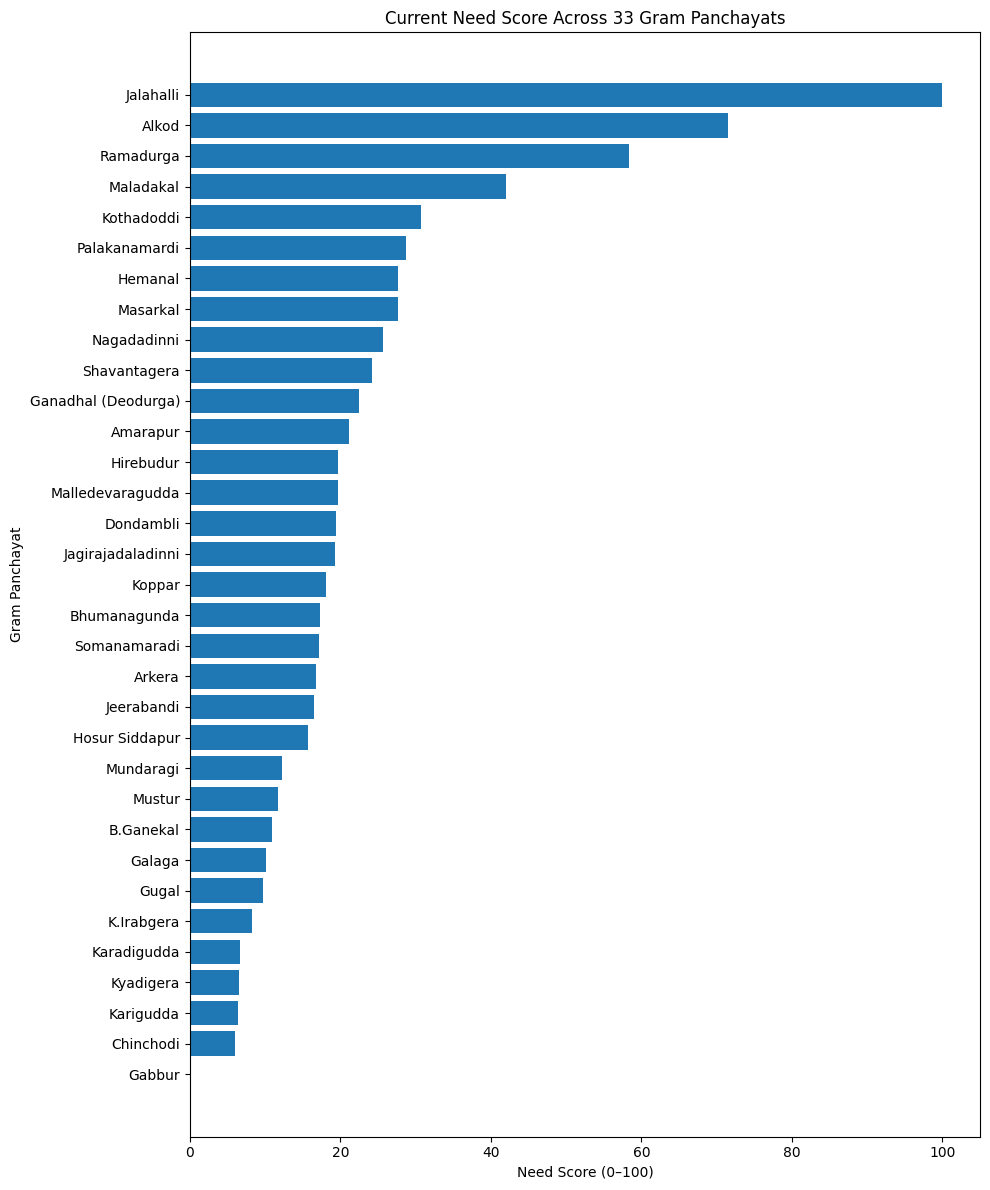

In [165]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv(need_assessment_file)

results = results.sort_values(
    "need_score_100",
    ascending=True
)

plt.figure(figsize=(10, 12))

plt.barh(
    results["gp_name"],
    results["need_score_100"]
)

plt.xlabel("Need Score (0–100)")
plt.ylabel("Gram Panchayat")
plt.title("Current Need Score Across 33 Gram Panchayats")

plt.tight_layout()
plt.show()

In [166]:
chart_file = os.path.join(
    CLEAN_DIR,
    "need_score_by_gp.png"
)

plt.savefig(
    chart_file,
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved:", chart_file)

plt.show()

Chart saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/need_score_by_gp.png


<Figure size 640x480 with 0 Axes>